# 🚕 Indian Ride-Hailing Analytics

## Python-Based Data Analysis & Machine Learning Project

### Analyzing City-Wise and Country-Wide Ride Operations, Fare Prediction, and High-Demand Zone Detection.

## 📌 About the Project

This project focuses on analyzing synthetic ride-hailing and taxi operations across six major Indian metropolitan cities: Bengaluru, Mumbai, Delhi, Hyderabad, Chennai, and Pune. The dataset simulates real-world ride dynamics, including trip distances, vehicle types, traffic congestion, demand-supply ratios, and dynamic surge pricing.

Using Python, this project aims to explore city-wise and country-wide ride-hailing patterns, identify key operational trends, and develop predictive models for fare estimation and high-demand zone detection.

The analysis will cover data loading, data cleaning, exploratory data analysis (EDA), and machine learning. The project will provide insights into ride demand, pricing variations, and operational performance across cities, while predicting the final fare for individual cities and the overall country, as well as identifying high-demand zones.

The goal is to demonstrate practical Python skills in data analysis, visualization, and machine learning while solving real-world business problems in the urban transportation industry.

## 🎯 Main Business Goal

The main business goal of this project is to analyze urban ride-hailing operations across major Indian metropolitan cities using Python to identify key trends in ride demand, pricing, and operational performance.

The project aims to:

Analyze City-Wise and Country-Wide Ride Performance
Understand ride patterns, fare variations, and demand across different cities and the overall country.
Predict Final Fare
Develop a machine learning model to predict the final fare of rides for each city and the country as a whole.
Identify High-Demand Zones
Use data analysis and machine learning to identify areas with high ride demand, helping improve driver availability and operational efficiency.
Support Data-Driven Decision Making
Provide actionable insights to help ride-hailing businesses optimize pricing, manage supply and demand, and improve overall operational performance.

Overall Goal: To leverage Python-based data analysis and machine learning to improve fare prediction, identify high-demand zones, and support efficient ride-hailing operations across India.

In [1]:

import pandas as pd
import numpy as np


import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor


from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score


from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

pd.set_option('display.max_columns', None)

print("All required libraries imported successfully!")

All required libraries imported successfully!


In [3]:
df = pd.read_csv(r"C:\Users\papus\OneDrive\Documents\Cab Fare Project\UrbanCabFare.csv")
df.shape

(1000, 16)

In [4]:
df.head()

,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare
0,USER-21819-Bcbf,Patrick Sanchez,Pune,05-11-2025,0,Friday,26.21,Low,Hatchback,36,67,1.86,60,354.52,1.3,460.88
1,USER-79402-SBvr,Meredith Barnes,Mumbai,13-10-2025,2,Friday,21.08,High,Auto,9,17,1.89,50,282.96,1.3,367.85
2,USER-40781-yfJs,Ian Cooper,Bengaluru,16-06-2026,6,Sunday,25.34,High,Hatchback,94,149,1.59,75,344.08,1.3,447.30
3,USER-41316-rDOx,Amber Perez,Mumbai,15-10-2025,0,Monday,26.80,High,Auto,25,188,7.52,76,351.60,1.6,562.56
4,USER-76483-RuXX,Kimberly Sanchez,Chennai,06-09-2025,10,Friday,4.48,High,SUV,53,34,0.64,18,133.76,1.0,133.76


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   User_ID               1000 non-null   object 
 1   Driver_Name           985 non-null    object 
 2   City                  1000 non-null   object 
 3   Ride_Date             1000 non-null   object 
 4   Hour_of_Day           1000 non-null   int64  
 5   Day_of_Week           1000 non-null   object 
 6   Distance_km           1000 non-null   float64
 7   Traffic_Level         1000 non-null   object 
 8   Type_of_vehicle       1000 non-null   object 
 9   No_of_active_drivers  1000 non-null   int64  
 10  Ride_Requests         1000 non-null   int64  
 11  Demand_Supply_Ratio   1000 non-null   float64
 12  Trip_Duration         1000 non-null   int64  
 13  Base_Fare             1000 non-null   float64
 14  Surge_Multiplier      1000 non-null   float64
 15  Final_Fare            

In [7]:
df['Ride_Date'] = pd.to_datetime(
    df['Ride_Date'],
    format='%d-%m-%Y'
)

In [10]:
df.dtypes

User_ID                         object
Driver_Name                     object
City                            object
Ride_Date               datetime64[ns]
Hour_of_Day                      int64
Day_of_Week                     object
Distance_km                    float64
Traffic_Level                   object
Type_of_vehicle                 object
No_of_active_drivers             int64
Ride_Requests                    int64
Demand_Supply_Ratio            float64
Trip_Duration                    int64
Base_Fare                      float64
Surge_Multiplier               float64
Final_Fare                     float64
dtype: object

In [11]:
df.isnull().sum()

User_ID                  0
Driver_Name             15
City                     0
Ride_Date                0
Hour_of_Day              0
Day_of_Week              0
Distance_km              0
Traffic_Level            0
Type_of_vehicle          0
No_of_active_drivers     0
Ride_Requests            0
Demand_Supply_Ratio      0
Trip_Duration            0
Base_Fare                0
Surge_Multiplier         0
Final_Fare               0
dtype: int64

In [12]:
df['Driver_Name'] = df['Driver_Name'].fillna('Unknown Driver')

In [13]:
df['Driver_Name'].isnull().sum()

np.int64(0)

In [16]:
df['Driver_Name'].value_counts().head()

Driver_Name
Unknown Driver    15
Eric Meyer         2
Michael Lewis      2
David Grant        2
Brenda Smith       2
Name: count, dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDate Range:")
print("Start Date:", df['Ride_Date'].min())
print("End Date:", df['Ride_Date'].max())

Dataset Shape: (1000, 16)

Missing Values:
User_ID                 0
Driver_Name             0
City                    0
Ride_Date               0
Hour_of_Day             0
Day_of_Week             0
Distance_km             0
Traffic_Level           0
Type_of_vehicle         0
No_of_active_drivers    0
Ride_Requests           0
Demand_Supply_Ratio     0
Trip_Duration           0
Base_Fare               0
Surge_Multiplier        0
Final_Fare              0
dtype: int64

Duplicate Rows:
0

Date Range:
Start Date: 2025-08-17 00:00:00
End Date: 2026-08-17 00:00:00


In [17]:
df.describe()

,Ride_Date,Hour_of_Day,Distance_km,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare
count,1000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2026-02-20 00:37:26.400000256,11.651000,17.911070,52.52000,108.047000,3.569190,55.165000,257.477840,1.436200,370.238310
min,2025-08-17 00:00:00,0.000000,1.010000,5.00000,10.000000,0.100000,6.000000,27.120000,1.000000,32.540000
25%,2025-11-23 00:00:00,5.750000,9.567500,28.00000,60.000000,1.157500,32.000000,159.650000,1.000000,208.205000
50%,2026-02-24 12:00:00,12.000000,18.180000,54.00000,110.500000,2.040000,54.000000,256.740000,1.500000,338.580000
75%,2026-05-18 00:00:00,18.000000,25.897500,76.00000,156.000000,4.022500,76.250000,352.230000,1.700000,493.767500
max,2026-08-17 00:00:00,23.000000,34.990000,100.00000,200.000000,39.400000,122.000000,498.200000,2.000000,939.760000
std,NaN,7.020576,9.634464,27.47334,55.394199,4.734492,27.946857,117.993113,0.343435,199.232597


In [18]:
print("Cities:")
print(df['City'].unique())

print("\nTraffic Levels:")
print(df['Traffic_Level'].unique())

print("\nVehicle Types:")
print(df['Type_of_vehicle'].unique())

print("\nDays of Week:")
print(df['Day_of_Week'].unique())

Cities:
['Pune' 'Mumbai' 'Bengaluru' 'Chennai' 'Delhi' 'Hyderabad']

Traffic Levels:
['Low' 'High' 'Jam' 'Medium']

Vehicle Types:
['Hatchback' 'Auto' 'SUV' 'Bike' 'Sedan']

Days of Week:
['Friday' 'Sunday' 'Monday' 'Tuesday' 'Saturday' 'Wednesday' 'Thursday']


In [19]:
print("Distance <= 0:", (df['Distance_km'] <= 0).sum())

print("Final Fare <= 0:", (df['Final_Fare'] <= 0).sum())

print("Base Fare <= 0:", (df['Base_Fare'] <= 0).sum())

print("Active Drivers <= 0:", (df['No_of_active_drivers'] <= 0).sum())

print("Ride Requests <= 0:", (df['Ride_Requests'] <= 0).sum())

print("Invalid Hour:", ((df['Hour_of_Day'] < 0) | 
                       (df['Hour_of_Day'] > 23)).sum())

Distance <= 0: 0
Final Fare <= 0: 0
Base Fare <= 0: 0
Active Drivers <= 0: 0
Ride Requests <= 0: 0
Invalid Hour: 0


In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outlier_report = []

for col in numeric_cols:
    
    data = df[col].dropna()
    
    median = data.median()
    df[col] = df[col].fillna(median)
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers_before = ((df[col] < lower) | (df[col] > upper)).sum()
    
    df[col] = df[col].clip(lower, upper)
    
    outliers_after = ((df[col] < lower) | (df[col] > upper)).sum()

    outlier_report.append([
        col,
        outliers_before,
        outliers_after,
        round((outliers_before / len(df)) * 100, 2)
    ])

outlier_df = pd.DataFrame(
    outlier_report,
    columns=['Feature', 'Outliers_Before', 'Outliers_After', 'Percentage_Before']
)

outlier_df = outlier_df.sort_values('Outliers_Before', ascending=False)

print("=" * 80)
print("Outlier Treatment Report:")
print(outlier_df)

print("\nTotal numeric features:", len(numeric_cols))
print("Features with >10 outliers before treatment:",
      (outlier_df['Outliers_Before'] > 10).sum())
print("=" * 80)

Outlier Treatment Report:
                Feature  Outliers_Before  Outliers_After  Percentage_Before
4   Demand_Supply_Ratio               90               0                9.0
8            Final_Fare                2               0                0.2
0           Hour_of_Day                0               0                0.0
2  No_of_active_drivers                0               0                0.0
1           Distance_km                0               0                0.0
3         Ride_Requests                0               0                0.0
5         Trip_Duration                0               0                0.0
6             Base_Fare                0               0                0.0
7      Surge_Multiplier                0               0                0.0

Total numeric features: 9
Features with >10 outliers before treatment: 1


In [22]:
num_col = df.select_dtypes(include='number').columns.to_list()
cat_col = df.select_dtypes(include='object').columns.to_list()

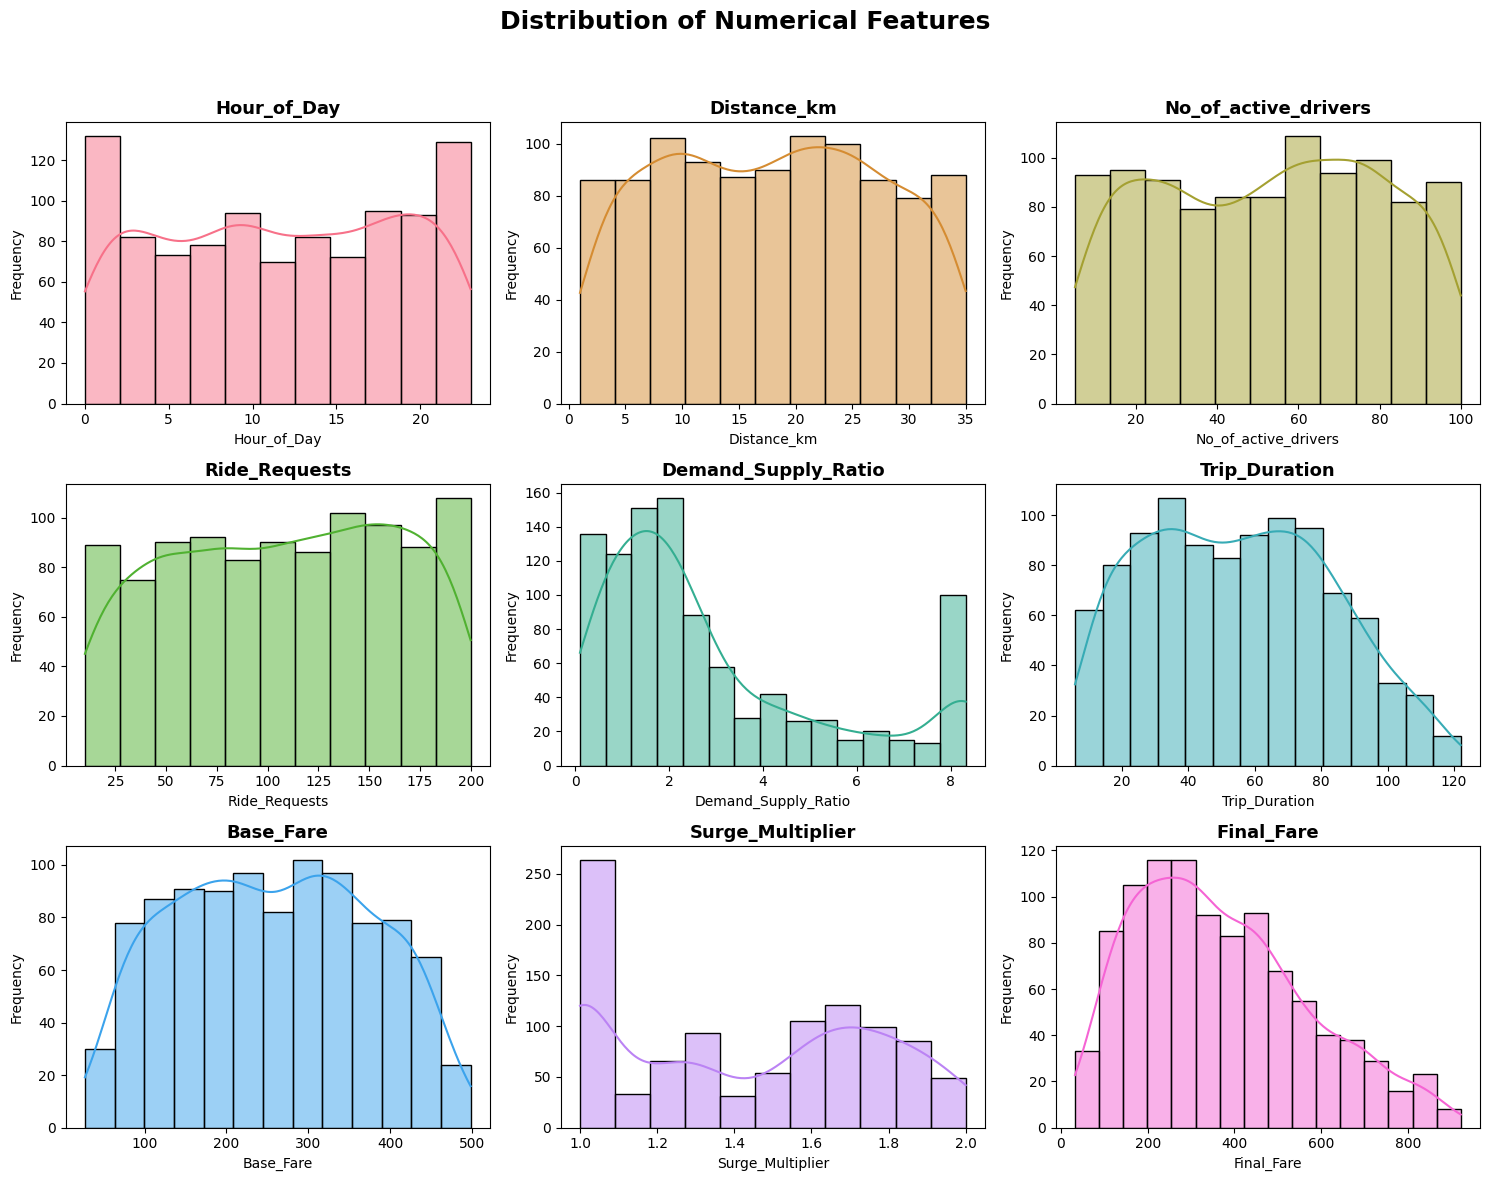

In [23]:
n_cols = 3
n_rows = int(np.ceil(len(num_col) / n_cols))
palette = sns.color_palette("husl", len(num_col))  # 🎨 Unique colors

plt.figure(figsize=(n_cols*5, n_rows*4))

for i, (col, color) in enumerate(zip(num_col, palette), 1):

    plt.subplot(n_rows, n_cols, i)

    sns.histplot(
        df[col],
        kde=True,
        color=color,   
        edgecolor="black"
    )

    plt.title(col, fontsize=13, fontweight="bold")
    plt.xlabel(col)
    plt.ylabel("Frequency")


plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


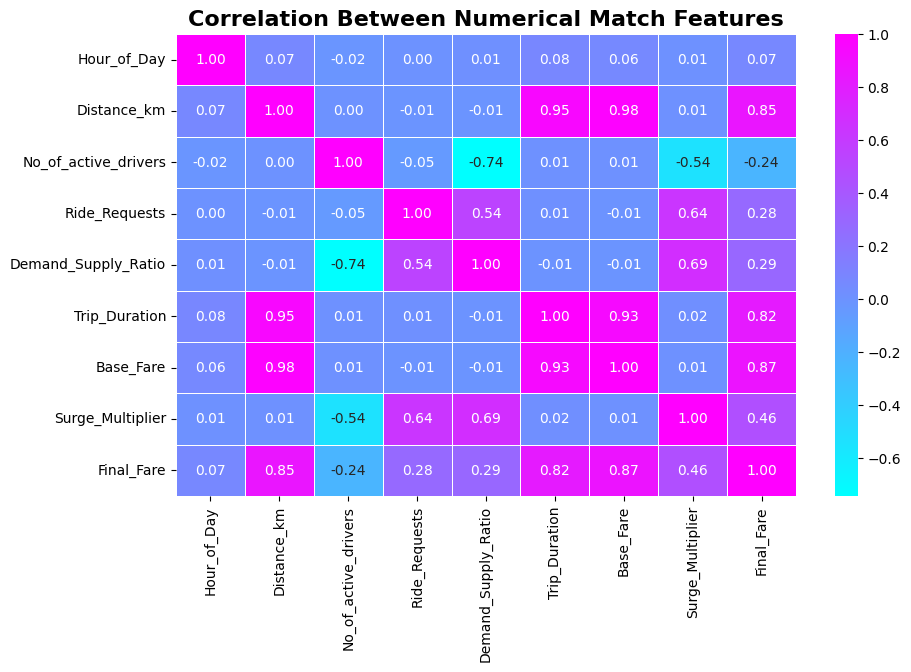

In [24]:
# Correlation Heatmap
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=['int64','float64']).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="cool",
    linewidths=0.5,
    fmt=".2f"
)

plt.title(
    "Correlation Between Numerical Match Features",
    fontsize=16,
    fontweight='bold'
)

plt.show()

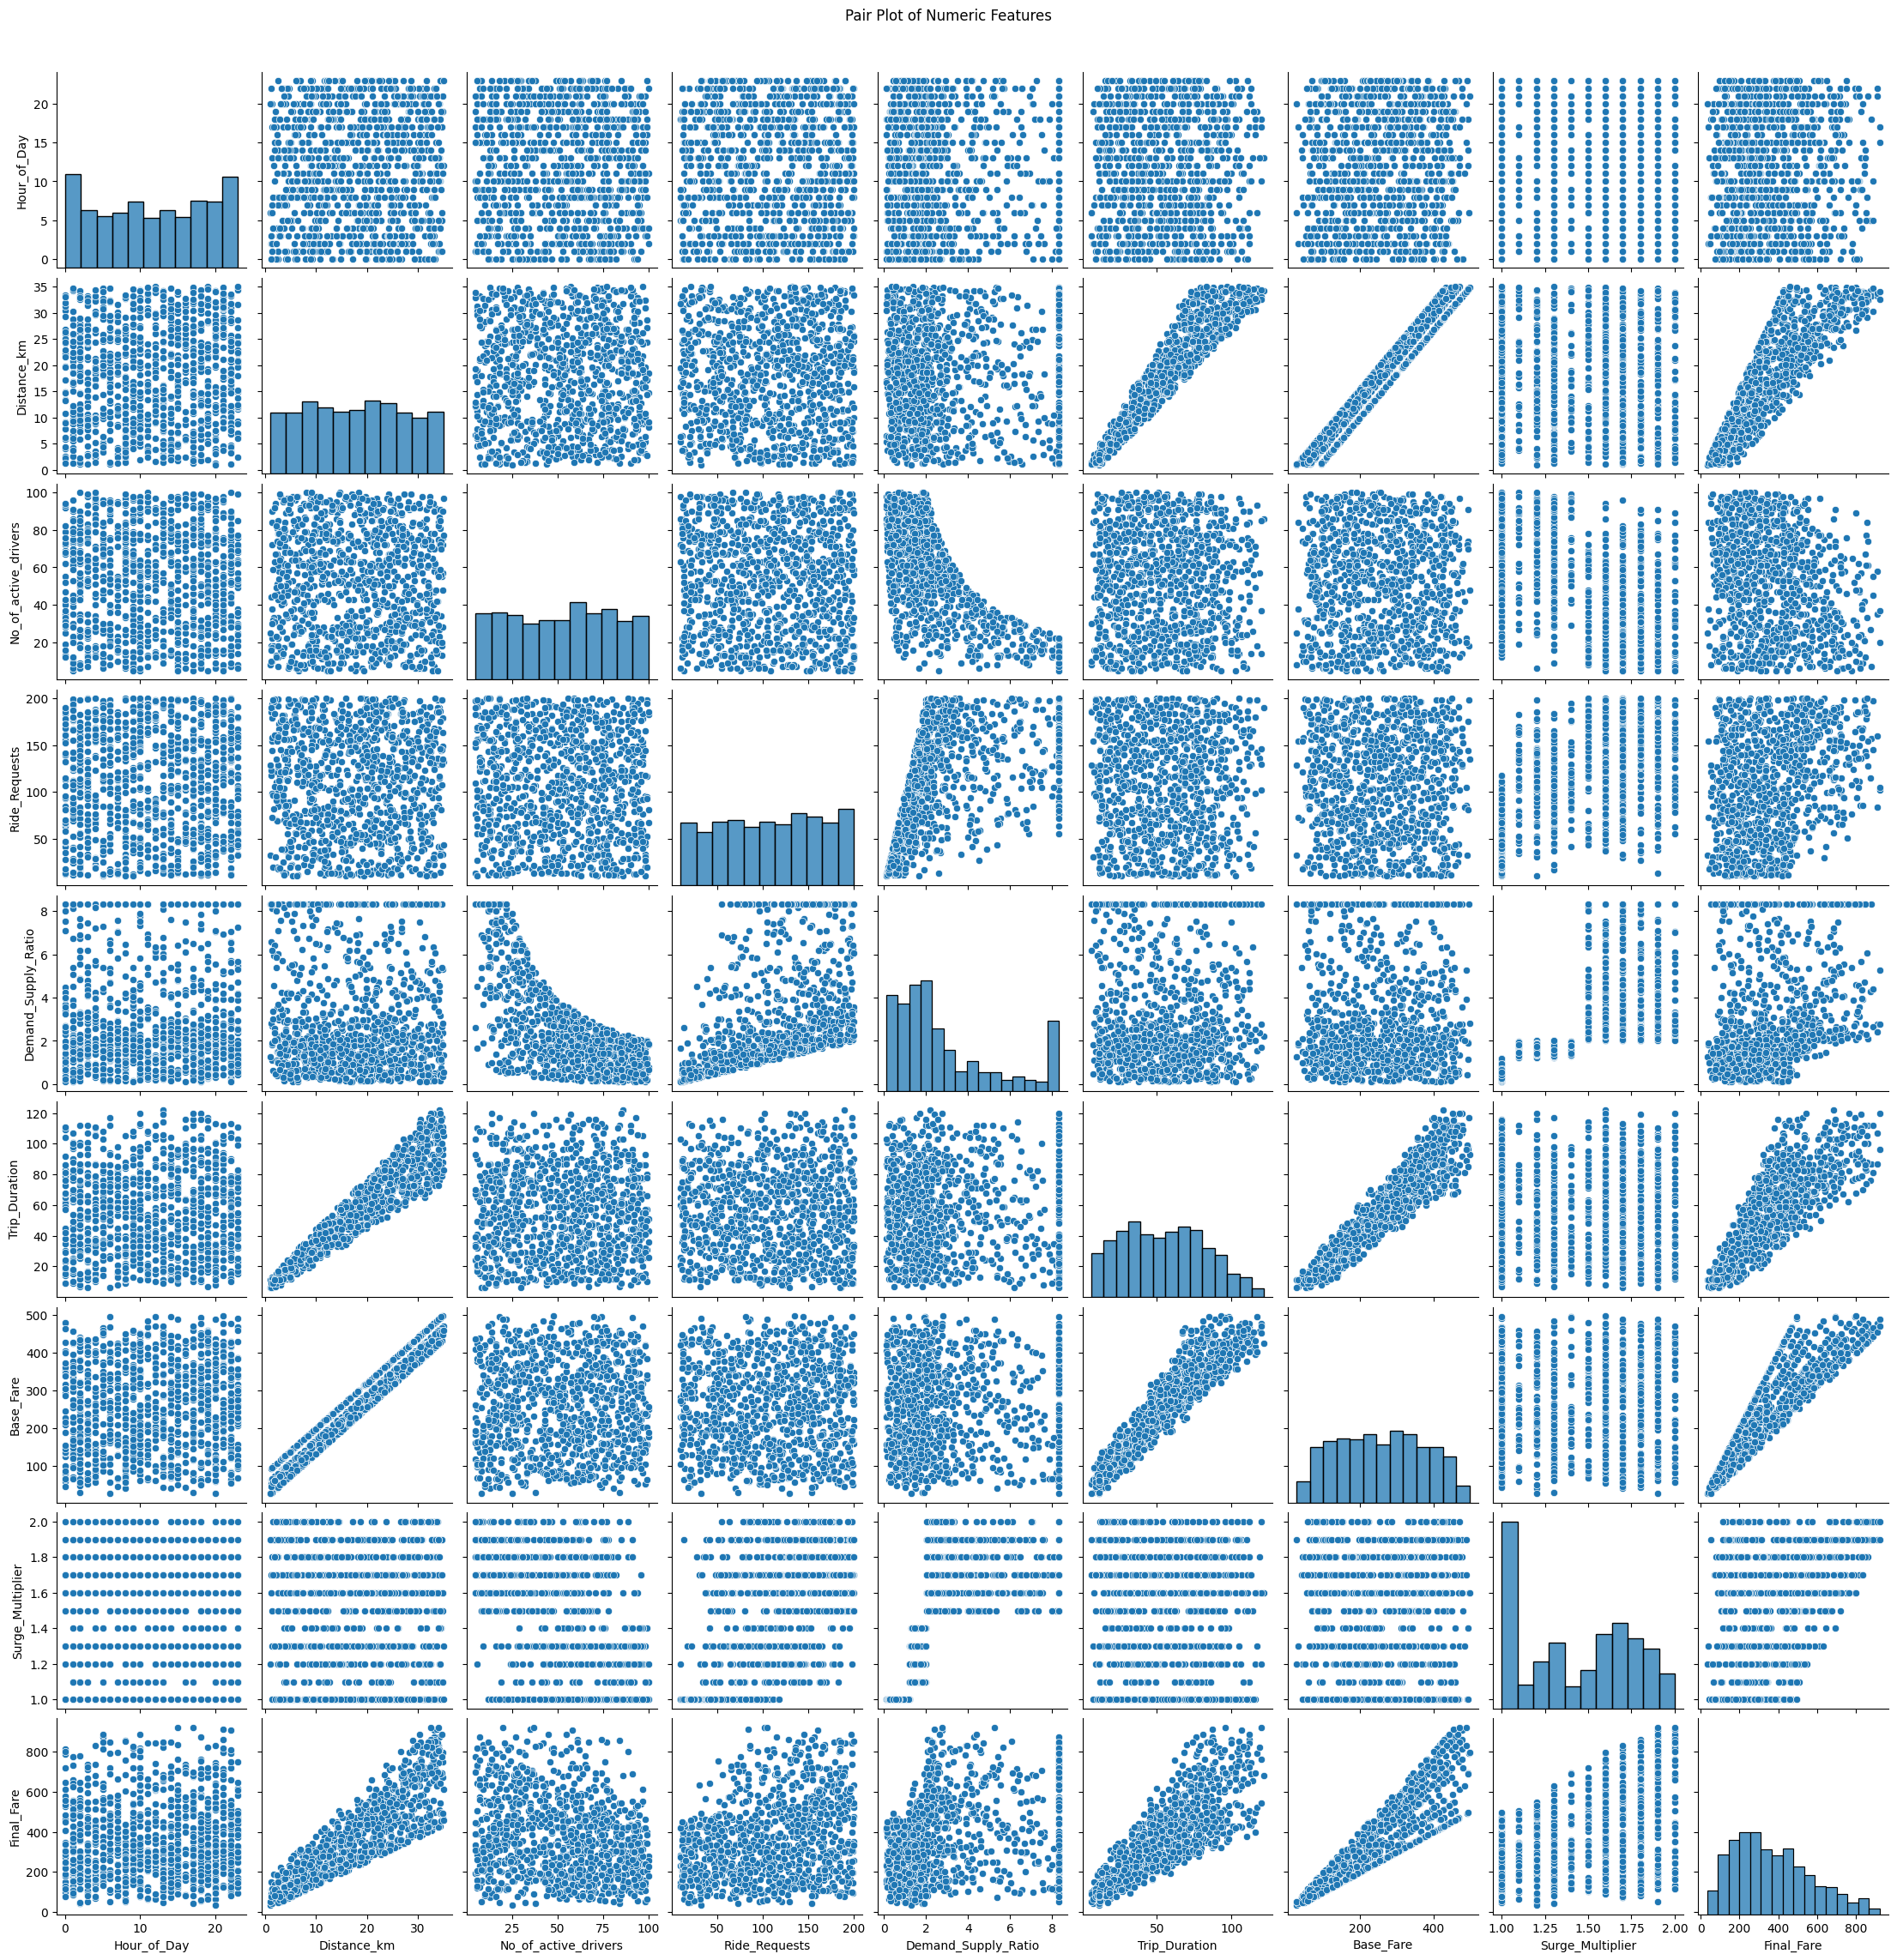

In [25]:
sns.pairplot(df)
plt.suptitle('Pair Plot of Numeric Features', y=1.02)
plt.show()

In [26]:
city_stats = df.groupby('City').agg(
    Total_Rides=('User_ID', 'count'),
    Average_Distance=('Distance_km', 'mean'),
    Average_Trip_Duration=('Trip_Duration', 'mean'),
    Total_Ride_Requests=('Ride_Requests', 'sum'),
    Average_Surge=('Surge_Multiplier', 'mean'),
    Average_Final_Fare=('Final_Fare', 'mean')
).reset_index()

city_stats

,City,Total_Rides,Average_Distance,Average_Trip_Duration,Total_Ride_Requests,Average_Surge,Average_Final_Fare
0,Bengaluru,157,18.742102,56.885350,17564,1.462420,393.863631
1,Chennai,170,17.224059,53.429412,18331,1.416471,352.870294
2,Delhi,167,19.591138,60.766467,18768,1.474850,412.835576
3,Hyderabad,155,17.627742,54.606452,15355,1.385806,348.835548
4,Mumbai,157,17.203439,51.802548,18049,1.463694,362.594403
5,Pune,194,17.193351,53.639175,19980,1.417010,352.824330


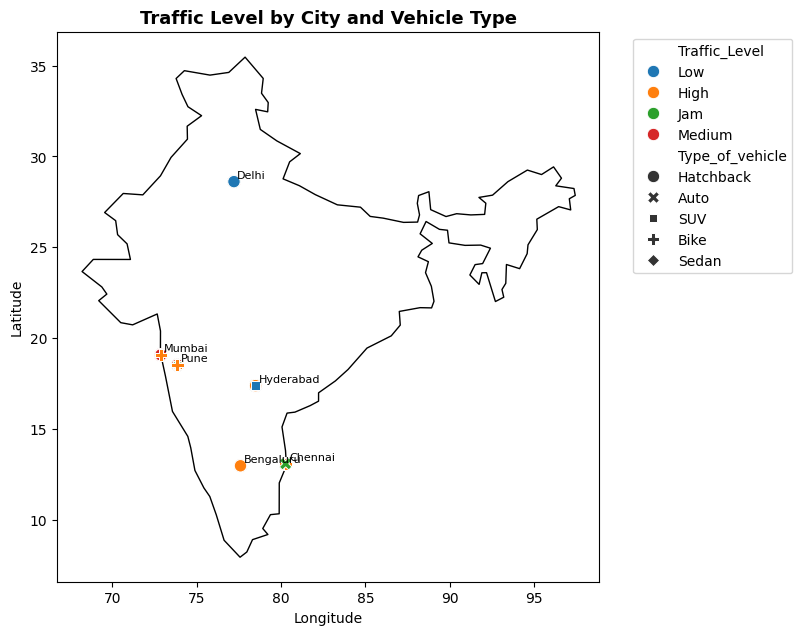

In [29]:
import geopandas as gpd

city_coordinates = {
    'Pune': (18.5204, 73.8567),
    'Mumbai': (19.0760, 72.8777),
    'Bengaluru': (12.9716, 77.5946),
    'Chennai': (13.0827, 80.2707),
    'Delhi': (28.6139, 77.2090),
    'Hyderabad': (17.3850, 78.4867)
}

df['latitude'] = df['City'].map(lambda x: city_coordinates[x][0])
df['longitude'] = df['City'].map(lambda x: city_coordinates[x][1])

world = gpd.read_file(
    "https://naturalearth.s3.amazonaws.com/110m_cultural/ne_110m_admin_0_countries.zip"
)

india = world[world['NAME'] == 'India']

fig, ax = plt.subplots(figsize=(7, 8))

india.plot(
    ax=ax,
    edgecolor='black',
    facecolor='white'
)

sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=80,
    ax=ax
)

for city, (lat, lon) in city_coordinates.items():
    ax.text(
        lon + 0.2,
        lat + 0.2,
        city,
        fontsize=8
    )

ax.set_title(
    'Traffic Level by City and Vehicle Type',
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left'
)

plt.show()

## Delhi Statistics

In [30]:
delhi = df[df['City'] == 'Delhi'].copy()

print("Delhi Records:", len(delhi))
delhi.head()

Delhi Records: 167


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare,latitude,longitude
5,USER-53767-jqip,Thomas Bradley,Delhi,2026-05-16,1,Sunday,25.81,Jam,Hatchback,73,41,0.56,97,349.72,1.0,349.72,28.6139,77.209
18,USER-99118-nGqi,Taylor Smith,Delhi,2026-07-24,5,Monday,19.34,Medium,Sedan,72,10,0.14,65,282.08,1.0,282.08,28.6139,77.209
19,USER-27849-ZPHa,Unknown Driver,Delhi,2026-04-18,11,Monday,30.88,Low,Bike,44,71,1.61,67,385.56,1.1,424.12,28.6139,77.209
20,USER-44935-nROq,Brian Tran,Delhi,2026-02-18,2,Wednesday,34.25,Low,Auto,73,42,0.58,84,441.00,1.0,441.00,28.6139,77.209
25,USER-85014-lLqc,Jordan Frazier,Delhi,2025-09-26,17,Wednesday,5.50,High,SUV,78,157,2.01,23,146.00,1.9,277.40,28.6139,77.209


In [31]:
delhi_summary = {
    'Total Records': len(delhi),
    'Total Ride Requests': delhi['Ride_Requests'].sum(),
    'Average Distance(Km)': delhi['Distance_km'].mean(),
    'Average Trip Duration(min)': delhi['Trip_Duration'].mean(),
    'Average Active Drivers': delhi['No_of_active_drivers'].mean(),
    'Average Demand/Supply Ratio': delhi['Demand_Supply_Ratio'].mean(),
    'Average Surge Multiplier': delhi['Surge_Multiplier'].mean(),
    'Average Base Fare': delhi['Base_Fare'].mean(),
    'Average Final Fare': delhi['Final_Fare'].mean() 
    
}

for key, value in delhi_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Records: 167
Total Ride Requests: 18768
Average Distance(Km): 19.59
Average Trip Duration(min): 60.77
Average Active Drivers: 53.99
Average Demand/Supply Ratio: 2.79
Average Surge Multiplier: 1.47
Average Base Fare: 278.21
Average Final Fare: 412.84


In [32]:
# Delhi revenue
delhi['Revenue'] = delhi['Final_Fare']
total_revenue = delhi['Revenue'].sum()
print('Delhi Total Revenue: ₹', round(total_revenue, 2))

Delhi Total Revenue: ₹ 68943.54


In [33]:
# Delhi by vehicle type
delhi_vehicle = (
    delhi.groupby('Type_of_vehicle')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Distance=('Distance_km', 'mean'),
        Avg_Trip_Duration=('Trip_Duration', 'mean'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Final_Fare=('Final_Fare', 'mean')
    )
     .sort_values('Ride_Requests', ascending=False)
)

delhi_vehicle

,Ride_Requests,Avg_Distance,Avg_Trip_Duration,Avg_Surge,Avg_Final_Fare
Type_of_vehicle,,,,,
SUV,4092,21.227027,65.324324,1.475676,507.381385
Bike,4084,17.885278,54.083333,1.516667,349.827778
Auto,3975,18.060571,55.400000,1.525714,368.967714
Hatchback,3345,19.104667,60.966667,1.400000,382.781333
Sedan,3272,21.972069,69.517241,1.437931,454.459310


In [34]:
# Delhi by hour
delhi_hourly = (
    delhi.groupby('Hour_of_Day')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Active_Drivers=('No_of_active_drivers', 'mean'),
        Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Surge=('Surge_Multiplier', 'mean'),
        Final_Fare=('Final_Fare', 'mean')
    )
    .reset_index()
)

delhi_hourly

,Hour_of_Day,Ride_Requests,Active_Drivers,Demand_Supply,Surge,Final_Fare
0,0,624,72.250000,2.205000,1.375000,402.027500
1,1,1100,70.181818,1.757273,1.418182,367.763636
2,2,1233,50.900000,2.958000,1.580000,419.382000
3,3,803,62.571429,2.457143,1.371429,264.157143
4,4,305,56.250000,2.117500,1.250000,350.687500
5,5,436,46.000000,2.864000,1.600000,374.382000
6,6,915,53.125000,3.186250,1.412500,441.513750
7,7,699,37.833333,4.663333,1.800000,522.893333
8,8,457,73.500000,1.083333,1.233333,341.175000
9,9,1196,51.888889,3.294444,1.555556,399.435556


In [35]:
# Peak demand hour
delhi_hourly.loc[
    delhi_hourly['Ride_Requests'].idxmax()
]

Hour_of_Day         17.000000
Ride_Requests     1301.000000
Active_Drivers      57.777778
Demand_Supply        2.640000
Surge                1.577778
Final_Fare         529.843472
Name: 17, dtype: float64

In [36]:
# Highest surge hour
delhi_hourly.loc[
    delhi_hourly['Surge'].idxmax()
]

Hour_of_Day         7.000000
Ride_Requests     699.000000
Active_Drivers     37.833333
Demand_Supply       4.663333
Surge               1.800000
Final_Fare        522.893333
Name: 7, dtype: float64

In [37]:
# Highest demand/supply hour
delhi_hourly.loc[
    delhi_hourly['Demand_Supply'].idxmax()
]

Hour_of_Day         7.000000
Ride_Requests     699.000000
Active_Drivers     37.833333
Demand_Supply       4.663333
Surge               1.800000
Final_Fare        522.893333
Name: 7, dtype: float64

In [38]:
# Delhi traffic analysis
delhi_traffic = (
    delhi.groupby('Traffic_Level')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Avg_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

delhi_traffic

,Ride_Requests,Avg_Surge,Avg_Demand_Supply,Avg_Fare
Traffic_Level,,,,
Jam,5221,1.518605,2.987674,436.490000
Low,4677,1.488372,2.773023,444.008605
Medium,4557,1.402326,2.697907,376.197907
High,4313,1.492105,2.676053,392.252401


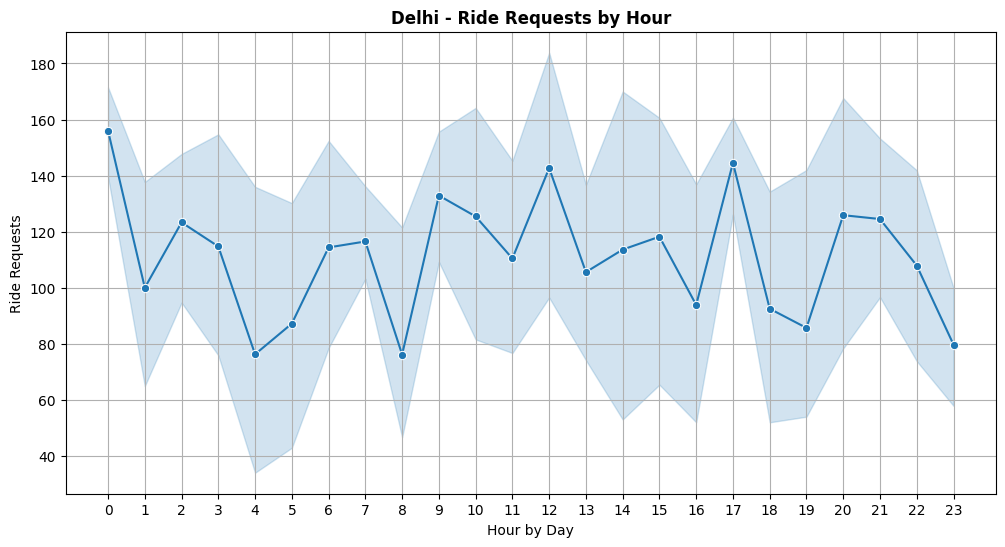

In [39]:
# Delhi Ride Requests by Hour

delhi = df[df['City'] == 'Delhi']

plt.figure(figsize=(12,6))

sns.lineplot(
    data=delhi,
    x="Hour_of_Day",
    y="Ride_Requests",
    marker="o"
)

plt.title('Delhi - Ride Requests by Hour', fontweight='bold')
plt.xlabel('Hour by Day')
plt.ylabel('Ride Requests')
plt.xticks(range(24))
plt.grid(True)
plt.show()

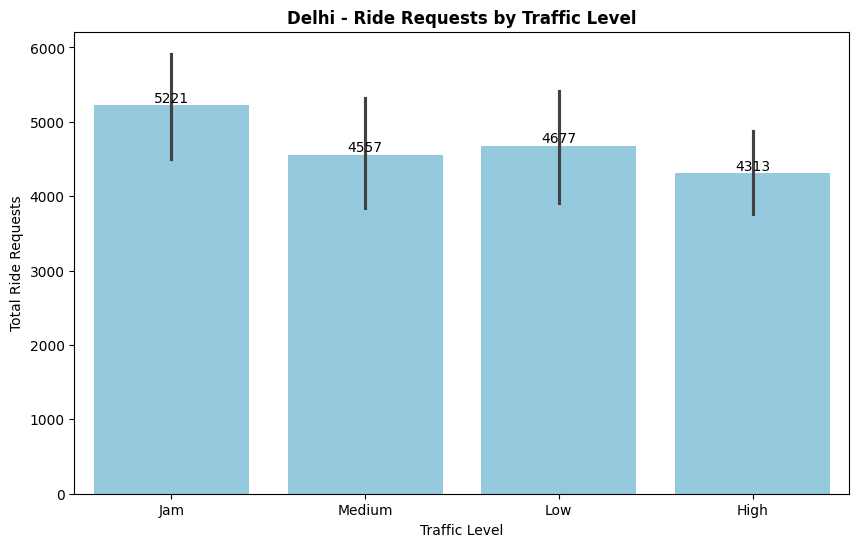

In [41]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=delhi,
    x='Traffic_Level',
    y='Ride_Requests',
    estimator='sum',
    color='skyblue'
)

plt.title('Delhi - Ride Requests by Traffic Level', fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Total Ride Requests')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.show()

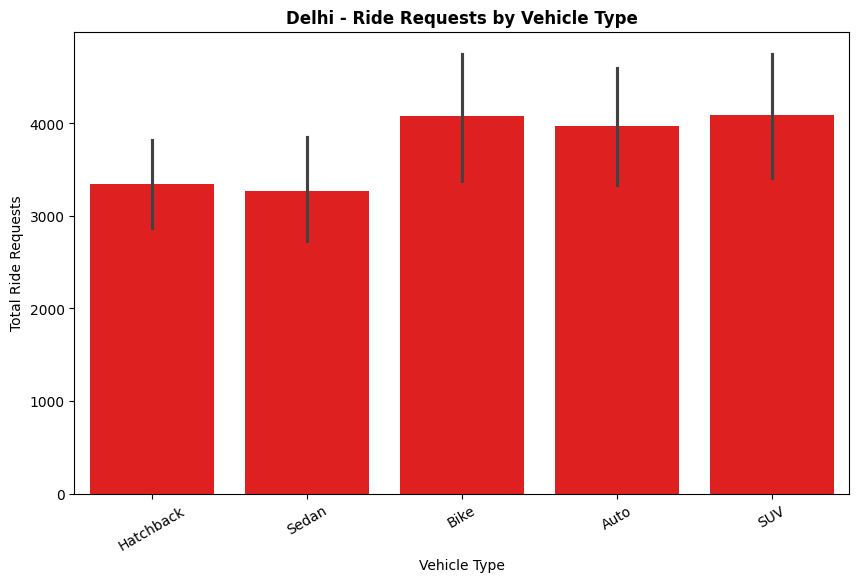

In [42]:
# Delhi — Vehicle Type vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=delhi,
    x='Type_of_vehicle',
    y='Ride_Requests',
    estimator='sum',
    color='red'
)

plt.title('Delhi - Ride Requests by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Ride Requests')
plt.xticks(rotation=30)
plt.show()


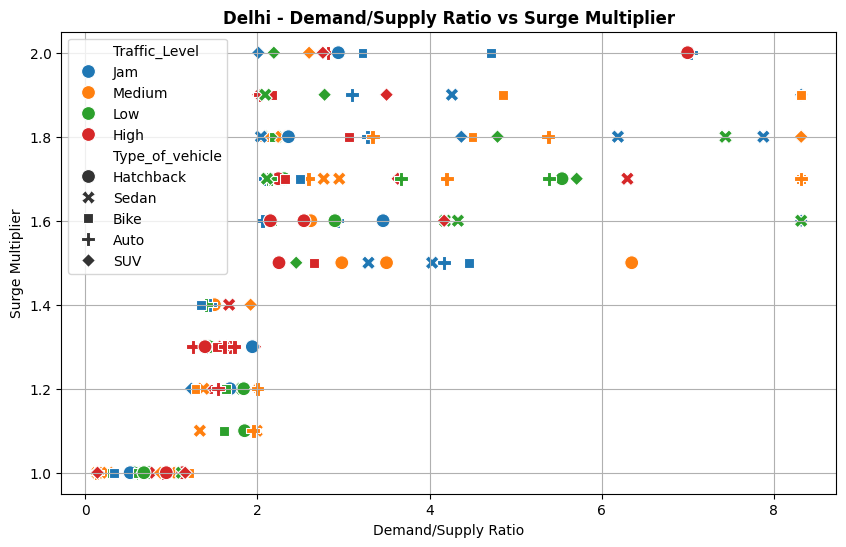

In [43]:
# Delhi — Demand/Supply vs Surge Multiplier

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=delhi,
    x='Demand_Supply_Ratio',
    y='Surge_Multiplier',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=100
)

plt.title('Delhi - Demand/Supply Ratio vs Surge Multiplier', fontweight='bold')
plt.xlabel('Demand/Supply Ratio')
plt.ylabel('Surge Multiplier')
plt.grid(True)
plt.show()

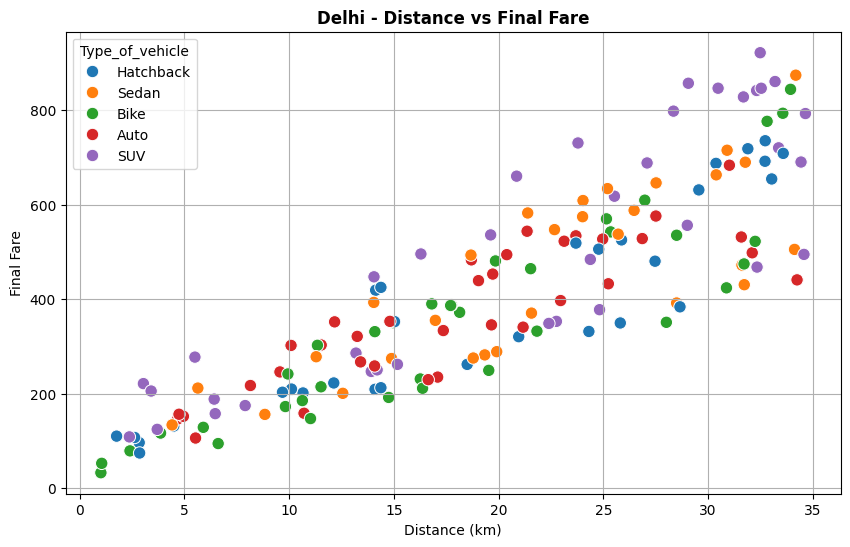

In [44]:
# Delhi — Distance vs Final Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=delhi,
    x='Distance_km',
    y='Final_Fare',
    hue='Type_of_vehicle',
    s=80
)

plt.title('Delhi - Distance vs Final Fare', fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Final Fare')
plt.grid(True)
plt.show()

In [45]:
df[['Final_Fare', 'Ride_Requests']].head()

,Final_Fare,Ride_Requests
0,460.88,67
1,367.85,17
2,447.30,149
3,562.56,188
4,133.76,34


In [46]:
# Delhi data
delhi = df[df['City'] == 'Delhi'].copy()

# COST ASSUMPTIONS
fuel_cost_per_km = 8          # ₹ per km
driver_cost_percentage = 0.60 # 60% of revenue
fixed_cost_per_ride = 10      # ₹ per ride

# REVENUE
delhi['Revenue'] = (
    delhi['Final_Fare'] *
    delhi['Ride_Requests']
)

# COSTS
delhi['Fuel_Cost'] = (
    delhi['Distance_km'] *
    delhi['Ride_Requests'] *
    fuel_cost_per_km
)

delhi['Driver_Cost'] = (
    delhi['Revenue'] *
    driver_cost_percentage
)

delhi['Fixed_Cost'] = (
    delhi['Ride_Requests'] *
    fixed_cost_per_ride
)

delhi['Total_Cost'] = (
    delhi['Fuel_Cost'] +
    delhi['Driver_Cost'] +
    delhi['Fixed_Cost']
)

# PROFIT / LOSS
delhi['Profit_Loss'] = (
    delhi['Revenue'] -
    delhi['Total_Cost']
)


# TOTALS
total_revenue = delhi['Revenue'].sum()
total_cost = delhi['Total_Cost'].sum()
profit_loss = total_revenue - total_cost

print(f"Delhi Revenue    : ₹{total_revenue:,.2f}")
print(f"Delhi Total Cost : ₹{total_cost:,.2f}")

# PROFIT / LOSS RESULT
if profit_loss > 0:
    print(f"Delhi Profit     : ₹{profit_loss:,.2f}")
    print("Result           : PROFIT")

elif profit_loss < 0:
    loss = abs(profit_loss)
    print(f"Delhi Loss       : ₹{loss:,.2f}")
    print("Result           : LOSS")

else:
    print("Delhi Profit/Loss : ₹0.00")
    print("Result            : BREAK-EVEN")

Delhi Revenue    : ₹8,332,314.16
Delhi Total Cost : ₹8,175,244.41
Delhi Profit     : ₹157,069.74
Result           : PROFIT


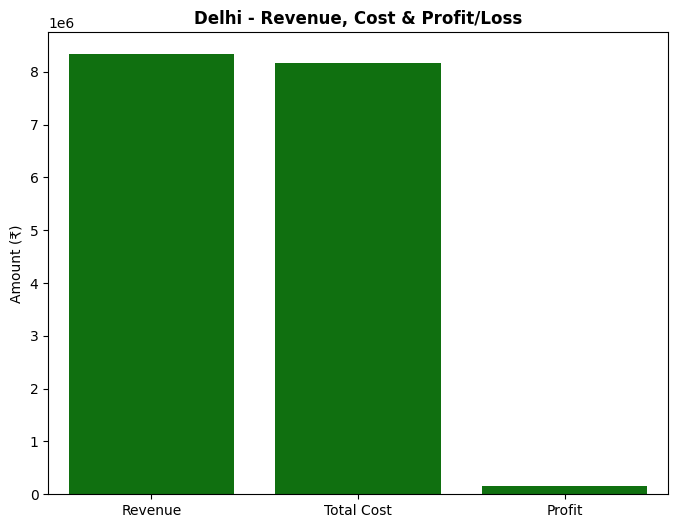

In [47]:
# Revenue vs Cost graph

plt.figure(figsize=(8, 6))

# Determine profit/loss label
if profit_loss > 0:
    result_label = 'Profit'
    result_value = profit_loss

elif profit_loss < 0:
    result_label = 'Loss'
    result_value = abs(profit_loss)

else:
    result_label = 'Break-even'
    result_value = 0

values = pd.DataFrame({
    'Metric': ['Revenue', 'Total Cost', result_label],
    'Amount': [total_revenue, total_cost, result_value]
})

sns.barplot(
    data=values,
    x='Metric',
    y='Amount',
    color='Green'
)

plt.title('Delhi - Revenue, Cost & Profit/Loss', fontweight='bold')
plt.xlabel('')
plt.ylabel('Amount (₹)')

plt.show()

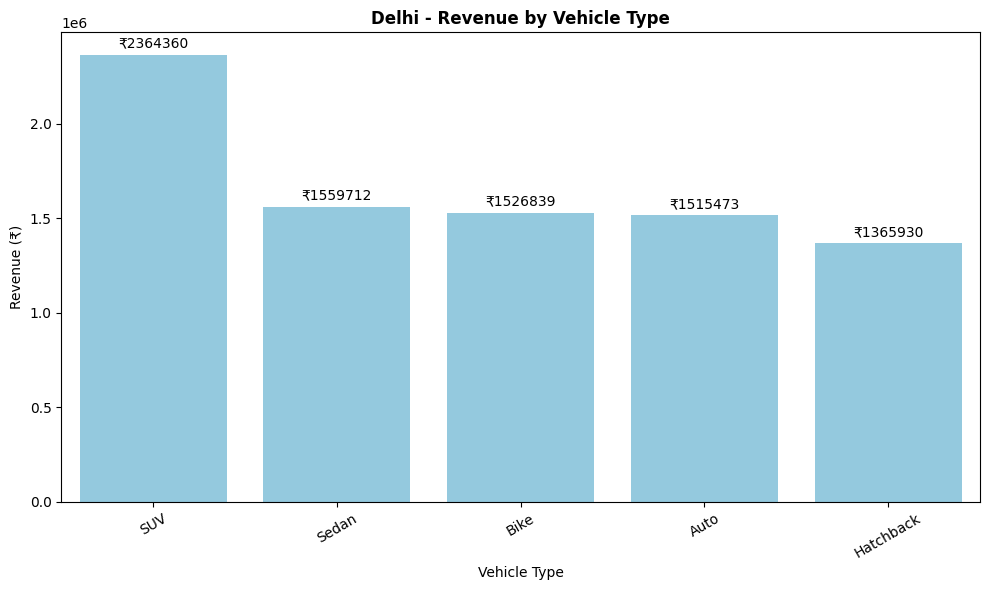

In [49]:
# Revenue by vehicle type

vehicle_revenue = (
    delhi.groupby('Type_of_vehicle')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_revenue,
    x='Type_of_vehicle',
    y='Revenue',
    color='skyblue'
)

plt.title('Delhi - Revenue by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

# Add revenue values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

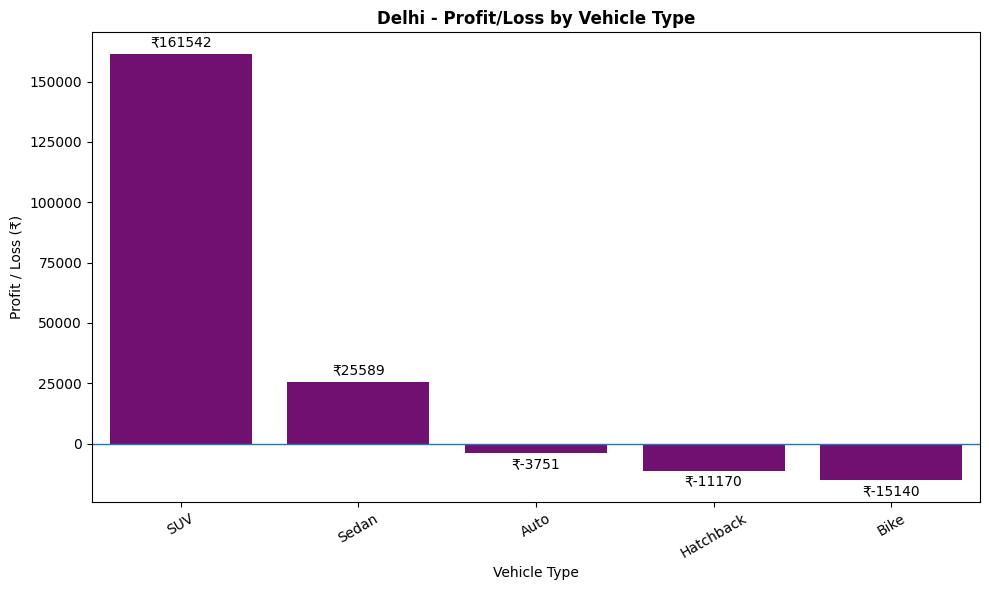

In [50]:
# Profit/Loss by vehicle type

vehicle_profit = (
    delhi.groupby('Type_of_vehicle')['Profit_Loss']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_profit,
    x='Type_of_vehicle',
    y='Profit_Loss',
    color='Purple'
)

plt.axhline(0, linewidth=1)

plt.title('Delhi - Profit/Loss by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Profit / Loss (₹)')
plt.xticks(rotation=30)

# Add values
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

## Pune Statistics 

In [51]:
pune = df[df['City'] == 'Pune'].copy()

In [52]:
print("Pune records:", len(pune))
pune.head()

Pune records: 194


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare,latitude,longitude
0,USER-21819-Bcbf,Patrick Sanchez,Pune,2025-11-05,0,Friday,26.21,Low,Hatchback,36,67,1.86,60,354.52,1.3,460.88,18.5204,73.8567
10,USER-96383-TtzQ,Joshua Baker,Pune,2026-04-11,1,Sunday,8.79,Jam,Auto,9,90,8.32,25,135.48,1.6,216.77,18.5204,73.8567
21,USER-24278-TBJa,Donald Smith,Pune,2025-09-27,5,Saturday,10.01,Medium,Hatchback,82,118,1.44,44,160.12,1.3,208.16,18.5204,73.8567
23,USER-26025-YAZQ,Timothy Hancock,Pune,2026-06-29,2,Sunday,12.49,High,Bike,80,151,1.89,34,164.88,1.1,181.37,18.5204,73.8567
24,USER-33754-Yoob,Shane Garrison,Pune,2026-04-15,1,Saturday,8.78,High,Auto,9,94,8.32,23,135.36,1.6,216.58,18.5204,73.8567


In [53]:
pune_summary = {
    'Total Records': len(pune),
    'Total Ride Requests': pune['Ride_Requests'].sum(),
    'Average Distance (km)': pune['Distance_km'].mean(),
    'Average Trip Duration (min)': pune['Trip_Duration'].mean(),
    'Average Active Drivers': pune['No_of_active_drivers'].mean(),
    'Average Demand/Supply Ratio': pune['Demand_Supply_Ratio'].mean(),
    'Average Surge Multiplier': pune['Surge_Multiplier'].mean(),
    'Average Base Fare': pune['Base_Fare'].mean(),
    'Average Final Fare': pune['Final_Fare'].mean()
}

for key, value in pune_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Records: 194
Total Ride Requests: 19980
Average Distance (km): 17.19
Average Trip Duration (min): 53.64
Average Active Drivers: 51.66
Average Demand/Supply Ratio: 2.88
Average Surge Multiplier: 1.42
Average Base Fare: 247.92
Average Final Fare: 352.82


In [54]:
# Calculate Pune revenue

pune['Revenue'] = pune['Final_Fare']

total_revenue = pune['Revenue'].sum()

print("Pune Total Revenue: ₹", round(total_revenue, 2))

Pune Total Revenue: ₹ 68447.92


In [60]:
# See Pune by vehicle type

pune_vehicle = (
    pune.groupby('Type_of_vehicle')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Distance=('Distance_km', 'mean'),
        Avg_Trip_Duration=('Trip_Duration', 'mean'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Final_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

pune_vehicle

,Ride_Requests,Avg_Distance,Avg_Trip_Duration,Avg_Surge,Avg_Final_Fare
Type_of_vehicle,,,,,
SUV,4759,16.978462,52.000000,1.466667,410.596923
Bike,4616,17.198913,55.065217,1.404348,317.174565
Auto,4149,15.911190,50.619048,1.433333,323.407143
Hatchback,3408,19.141143,56.657143,1.402857,380.303429
Sedan,3048,16.999688,54.250000,1.368750,342.215312


In [61]:
# Pune by hour

pune_hourly = (
    pune.groupby('Hour_of_Day')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Active_Drivers=('No_of_active_drivers', 'mean'),
        Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Surge=('Surge_Multiplier', 'mean'),
        Final_Fare=('Final_Fare', 'mean')
    )
    .reset_index()
)

pune_hourly

,Hour_of_Day,Ride_Requests,Active_Drivers,Demand_Supply,Surge,Final_Fare
0,0,916,49.818182,2.228182,1.363636,302.931818
1,1,654,44.500000,3.936667,1.466667,311.311667
2,2,952,40.666667,3.473333,1.422222,265.307778
3,3,1085,40.888889,3.958889,1.544444,399.975556
4,4,1308,58.272727,2.448182,1.472727,408.312727
5,5,659,59.142857,2.157143,1.285714,390.164286
6,6,616,58.571429,1.592857,1.342857,338.481429
7,7,408,47.250000,1.942500,1.475000,437.672500
8,8,1165,53.181818,2.900000,1.390909,231.041818
9,9,988,50.125000,3.556250,1.700000,451.682500


In [62]:
# Peak demand hour
pune_hourly.loc[
    pune_hourly['Ride_Requests'].idxmax()
]

Hour_of_Day         20.000000
Ride_Requests     1579.000000
Active_Drivers      41.266667
Demand_Supply        4.040000
Surge                1.520000
Final_Fare         453.983333
Name: 20, dtype: float64

In [63]:
# Highest surge hour
pune_hourly.loc[
    pune_hourly['Surge'].idxmax()
]

Hour_of_Day        23.000
Ride_Requests     669.000
Active_Drivers     24.800
Demand_Supply       6.912
Surge               1.800
Final_Fare        360.486
Name: 23, dtype: float64

In [64]:
# Highest demand/supply hour

pune_hourly.loc[
    pune_hourly['Demand_Supply'].idxmax()
]

Hour_of_Day        23.000
Ride_Requests     669.000
Active_Drivers     24.800
Demand_Supply       6.912
Surge               1.800
Final_Fare        360.486
Name: 23, dtype: float64

In [65]:
# Pune traffic analysis

pune_traffic = (
    pune.groupby('Traffic_Level')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Avg_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

pune_traffic

,Ride_Requests,Avg_Surge,Avg_Demand_Supply,Avg_Fare
Traffic_Level,,,,
High,5123,1.412766,3.037660,328.649787
Jam,5089,1.433333,3.137843,340.480196
Low,4919,1.412245,2.507959,364.269184
Medium,4849,1.408511,2.816809,378.461702


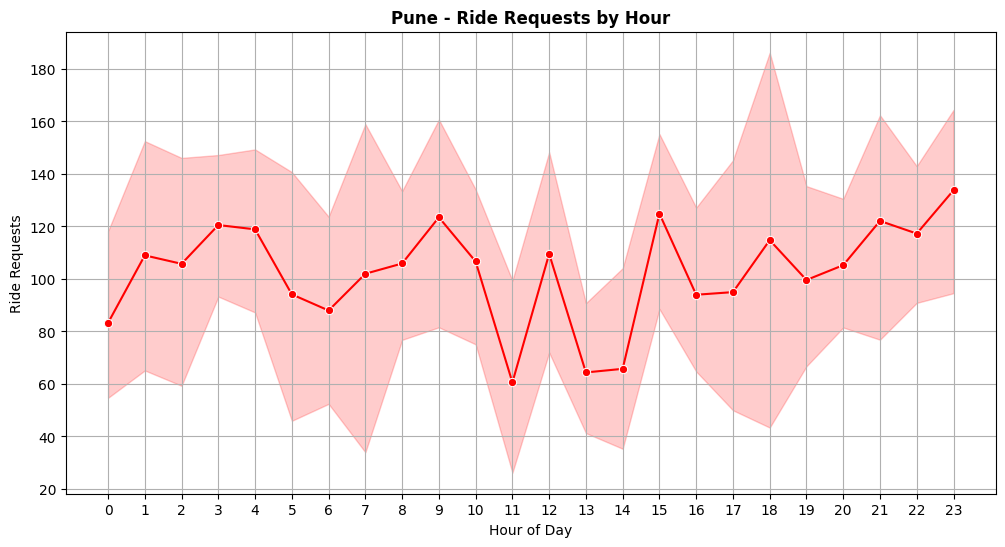

In [66]:
# Pune — Ride Requests by Hour

pune = df[df['City'] == 'Pune']

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=pune,
    x='Hour_of_Day',
    y='Ride_Requests',
    marker='o',
    color='Red'
)

plt.title('Pune - Ride Requests by Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Ride Requests')
plt.xticks(range(24))
plt.grid(True)
plt.show()

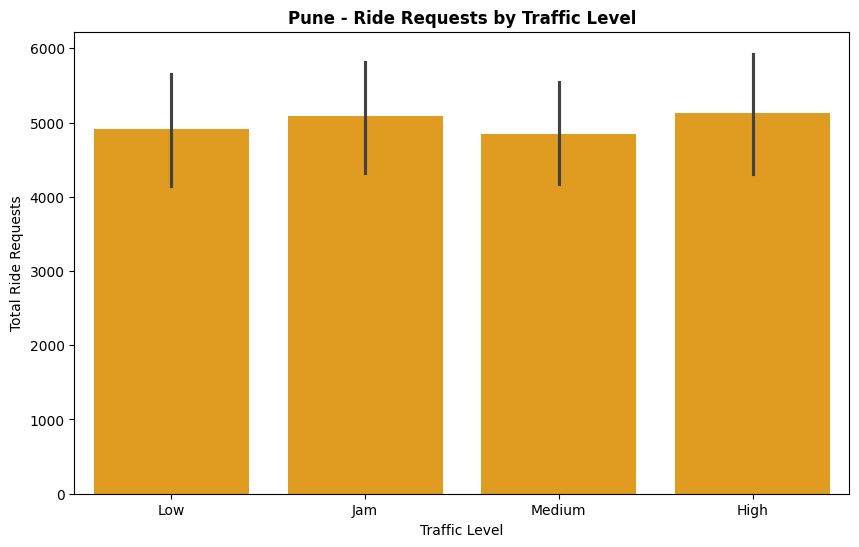

In [67]:
# Pune — Traffic Level vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=pune,
    x='Traffic_Level',
    y='Ride_Requests',
    estimator='sum',
    color='orange'
)

plt.title('Pune - Ride Requests by Traffic Level', fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Total Ride Requests')
plt.show()

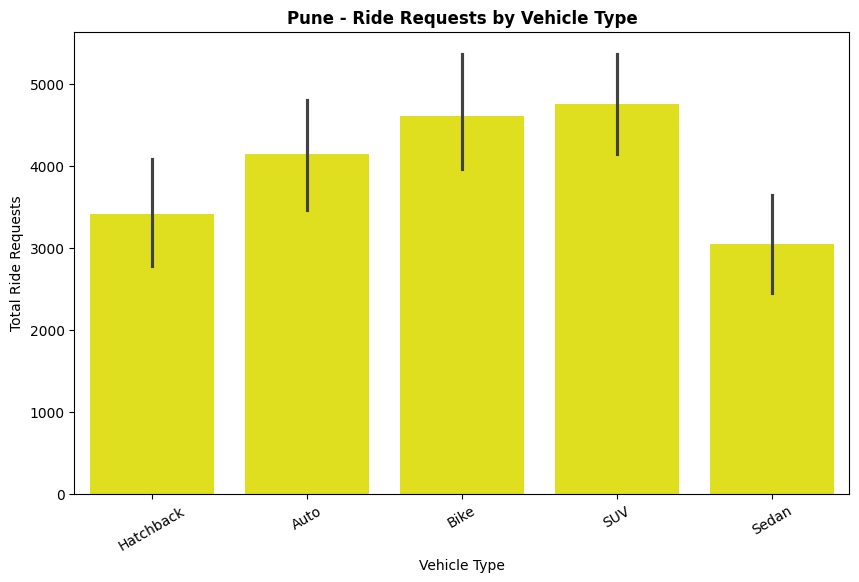

In [68]:
# Pune — Vehicle Type vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=pune,
    x='Type_of_vehicle',
    y='Ride_Requests',
    estimator='sum',
    color='yellow'
)

plt.title('Pune - Ride Requests by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Ride Requests')
plt.xticks(rotation=30)
plt.show()

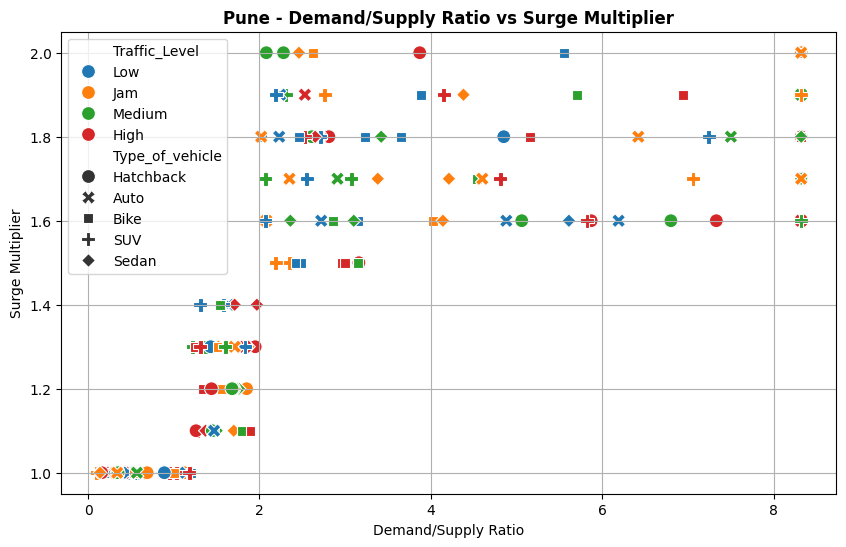

In [69]:
# Pune — Demand/Supply vs Surge Multiplier

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pune,
    x='Demand_Supply_Ratio',
    y='Surge_Multiplier',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=100
)

plt.title('Pune - Demand/Supply Ratio vs Surge Multiplier', fontweight='bold')
plt.xlabel('Demand/Supply Ratio')
plt.ylabel('Surge Multiplier')
plt.grid(True)
plt.show()

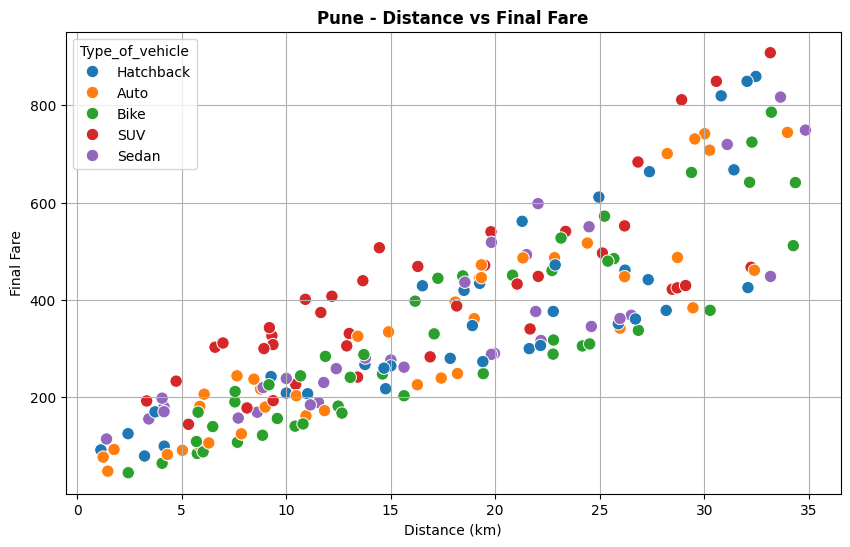

In [70]:
# Pune — Distance vs Final Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=pune,
    x='Distance_km',
    y='Final_Fare',
    hue='Type_of_vehicle',
    s=80
)

plt.title('Pune - Distance vs Final Fare', fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Final Fare')
plt.grid(True)
plt.show()

In [71]:
# Pune data
pune = df[df['City'] == 'Pune'].copy()

# COST ASSUMPTIONS
fuel_cost_per_km = 8          # ₹ per km
driver_cost_percentage = 0.60 # 60% of revenue
fixed_cost_per_ride = 150      # ₹ per ride

# REVENUE
pune['Revenue'] = (
    pune['Final_Fare'] *
    pune['Ride_Requests']
)

# COSTS
pune['Fuel_Cost'] = (
    pune['Distance_km'] *
    pune['Ride_Requests'] *
    fuel_cost_per_km
)

pune['Driver_Cost'] = (
    pune['Revenue'] *
    driver_cost_percentage
)

pune['Fixed_Cost'] = (
    pune['Ride_Requests'] *
    fixed_cost_per_ride
)

pune['Total_Cost'] = (
    pune['Fuel_Cost'] +
    pune['Driver_Cost'] +
    pune['Fixed_Cost']
)

# PROFIT / LOSS
pune['Profit_Loss'] = (
    pune['Revenue'] -
    pune['Total_Cost']
)


# TOTALS
total_revenue = pune['Revenue'].sum()
total_cost = pune['Total_Cost'].sum()
profit_loss = total_revenue - total_cost

print(f"Pune Revenue    : ₹{total_revenue:,.2f}")
print(f"Pune Total Cost : ₹{total_cost:,.2f}")

# PROFIT / LOSS 
if profit_loss > 0:
    print(f"Pune Profit     : ₹{profit_loss:,.2f}")
    print("Result           : PROFIT")

elif profit_loss < 0:
    loss = abs(profit_loss)
    print(f"Pune Loss       : ₹{loss:,.2f}")
    print("Result           : LOSS")

else:
    print("Pune Profit/Loss : ₹0.00")
    print("Result            : BREAK-EVEN")

Pune Revenue    : ₹7,731,513.65
Pune Total Cost : ₹10,375,120.59
Pune Loss       : ₹2,643,606.94
Result           : LOSS


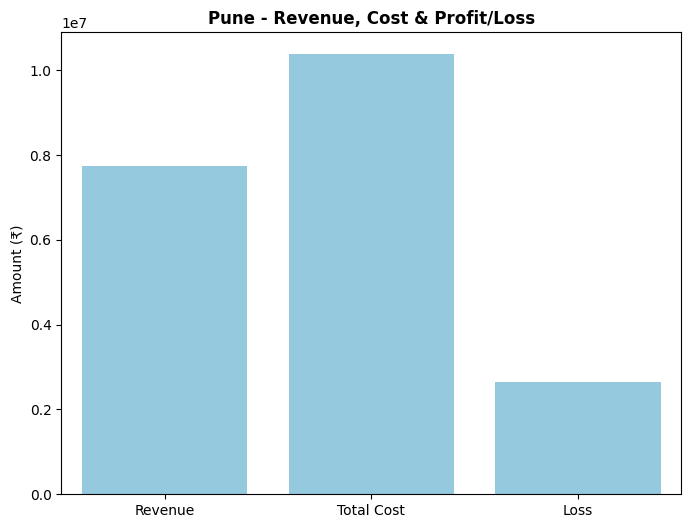

In [72]:
plt.figure(figsize=(8, 6))

# Determine profit/loss label
if profit_loss > 0:
    result_label = 'Profit'
    result_value = profit_loss

elif profit_loss < 0:
    result_label = 'Loss'
    result_value = abs(profit_loss)

else:
    result_label = 'Break-even'
    result_value = 0

values = pd.DataFrame({
    'Metric': ['Revenue', 'Total Cost', result_label],
    'Amount': [total_revenue, total_cost, result_value]
})

sns.barplot(
    data=values,
    x='Metric',
    y='Amount',
    color='skyblue'
)

plt.title('Pune - Revenue, Cost & Profit/Loss', fontweight='bold')
plt.xlabel('')
plt.ylabel('Amount (₹)')

plt.show()

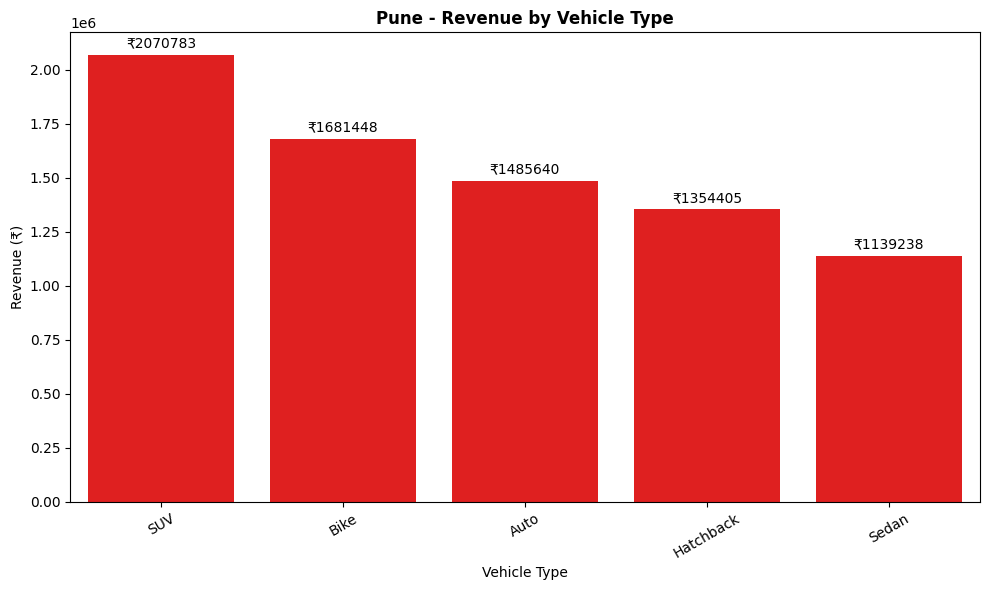

In [73]:
# Revenue by vehicle type

vehicle_revenue = (
    pune.groupby('Type_of_vehicle')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_revenue,
    x='Type_of_vehicle',
    y='Revenue',
    color='red'
)

plt.title('Pune - Revenue by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

# Add revenue values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

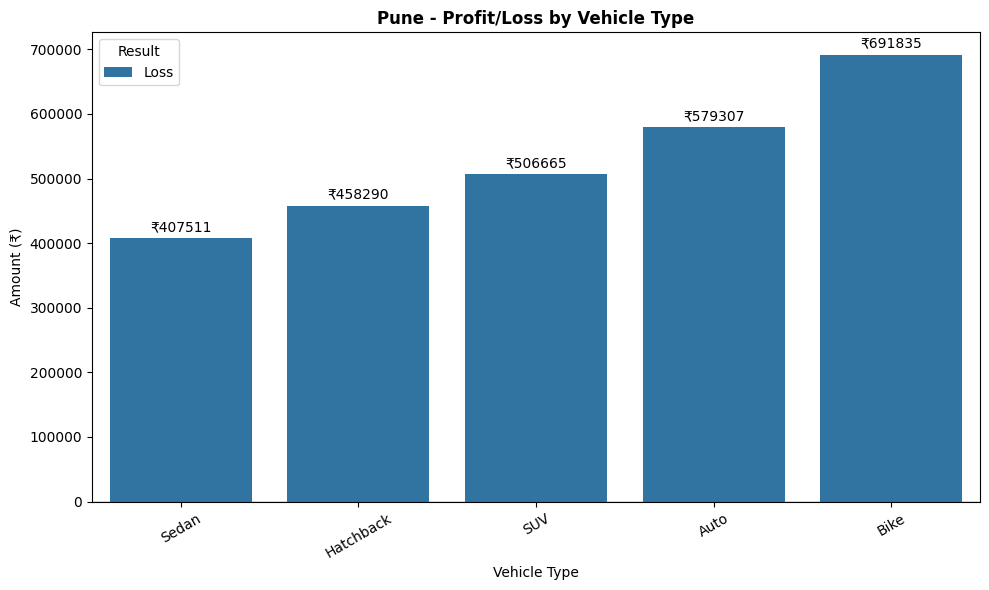

In [74]:
# Profit/Loss by vehicle type

vehicle_profit = (
    pune.groupby('Type_of_vehicle')['Profit_Loss']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Create a readable Profit/Loss label
vehicle_profit['Result'] = vehicle_profit['Profit_Loss'].apply(
    lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Break-even')
)

# Display absolute value for Loss
vehicle_profit['Amount'] = vehicle_profit['Profit_Loss'].abs()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_profit,
    x='Type_of_vehicle',
    y='Amount',
    hue='Result',
    dodge=False
)

plt.axhline(0, linewidth=1)

plt.title('Pune - Profit/Loss by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=30)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

## Mumbai Statistics 


In [75]:
mumbai = df[df['City'] == 'Mumbai'].copy()

In [76]:
print("Mumbai records:", len(mumbai))
mumbai.head()

Mumbai records: 157


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare,latitude,longitude
1,USER-79402-SBvr,Meredith Barnes,Mumbai,2025-10-13,2,Friday,21.08,High,Auto,9,17,1.89,50,282.96,1.3,367.85,19.076,72.8777
3,USER-41316-rDOx,Amber Perez,Mumbai,2025-10-15,0,Monday,26.80,High,Auto,25,188,7.52,76,351.60,1.6,562.56,19.076,72.8777
8,USER-89325-WkIX,Ashley Garrett,Mumbai,2026-07-20,11,Tuesday,6.53,High,SUV,50,63,1.26,22,158.36,1.3,205.87,19.076,72.8777
11,USER-39301-TOdo,George Chapman,Mumbai,2025-09-11,22,Tuesday,11.70,High,Auto,88,137,1.56,39,170.40,1.1,187.44,19.076,72.8777
14,USER-81080-fWpk,Angela Morton,Mumbai,2026-01-12,13,Friday,21.28,Jam,Auto,54,107,1.98,70,285.36,1.3,370.97,19.076,72.8777


In [77]:
mumbai_summary = {
    'Total Records': len(mumbai),
    'Total Ride Requests': mumbai['Ride_Requests'].sum(),
    'Average Distance (km)': mumbai['Distance_km'].mean(),
    'Average Trip Duration (min)': mumbai['Trip_Duration'].mean(),
    'Average Active Drivers': mumbai['No_of_active_drivers'].mean(),
    'Average Demand/Supply Ratio': mumbai['Demand_Supply_Ratio'].mean(),
    'Average Surge Multiplier': mumbai['Surge_Multiplier'].mean(),
    'Average Base Fare': mumbai['Base_Fare'].mean(),
    'Average Final Fare': mumbai['Final_Fare'].mean()
}

for key, value in mumbai_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Records: 157
Total Ride Requests: 18049
Average Distance (km): 17.20
Average Trip Duration (min): 51.80
Average Active Drivers: 49.74
Average Demand/Supply Ratio: 3.37
Average Surge Multiplier: 1.46
Average Base Fare: 248.99
Average Final Fare: 362.59


In [78]:
# Calculate Mumbai revenue

mumbai['Revenue'] = mumbai['Final_Fare']

total_revenue = mumbai['Revenue'].sum()

print("Mumbai Total Revenue: ₹", round(total_revenue, 2))

Mumbai Total Revenue: ₹ 56927.32


In [80]:
# See Mumbai by vehicle type

mumbai_vehicle = (
    mumbai.groupby('Type_of_vehicle')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Distance=('Distance_km', 'mean'),
        Avg_Trip_Duration=('Trip_Duration', 'mean'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Final_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

mumbai_vehicle

,Ride_Requests,Avg_Distance,Avg_Trip_Duration,Avg_Surge,Avg_Final_Fare
Type_of_vehicle,,,,,
Bike,4065,17.282647,51.588235,1.544118,354.983824
SUV,3813,16.996364,51.454545,1.454545,418.706098
Auto,3768,17.168788,50.121212,1.469697,335.572121
Hatchback,3499,15.334516,46.645161,1.406452,303.418710
Sedan,2904,19.635000,60.807692,1.430769,406.181154


In [82]:
# Mumbai by hour

mumbai_hourly = (
    mumbai.groupby('Hour_of_Day')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Active_Drivers=('No_of_active_drivers', 'mean'),
        Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Surge=('Surge_Multiplier', 'mean'),
        Final_Fare=('Final_Fare', 'mean')
    )
    .reset_index()
)

mumbai_hourly

,Hour_of_Day,Ride_Requests,Active_Drivers,Demand_Supply,Surge,Final_Fare
0,0,1277,42.888889,4.316667,1.588889,453.574444
1,1,403,35.500000,4.877500,1.475000,353.870000
2,2,608,59.571429,2.044286,1.214286,273.867143
3,3,395,71.750000,1.335000,1.275000,306.310000
4,4,395,57.600000,2.226000,1.120000,246.994000
5,5,814,61.000000,3.642000,1.560000,299.250000
6,6,846,33.285714,3.950000,1.557143,382.625714
7,7,1299,39.636364,4.591818,1.509091,313.860000
8,8,610,45.333333,3.175000,1.500000,417.483333
9,9,611,59.166667,1.800000,1.383333,282.070000


In [83]:
# Peak demand hour

mumbai_hourly.loc[
    mumbai_hourly['Ride_Requests'].idxmax()
]

Hour_of_Day          7.000000
Ride_Requests     1299.000000
Active_Drivers      39.636364
Demand_Supply        4.591818
Surge                1.509091
Final_Fare         313.860000
Name: 7, dtype: float64

In [84]:
# Highest surge hour

mumbai_hourly.loc[
    mumbai_hourly['Surge'].idxmax()
]

Hour_of_Day        16.000000
Ride_Requests     306.000000
Active_Drivers     26.666667
Demand_Supply       4.606667
Surge               1.766667
Final_Fare        503.286667
Name: 16, dtype: float64

In [85]:
# Highest demand/supply hour

mumbai_hourly.loc[
    mumbai_hourly['Demand_Supply'].idxmax()
]

Hour_of_Day         1.0000
Ride_Requests     403.0000
Active_Drivers     35.5000
Demand_Supply       4.8775
Surge               1.4750
Final_Fare        353.8700
Name: 1, dtype: float64

In [86]:
# Mumbai traffic analysis

mumbai_traffic = (
    mumbai.groupby('Traffic_Level')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Avg_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

mumbai_traffic

,Ride_Requests,Avg_Surge,Avg_Demand_Supply,Avg_Fare
Traffic_Level,,,,
High,5023,1.480000,3.695250,386.737500
Jam,5004,1.495238,3.657857,358.004762
Medium,4440,1.491892,3.203243,332.574628
Low,3582,1.384211,2.859474,371.483158


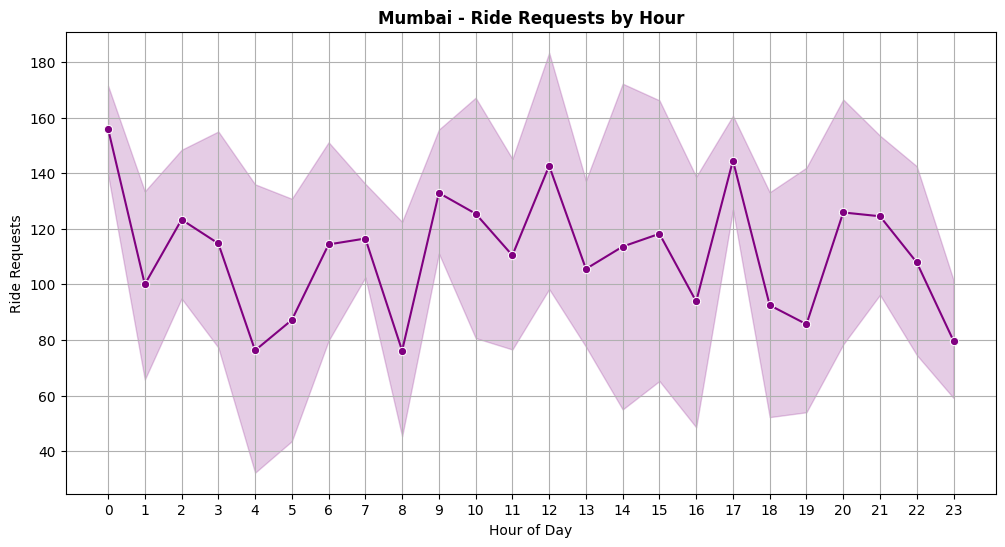

In [87]:
# Mumbai — Ride Requests by Hour

mumbai = df[df['City'] == 'Mumbai']

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=delhi,
    x='Hour_of_Day',
    y='Ride_Requests',
    marker='o',
    color='purple'
)

plt.title('Mumbai - Ride Requests by Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Ride Requests')
plt.xticks(range(24))
plt.grid(True)
plt.show()

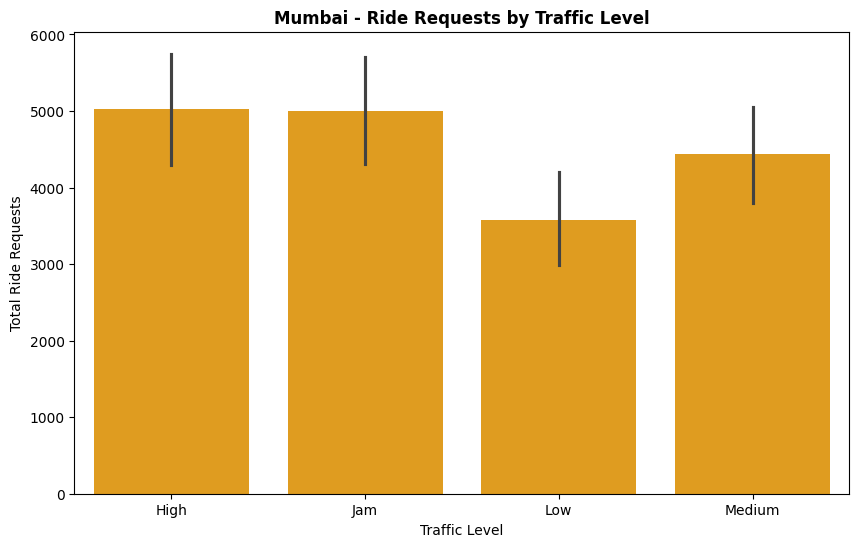

In [88]:
# Mumbai — Traffic Level vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=mumbai,
    x='Traffic_Level',
    y='Ride_Requests',
    estimator='sum',
    color='Orange'
)

plt.title('Mumbai - Ride Requests by Traffic Level', fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Total Ride Requests')
plt.show()

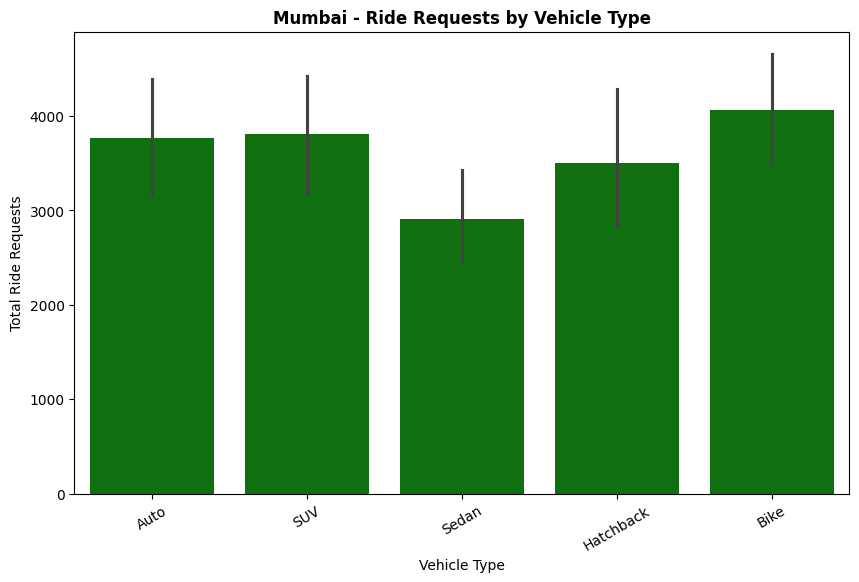

In [89]:
# Mumbai — Vehicle Type vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=mumbai,
    x='Type_of_vehicle',
    y='Ride_Requests',
    estimator='sum',
    color='Green'
)

plt.title('Mumbai - Ride Requests by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Ride Requests')
plt.xticks(rotation=30)
plt.show()

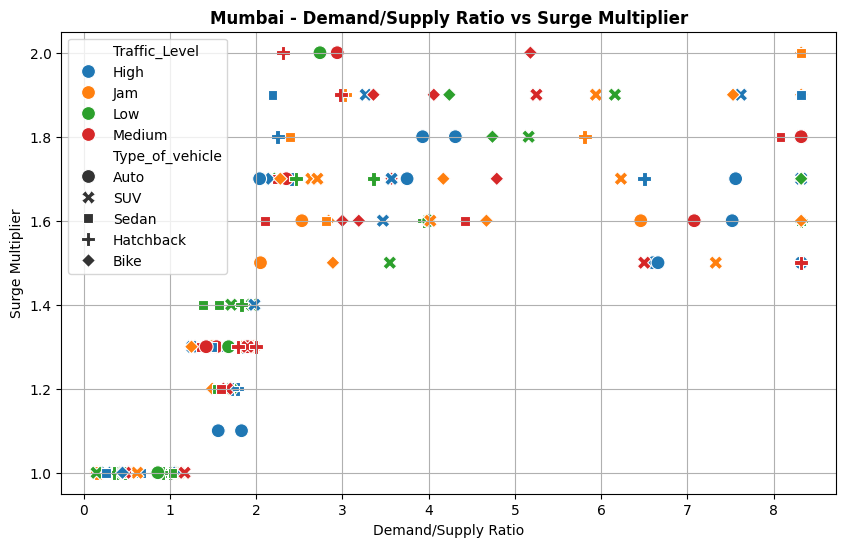

In [90]:
# Mumbai — Demand/Supply vs Surge Multiplier

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=mumbai,
    x='Demand_Supply_Ratio',
    y='Surge_Multiplier',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=100
)

plt.title('Mumbai - Demand/Supply Ratio vs Surge Multiplier', fontweight='bold')
plt.xlabel('Demand/Supply Ratio')
plt.ylabel('Surge Multiplier')
plt.grid(True)
plt.show()


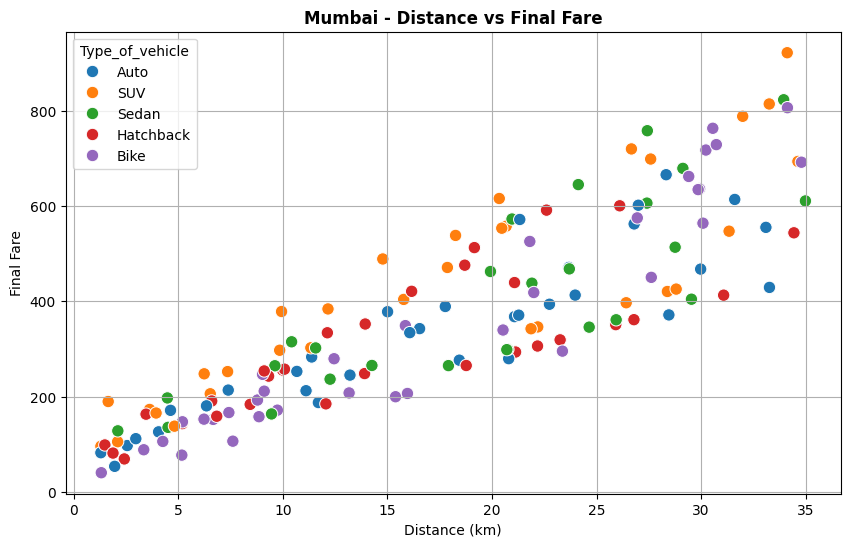

In [92]:
# Mumbai — Distance vs Final Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=mumbai,
    x='Distance_km',
    y='Final_Fare',
    hue='Type_of_vehicle',
    s=80
)

plt.title('Mumbai - Distance vs Final Fare', fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Final Fare')
plt.grid(True)
plt.show()

In [93]:
# Mumbai data
mumbai = df[df['City'] == 'Mumbai'].copy()

# COST ASSUMPTIONS
fuel_cost_per_km = 8          # ₹ per km
driver_cost_percentage = 0.60 # 60% of revenue
fixed_cost_per_ride = 200      # ₹ per ride

# REVENUE
mumbai['Revenue'] = (
    mumbai['Final_Fare'] *
    mumbai['Ride_Requests']
)

# COSTS
mumbai['Fuel_Cost'] = (
    mumbai['Distance_km'] *
    mumbai['Ride_Requests'] *
    fuel_cost_per_km
)

mumbai['Driver_Cost'] = (
    mumbai['Revenue'] *
    driver_cost_percentage
)

mumbai['Fixed_Cost'] = (
    mumbai['Ride_Requests'] *
    fixed_cost_per_ride
)

mumbai['Total_Cost'] = (
    mumbai['Fuel_Cost'] +
    mumbai['Driver_Cost'] +
    mumbai['Fixed_Cost']
)

# PROFIT / LOSS
mumbai['Profit_Loss'] = (
    mumbai['Revenue'] -
    mumbai['Total_Cost']
)

# TOTALS
total_revenue = mumbai['Revenue'].sum()
total_cost = mumbai['Total_Cost'].sum()
profit_loss = total_revenue - total_cost

print(f"Mumbai Revenue    : ₹{total_revenue:,.2f}")
print(f"Mumbai Total Cost : ₹{total_cost:,.2f}")


# PROFIT / LOSS RESULT
if profit_loss > 0:
    print(f"Mumbai Profit     : ₹{profit_loss:,.2f}")
    print("Result           : PROFIT")

elif profit_loss < 0:
    loss = abs(profit_loss)
    print(f"Mumbai Loss       : ₹{loss:,.2f}")
    print("Result           : LOSS")

else:
    print("Mumbai Profit/Loss : ₹0.00")
    print("Result            : BREAK-EVEN")

Mumbai Revenue    : ₹6,881,348.15
Mumbai Total Cost : ₹10,176,812.41
Mumbai Loss       : ₹3,295,464.26
Result           : LOSS


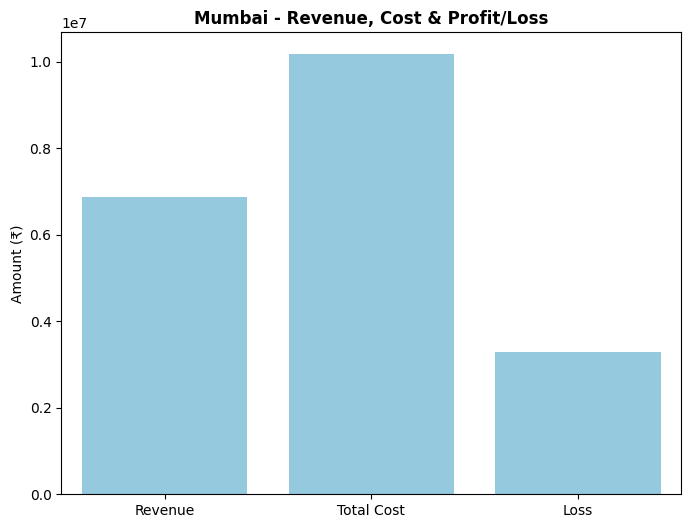

In [94]:
plt.figure(figsize=(8, 6))

# Determine profit/loss label
if profit_loss > 0:
    result_label = 'Profit'
    result_value = profit_loss

elif profit_loss < 0:
    result_label = 'Loss'
    result_value = abs(profit_loss)

else:
    result_label = 'Break-even'
    result_value = 0

values = pd.DataFrame({
    'Metric': ['Revenue', 'Total Cost', result_label],
    'Amount': [total_revenue, total_cost, result_value]
})

sns.barplot(
    data=values,
    x='Metric',
    y='Amount',
    color='skyblue'
)

plt.title('Mumbai - Revenue, Cost & Profit/Loss', fontweight='bold')
plt.xlabel('')
plt.ylabel('Amount (₹)')

plt.show()

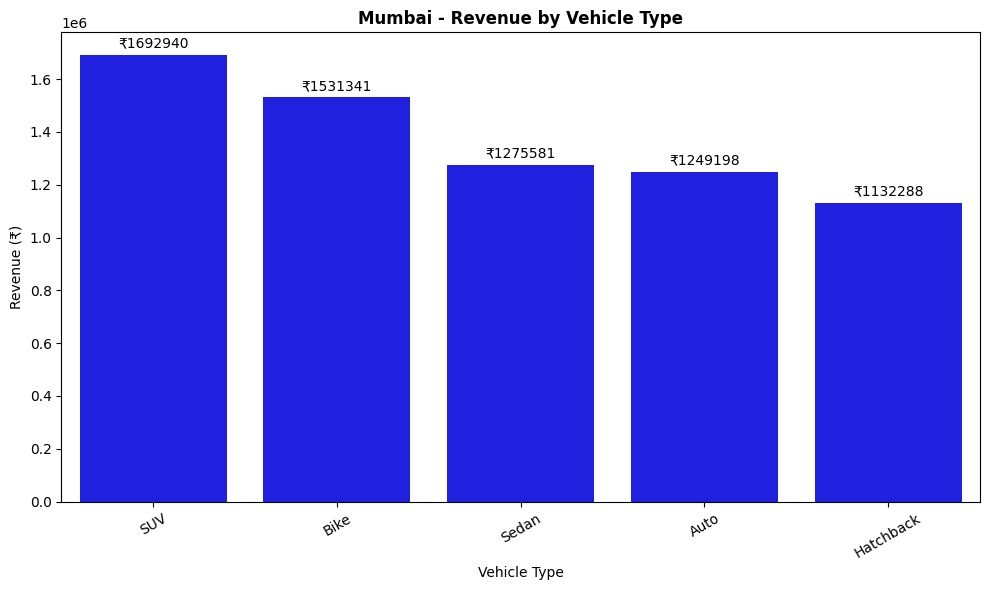

In [95]:
# Mumbai - Revenue by Vehicle Type

vehicle_revenue = (
    mumbai.groupby('Type_of_vehicle')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_revenue,
    x='Type_of_vehicle',
    y='Revenue',
    color='blue'
)

plt.title('Mumbai - Revenue by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

# Add revenue values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

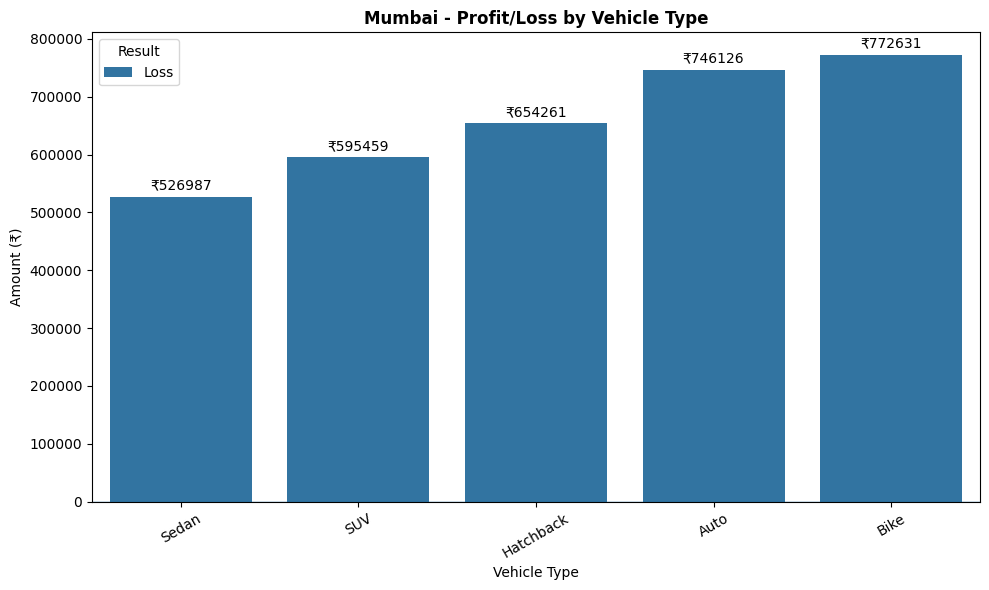

In [96]:
# Mumbai - Profit/Loss by Vehicle Type

vehicle_profit = (
    mumbai.groupby('Type_of_vehicle')['Profit_Loss']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Create a readable Profit/Loss label
vehicle_profit['Result'] = vehicle_profit['Profit_Loss'].apply(
    lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Break-even')
)

# Display absolute value for Loss
vehicle_profit['Amount'] = vehicle_profit['Profit_Loss'].abs()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_profit,
    x='Type_of_vehicle',
    y='Amount',
    hue='Result',
    dodge=False
)

plt.axhline(0, linewidth=1)

plt.title('Mumbai - Profit/Loss by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=30)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

## Bengaluru Statistics

In [97]:
bengaluru = df[df['City'] == 'Bengaluru'].copy()

print("Bengaluru records:", len(bengaluru))
bengaluru.head()

Bengaluru records: 157


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare,latitude,longitude
2,USER-40781-yfJs,Ian Cooper,Bengaluru,2026-06-16,6,Sunday,25.34,High,Hatchback,94,149,1.59,75,344.08,1.3,447.30,12.9716,77.5946
9,USER-43039-ffUF,Jack Galloway,Bengaluru,2026-06-11,23,Monday,9.32,Medium,Bike,64,107,1.67,32,126.84,1.2,152.21,12.9716,77.5946
16,USER-82081-leMe,John Calhoun,Bengaluru,2026-04-21,9,Wednesday,15.78,Low,Hatchback,63,10,0.16,60,229.36,1.0,229.36,12.9716,77.5946
22,USER-20450-wnRp,Lauren Hernandez,Bengaluru,2026-04-18,22,Thursday,11.60,Jam,Hatchback,90,176,1.96,39,179.20,1.2,215.04,12.9716,77.5946
40,USER-85067-gBxO,Jeffrey Wood,Bengaluru,2026-07-09,9,Saturday,21.80,Medium,SUV,88,145,1.65,53,341.60,1.2,409.92,12.9716,77.5946


In [98]:
bengaluru_summary = {
    'Total Records': len(bengaluru),
    'Total Ride Requests': bengaluru['Ride_Requests'].sum(),
    'Average Distance (km)': bengaluru['Distance_km'].mean(),
    'Average Trip Duration (min)': bengaluru['Trip_Duration'].mean(),
    'Average Active Drivers': bengaluru['No_of_active_drivers'].mean(),
    'Average Demand/Supply Ratio': bengaluru['Demand_Supply_Ratio'].mean(),
    'Average Surge Multiplier': bengaluru['Surge_Multiplier'].mean(),
    'Average Base Fare': bengaluru['Base_Fare'].mean(),
    'Average Final Fare': bengaluru['Final_Fare'].mean()
}

for key, value in bengaluru_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Records: 157
Total Ride Requests: 17564
Average Distance (km): 18.74
Average Trip Duration (min): 56.89
Average Active Drivers: 50.06
Average Demand/Supply Ratio: 3.12
Average Surge Multiplier: 1.46
Average Base Fare: 269.01
Average Final Fare: 393.86


In [99]:
# Calculate Bengaluru revenue

bengaluru['Revenue'] = bengaluru['Final_Fare']

total_revenue = bengaluru['Revenue'].sum()

print("Bengaluru Total Revenue: ₹", round(total_revenue, 2))

Bengaluru Total Revenue: ₹ 61836.59


In [100]:
# See Bengaluru by vehicle type

bengaluru_vehicle = (
    bengaluru.groupby('Type_of_vehicle')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Distance=('Distance_km', 'mean'),
        Avg_Trip_Duration=('Trip_Duration', 'mean'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Final_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

bengaluru_vehicle

,Ride_Requests,Avg_Distance,Avg_Trip_Duration,Avg_Surge,Avg_Final_Fare
Type_of_vehicle,,,,,
Hatchback,3975,17.346857,52.971429,1.457143,366.780000
SUV,3633,17.446129,54.419355,1.551613,452.192258
Sedan,3368,18.283611,56.333333,1.358333,366.099167
Bike,3295,19.957778,57.962963,1.455556,363.317778
Auto,3293,21.338214,64.178571,1.510714,428.292143


In [101]:
# Bengaluru by hour

bengaluru_hourly = (
    bengaluru.groupby('Hour_of_Day')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Active_Drivers=('No_of_active_drivers', 'mean'),
        Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Surge=('Surge_Multiplier', 'mean'),
        Final_Fare=('Final_Fare', 'mean')
    )
    .reset_index()
)

bengaluru_hourly

,Hour_of_Day,Ride_Requests,Active_Drivers,Demand_Supply,Surge,Final_Fare
0,0,463,44.500000,3.050000,1.600000,579.030000
1,1,1340,40.600000,4.480000,1.590000,427.243000
2,2,250,46.600000,2.062000,1.160000,308.634000
3,3,562,46.800000,3.502000,1.340000,410.768000
4,4,568,66.800000,2.744000,1.420000,284.758000
5,5,819,39.888889,3.237778,1.411111,439.384444
6,6,659,61.750000,3.637500,1.475000,437.995000
7,7,370,53.600000,1.262000,1.260000,286.416000
8,8,732,54.250000,2.326250,1.400000,290.708750
9,9,844,66.250000,2.280000,1.412500,333.300000


In [102]:
# Peak demand hour

bengaluru_hourly.loc[
    bengaluru_hourly['Ride_Requests'].idxmax()
]

Hour_of_Day         18.000000
Ride_Requests     1579.000000
Active_Drivers      44.928571
Demand_Supply        3.742143
Surge                1.521429
Final_Fare         456.398571
Name: 18, dtype: float64

In [103]:
# Highest surge hour

bengaluru_hourly.loc[
    bengaluru_hourly['Surge'].idxmax()
]

Hour_of_Day         10.000000
Ride_Requests     1065.000000
Active_Drivers      49.428571
Demand_Supply        3.840000
Surge                1.642857
Final_Fare         555.241429
Name: 10, dtype: float64

In [104]:
# Highest demand/supply hour

bengaluru_hourly.loc[
    bengaluru_hourly['Demand_Supply'].idxmax()
]

Hour_of_Day        11.0000
Ride_Requests     653.0000
Active_Drivers     38.5000
Demand_Supply       5.0350
Surge               1.6000
Final_Fare        356.8075
Name: 11, dtype: float64

In [105]:
# Bengaluru traffic analysis

bengaluru_traffic = (
    bengaluru.groupby('Traffic_Level')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Avg_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

bengaluru_traffic

,Ride_Requests,Avg_Surge,Avg_Demand_Supply,Avg_Fare
Traffic_Level,,,,
High,4897,1.502273,2.803409,449.405455
Jam,4681,1.469048,3.132143,369.430952
Medium,4148,1.444444,3.364444,383.738056
Low,3838,1.422857,3.230571,363.773714


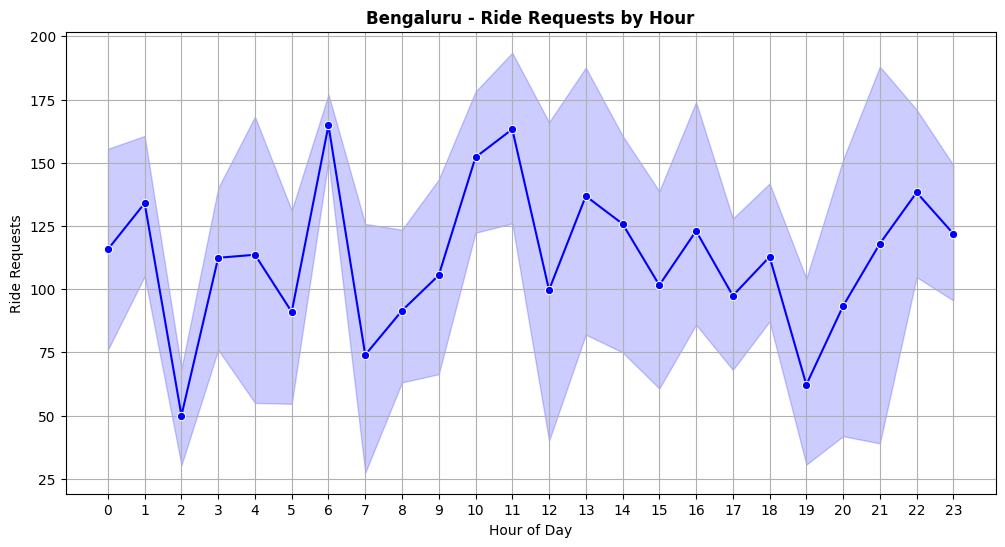

In [106]:
# Bengaluru — Ride Requests by Hour

bengaluru = df[df['City'] == 'Bengaluru']

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=bengaluru,
    x='Hour_of_Day',
    y='Ride_Requests',
    marker='o',
    color='Blue'
)

plt.title('Bengaluru - Ride Requests by Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Ride Requests')
plt.xticks(range(24))
plt.grid(True)
plt.show()

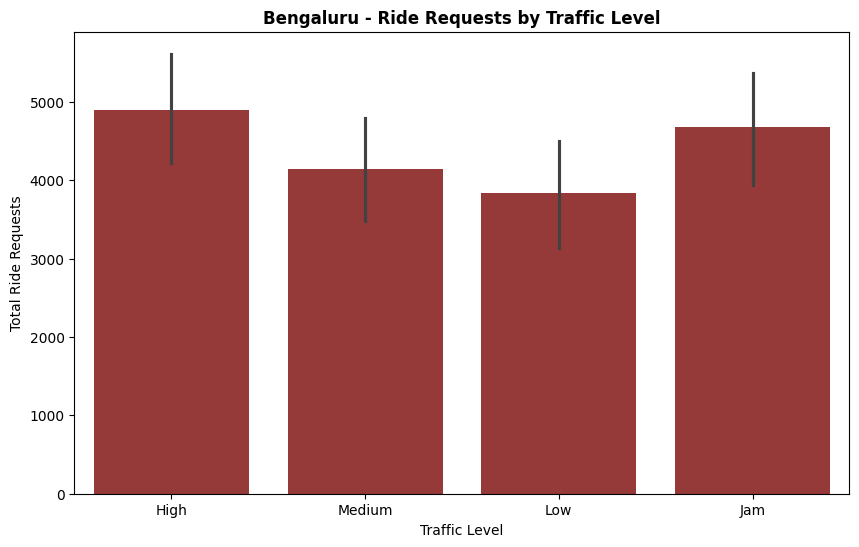

In [107]:
# Bengaluru — Traffic Level vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=bengaluru,
    x='Traffic_Level',
    y='Ride_Requests',
    estimator='sum',
    color='Brown'
)

plt.title('Bengaluru - Ride Requests by Traffic Level', fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Total Ride Requests')
plt.show()

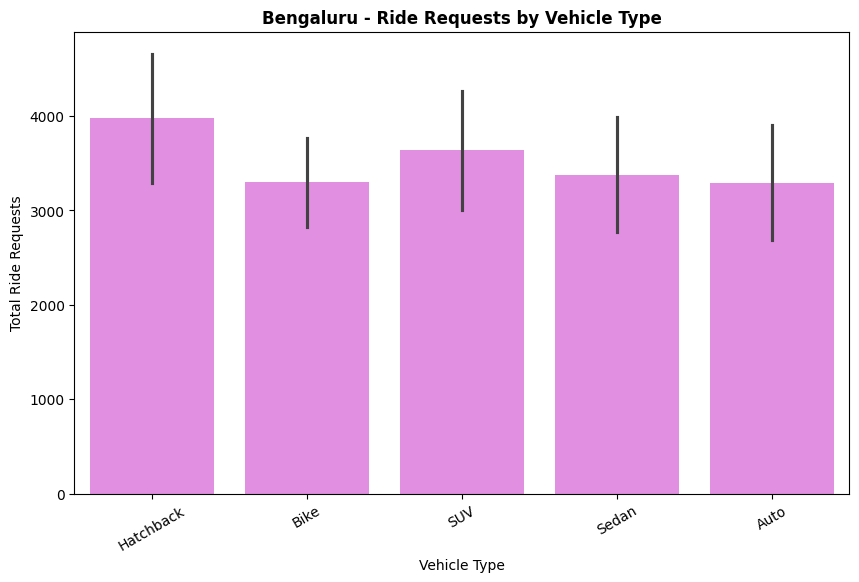

In [108]:
# Bengaluru — Vehicle Type vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=bengaluru,
    x='Type_of_vehicle',
    y='Ride_Requests',
    estimator='sum',
    color='Violet'
)

plt.title('Bengaluru - Ride Requests by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Ride Requests')
plt.xticks(rotation=30)
plt.show()

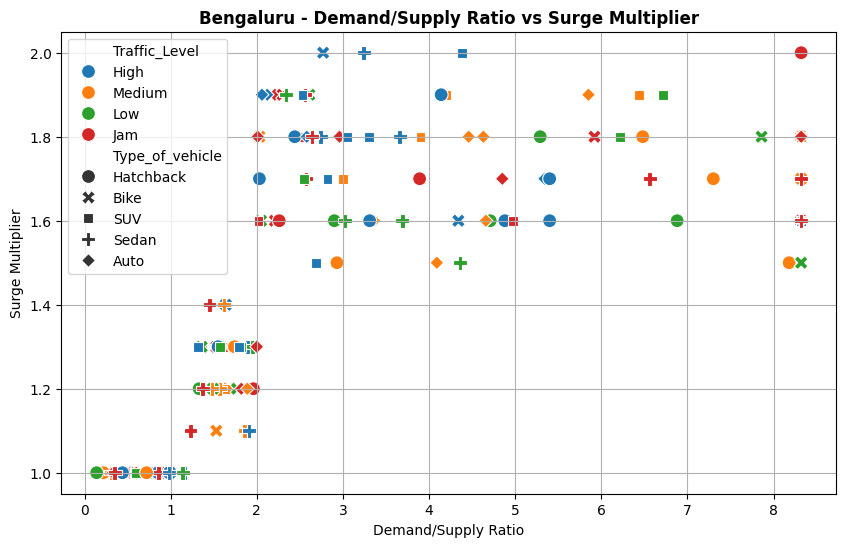

In [109]:
# Bengaluru — Demand/Supply vs Surge Multiplier

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=bengaluru,
    x='Demand_Supply_Ratio',
    y='Surge_Multiplier',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=100
)

plt.title('Bengaluru - Demand/Supply Ratio vs Surge Multiplier', fontweight='bold')
plt.xlabel('Demand/Supply Ratio')
plt.ylabel('Surge Multiplier')
plt.grid(True)
plt.show()

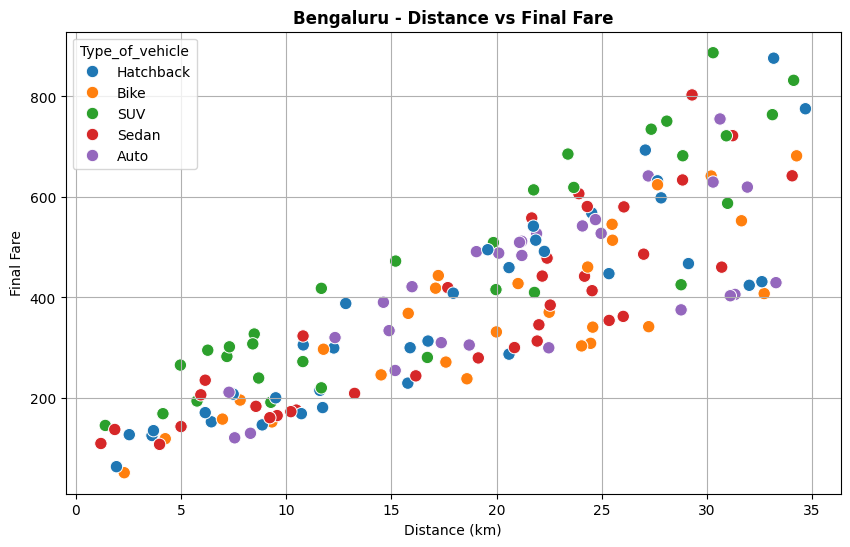

In [110]:
# Bengaluru — Distance vs Final Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=bengaluru,
    x='Distance_km',
    y='Final_Fare',
    hue='Type_of_vehicle',
    s=80
)

plt.title('Bengaluru - Distance vs Final Fare', fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Final Fare')
plt.grid(True)
plt.show()

In [111]:
#  Bengaluru data
bengaluru = df[df['City'] == 'Bengaluru'].copy()

# COST ASSUMPTIONS
fuel_cost_per_km = 8          # ₹ per km
driver_cost_percentage = 0.60 # 60% of revenue
fixed_cost_per_ride = 10      # ₹ per ride

# REVENUE
bengaluru['Revenue'] = (
    bengaluru['Final_Fare'] *
    bengaluru['Ride_Requests']
)

# COSTS
bengaluru['Fuel_Cost'] = (
    bengaluru['Distance_km'] *
    bengaluru['Ride_Requests'] *
    fuel_cost_per_km
)

bengaluru['Driver_Cost'] = (
    bengaluru['Revenue'] *
    driver_cost_percentage
)

bengaluru['Fixed_Cost'] = (
    bengaluru['Ride_Requests'] *
    fixed_cost_per_ride
)

bengaluru['Total_Cost'] = (
    bengaluru['Fuel_Cost'] +
    bengaluru['Driver_Cost'] +
    bengaluru['Fixed_Cost']
)


# PROFIT / LOSS
bengaluru['Profit_Loss'] = (
    bengaluru['Revenue'] -
    bengaluru['Total_Cost']
)


# TOTALS
total_revenue = bengaluru['Revenue'].sum()
total_cost = bengaluru['Total_Cost'].sum()
profit_loss = total_revenue - total_cost

print(f"Bengaluru Revenue    : ₹{total_revenue:,.2f}")
print(f"Bengaluru Total Cost : ₹{total_cost:,.2f}")

# PROFIT / LOSS RESULT
if profit_loss > 0:
    print(f"Delhi Profit     : ₹{profit_loss:,.2f}")
    print("Result           : PROFIT")

elif profit_loss < 0:
    loss = abs(profit_loss)
    print(f"Delhi Loss       : ₹{loss:,.2f}")
    print("Result           : LOSS")

else:
    print("Delhi Profit/Loss : ₹0.00")
    print("Result            : BREAK-EVEN")

Bengaluru Revenue    : ₹7,365,618.09
Bengaluru Total Cost : ₹7,216,339.41
Delhi Profit     : ₹149,278.68
Result           : PROFIT


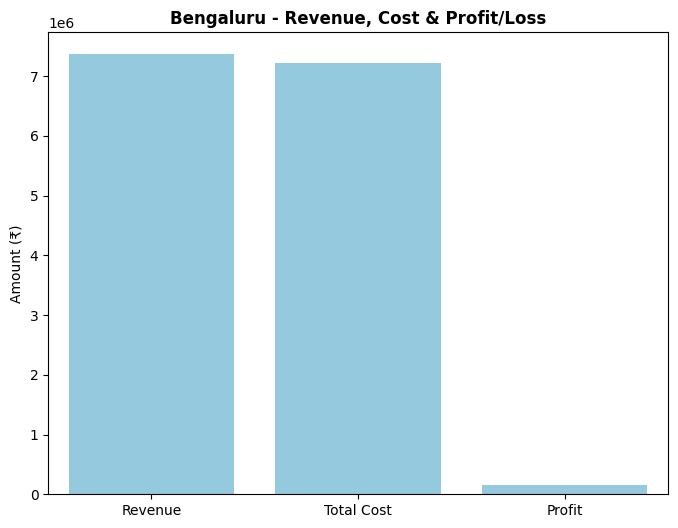

In [112]:
# Bengaluru - Revenue, Cost & Profit/Loss

plt.figure(figsize=(8, 6))

# Determine profit/loss label
if profit_loss > 0:
    result_label = 'Profit'
    result_value = profit_loss

elif profit_loss < 0:
    result_label = 'Loss'
    result_value = abs(profit_loss)

else:
    result_label = 'Break-even'
    result_value = 0

values = pd.DataFrame({
    'Metric': ['Revenue', 'Total Cost', result_label],
    'Amount': [total_revenue, total_cost, result_value]
})

sns.barplot(
    data=values,
    x='Metric',
    y='Amount',
    color='skyblue'
)

plt.title('Bengaluru - Revenue, Cost & Profit/Loss', fontweight='bold')
plt.xlabel('')
plt.ylabel('Amount (₹)')

plt.show()

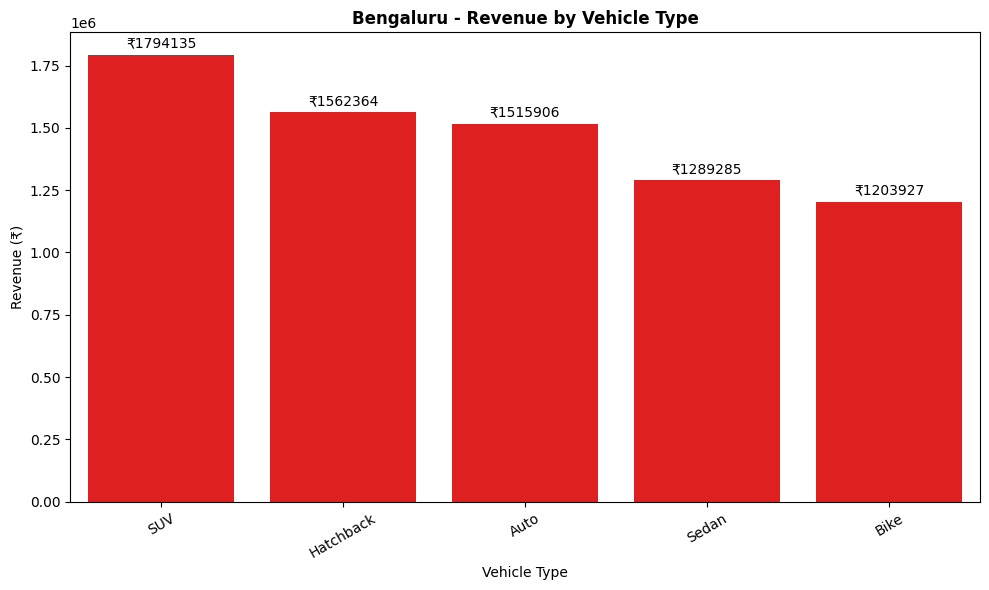

In [113]:
# Bengaluru - Revenue by Vehicle Type

vehicle_revenue = (
    bengaluru.groupby('Type_of_vehicle')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_revenue,
    x='Type_of_vehicle',
    y='Revenue',
    color='Red'
)

plt.title('Bengaluru - Revenue by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

# Add revenue values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

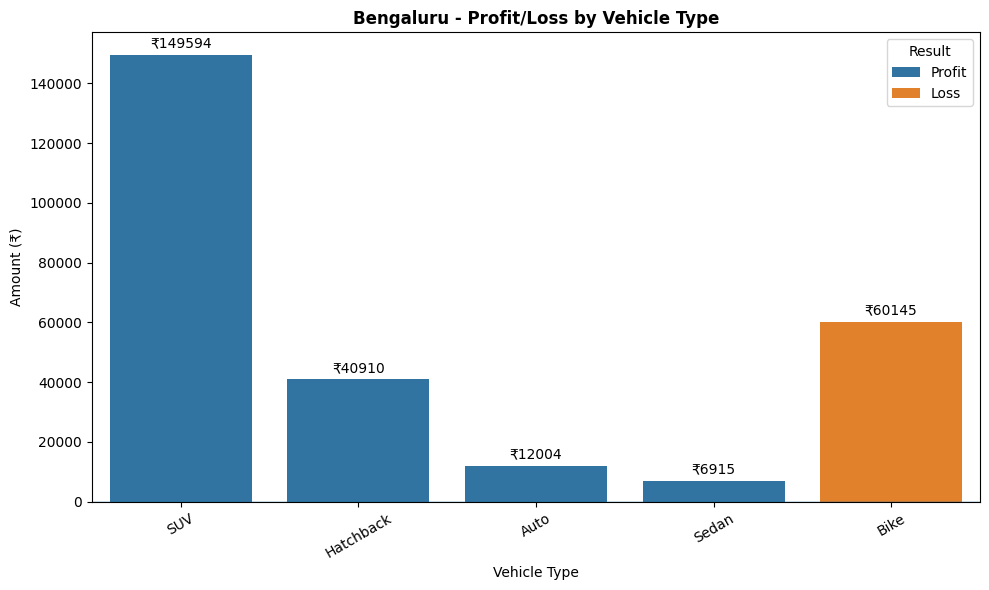

In [114]:
# Bengaluru - Profit/Loss by Vehicle Type

vehicle_profit = (
    bengaluru.groupby('Type_of_vehicle')['Profit_Loss']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Create a readable Profit/Loss label
vehicle_profit['Result'] = vehicle_profit['Profit_Loss'].apply(
    lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Break-even')
)

# Display absolute value for Loss
vehicle_profit['Amount'] = vehicle_profit['Profit_Loss'].abs()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_profit,
    x='Type_of_vehicle',
    y='Amount',
    hue='Result',
    dodge=False
)

plt.axhline(0, linewidth=1)

plt.title('Bengaluru - Profit/Loss by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=30)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

## Chennai Statistics

In [115]:
chennai = df[df['City'] == 'Chennai'].copy()

print("Chennai records:", len(chennai))
chennai.head()

Chennai records: 170


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare,latitude,longitude
4,USER-76483-RuXX,Kimberly Sanchez,Chennai,2025-09-06,10,Friday,4.48,High,SUV,53,34,0.64,18,133.76,1.0,133.76,13.0827,80.2707
12,USER-29973-YEZA,Michael Lewis,Chennai,2025-10-26,23,Saturday,20.09,Jam,Sedan,38,159,4.18,61,291.08,1.7,494.84,13.0827,80.2707
26,USER-06088-RUVV,Mrs. Stephanie Lee,Chennai,2026-04-19,3,Friday,23.41,Low,Sedan,50,118,2.36,63,330.92,1.8,595.66,13.0827,80.2707
27,USER-48465-zSsJ,Ryan Cortez,Chennai,2025-10-02,3,Friday,3.06,Jam,Bike,98,96,0.98,12,51.72,1.0,51.72,13.0827,80.2707
28,USER-44369-MPuD,Jennifer Bass,Chennai,2026-01-25,6,Friday,19.23,Jam,Bike,22,118,5.36,52,245.76,1.6,393.22,13.0827,80.2707


In [116]:
chennai_summary = {
    'Total Records': len(chennai),
    'Total Ride Requests': chennai['Ride_Requests'].sum(),
    'Average Distance (km)': chennai['Distance_km'].mean(),
    'Average Trip Duration (min)': chennai['Trip_Duration'].mean(),
    'Average Active Drivers': chennai['No_of_active_drivers'].mean(),
    'Average Demand/Supply Ratio': chennai['Demand_Supply_Ratio'].mean(),
    'Average Surge Multiplier': chennai['Surge_Multiplier'].mean(),
    'Average Base Fare': chennai['Base_Fare'].mean(),
    'Average Final Fare': chennai['Final_Fare'].mean()
}

for key, value in chennai_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Records: 170
Total Ride Requests: 18331
Average Distance (km): 17.22
Average Trip Duration (min): 53.43
Average Active Drivers: 55.81
Average Demand/Supply Ratio: 2.67
Average Surge Multiplier: 1.42
Average Base Fare: 247.42
Average Final Fare: 352.87


In [117]:
# Calculate Chennai revenue

chennai['Revenue'] = chennai['Final_Fare']

total_revenue = chennai['Revenue'].sum()

print("Chennai Total Revenue: ₹", round(total_revenue, 2))

Chennai Total Revenue: ₹ 59987.95


In [118]:
# See Chennai by vehicle type

chennai_vehicle = (
    chennai.groupby('Type_of_vehicle')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Distance=('Distance_km', 'mean'),
        Avg_Trip_Duration=('Trip_Duration', 'mean'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Final_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

chennai_vehicle

,Ride_Requests,Avg_Distance,Avg_Trip_Duration,Avg_Surge,Avg_Final_Fare
Type_of_vehicle,,,,,
Auto,4204,18.160000,56.000000,1.408108,347.302162
Bike,3981,16.936341,52.634146,1.341463,296.488780
Sedan,3640,15.766875,46.625000,1.525000,363.680000
SUV,3290,18.078000,58.666667,1.430000,434.065333
Hatchback,3216,17.163333,53.366667,1.400000,344.067000


In [119]:
# Chennai by hour

chennai_hourly = (
    chennai.groupby('Hour_of_Day')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Active_Drivers=('No_of_active_drivers', 'mean'),
        Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Surge=('Surge_Multiplier', 'mean'),
        Final_Fare=('Final_Fare', 'mean')
    )
    .reset_index()
)

chennai_hourly

,Hour_of_Day,Ride_Requests,Active_Drivers,Demand_Supply,Surge,Final_Fare
0,0,345,36.333333,4.323333,1.700000,230.750000
1,1,1087,53.300000,3.122000,1.400000,311.622000
2,2,406,44.666667,4.053333,1.700000,597.686667
3,3,985,48.000000,2.470000,1.400000,275.935455
4,4,1286,59.111111,3.313333,1.544444,326.596667
5,5,720,48.000000,3.584000,1.760000,568.332000
6,6,551,59.833333,2.128333,1.333333,357.891667
7,7,296,61.000000,1.930000,1.300000,362.676667
8,8,668,61.000000,2.151667,1.350000,202.118333
9,9,858,42.571429,3.695714,1.442857,390.865714


In [120]:
# Peak demand hour

chennai_hourly.loc[
    chennai_hourly['Ride_Requests'].idxmax()
]

Hour_of_Day         21.000
Ride_Requests     1415.000
Active_Drivers      52.200
Demand_Supply        3.145
Surge                1.710
Final_Fare         571.889
Name: 21, dtype: float64

In [121]:
# Highest surge hour

chennai_hourly.loc[
    chennai_hourly['Surge'].idxmax()
]

Hour_of_Day         5.000
Ride_Requests     720.000
Active_Drivers     48.000
Demand_Supply       3.584
Surge               1.760
Final_Fare        568.332
Name: 5, dtype: float64

In [122]:
# Highest demand/supply hour

chennai_hourly.loc[
    chennai_hourly['Demand_Supply'].idxmax()
]

Hour_of_Day         0.000000
Ride_Requests     345.000000
Active_Drivers     36.333333
Demand_Supply       4.323333
Surge               1.700000
Final_Fare        230.750000
Name: 0, dtype: float64

In [123]:
# Chennai traffic analysis

chennai_traffic = (
    chennai.groupby('Traffic_Level')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Avg_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

chennai_traffic

,Ride_Requests,Avg_Surge,Avg_Demand_Supply,Avg_Fare
Traffic_Level,,,,
Jam,5185,1.444681,2.727021,353.268298
High,5010,1.400000,2.678723,358.618936
Low,4223,1.440541,2.985676,363.332973
Medium,3913,1.379487,2.282564,335.536667


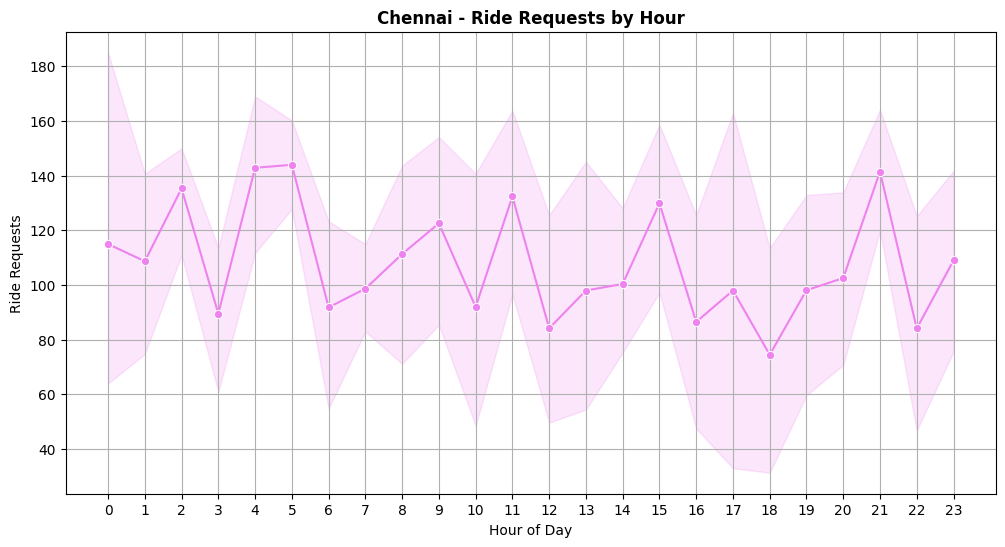

In [124]:
# Ride Requests by Hour

chennai = df[df['City'] == 'Chennai']

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=chennai,
    x='Hour_of_Day',
    y='Ride_Requests',
    marker='o',
    color='Violet'
)

plt.title('Chennai - Ride Requests by Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Ride Requests')
plt.xticks(range(24))
plt.grid(True)
plt.show()

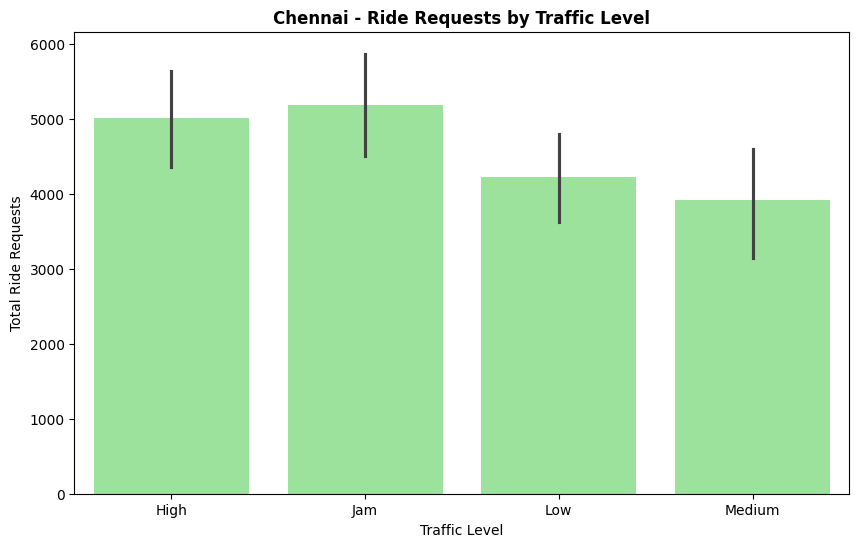

In [125]:
# Traffic Level vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=chennai,
    x='Traffic_Level',
    y='Ride_Requests',
    estimator='sum',
    color='LightGreen'
)

plt.title('Chennai - Ride Requests by Traffic Level', fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Total Ride Requests')
plt.show()


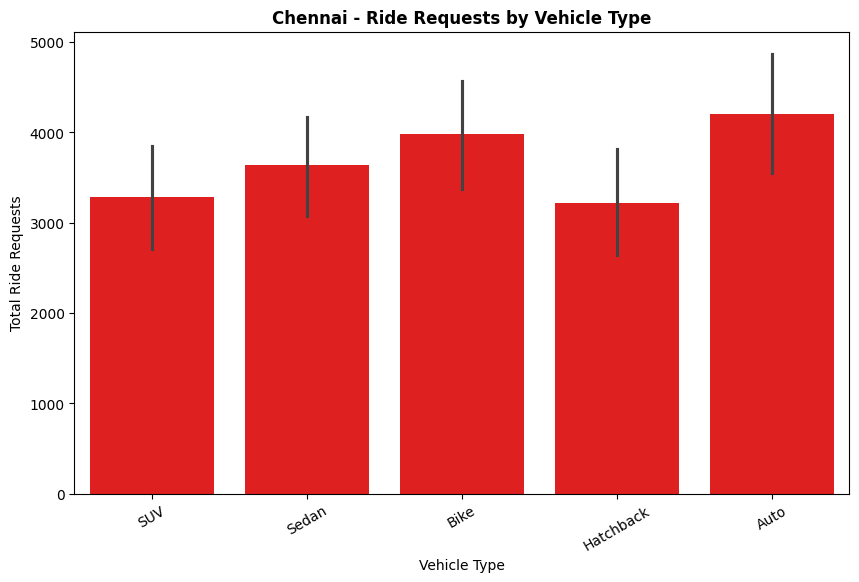

In [126]:
# Vehicle Type vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=chennai,
    x='Type_of_vehicle',
    y='Ride_Requests',
    estimator='sum',
    color='Red'
)

plt.title('Chennai - Ride Requests by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Ride Requests')
plt.xticks(rotation=30)
plt.show()

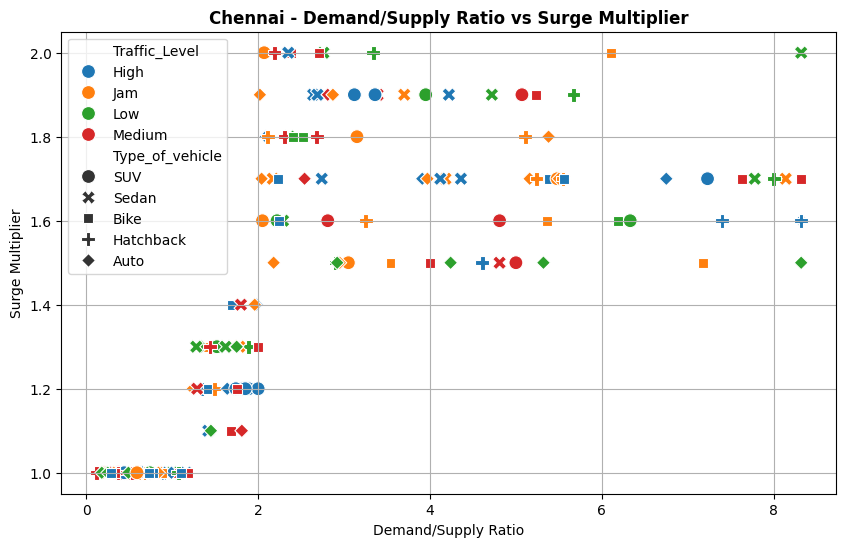

In [127]:
# Demand/Supply vs Surge Multiplier

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=chennai,
    x='Demand_Supply_Ratio',
    y='Surge_Multiplier',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=100
)

plt.title('Chennai - Demand/Supply Ratio vs Surge Multiplier', fontweight='bold')
plt.xlabel('Demand/Supply Ratio')
plt.ylabel('Surge Multiplier')
plt.grid(True)
plt.show()


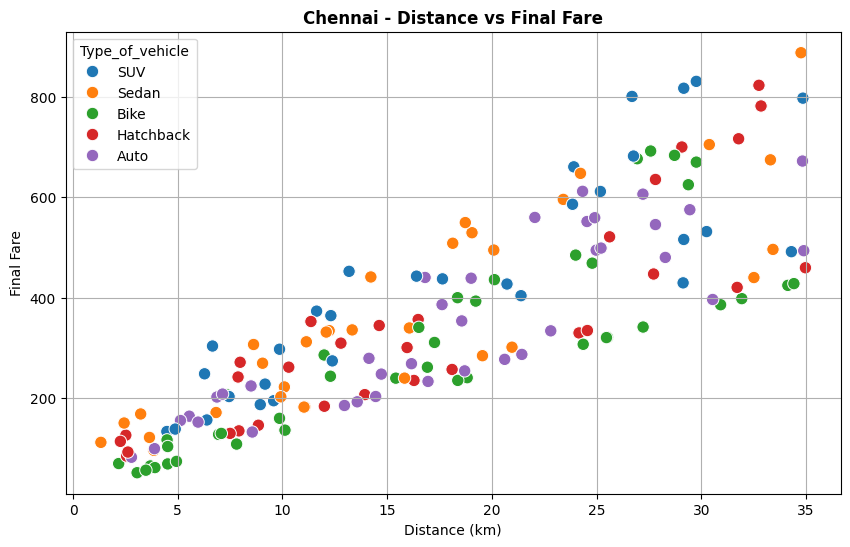

In [128]:
# Distance vs Final Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=chennai,
    x='Distance_km',
    y='Final_Fare',
    hue='Type_of_vehicle',
    s=80
)

plt.title('Chennai - Distance vs Final Fare', fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Final Fare')
plt.grid(True)
plt.show()

In [129]:
# Chennai data
chennai = df[df['City'] == 'Chennai'].copy()

# -----------------------------
# COST ASSUMPTIONS
# -----------------------------
fuel_cost_per_km = 8          # ₹ per km
driver_cost_percentage = 0.60 # 60% of revenue
fixed_cost_per_ride = 200      # ₹ per ride

# -----------------------------
# REVENUE
# -----------------------------
chennai['Revenue'] = (
    chennai['Final_Fare'] *
    chennai['Ride_Requests']
)

# -----------------------------
# COSTS
# -----------------------------
chennai['Fuel_Cost'] = (
    chennai['Distance_km'] *
    chennai['Ride_Requests'] *
    fuel_cost_per_km
)

chennai['Driver_Cost'] = (
    chennai['Revenue'] *
    driver_cost_percentage
)

chennai['Fixed_Cost'] = (
    chennai['Ride_Requests'] *
    fixed_cost_per_ride
)

chennai['Total_Cost'] = (
    chennai['Fuel_Cost'] +
    chennai['Driver_Cost'] +
    chennai['Fixed_Cost']
)

# -----------------------------
# PROFIT / LOSS
# -----------------------------
chennai['Profit_Loss'] = (
    chennai['Revenue'] -
    chennai['Total_Cost']
)

# -----------------------------
# TOTALS
# -----------------------------
total_revenue = chennai['Revenue'].sum()
total_cost = chennai['Total_Cost'].sum()
profit_loss = total_revenue - total_cost

print(f"Chennai Revenue    : ₹{total_revenue:,.2f}")
print(f"Chennai Total Cost : ₹{total_cost:,.2f}")

# -----------------------------
# PROFIT / LOSS RESULT
# -----------------------------
if profit_loss > 0:
    print(f"Chennai Profit     : ₹{profit_loss:,.2f}")
    print("Result           : PROFIT")

elif profit_loss < 0:
    loss = abs(profit_loss)
    print(f"Chennai Loss       : ₹{loss:,.2f}")
    print("Result           : LOSS")

else:
    print("Chennai Profit/Loss : ₹0.00")
    print("Result            : BREAK-EVEN")

Chennai Revenue    : ₹7,039,114.72
Chennai Total Cost : ₹10,425,912.67
Chennai Loss       : ₹3,386,797.95
Result           : LOSS


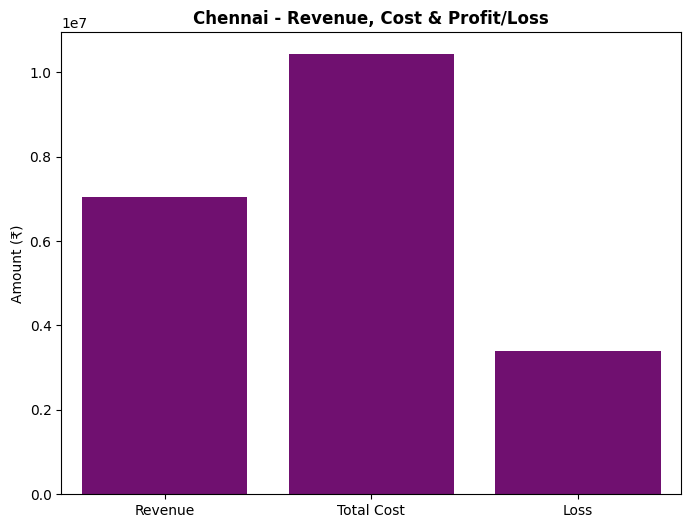

In [130]:
plt.figure(figsize=(8, 6))

# Determine profit/loss label
if profit_loss > 0:
    result_label = 'Profit'
    result_value = profit_loss

elif profit_loss < 0:
    result_label = 'Loss'
    result_value = abs(profit_loss)

else:
    result_label = 'Break-even'
    result_value = 0

values = pd.DataFrame({
    'Metric': ['Revenue', 'Total Cost', result_label],
    'Amount': [total_revenue, total_cost, result_value]
})

sns.barplot(
    data=values,
    x='Metric',
    y='Amount',
    color='Purple'
)

plt.title('Chennai - Revenue, Cost & Profit/Loss', fontweight='bold')
plt.xlabel('')
plt.ylabel('Amount (₹)')

plt.show()

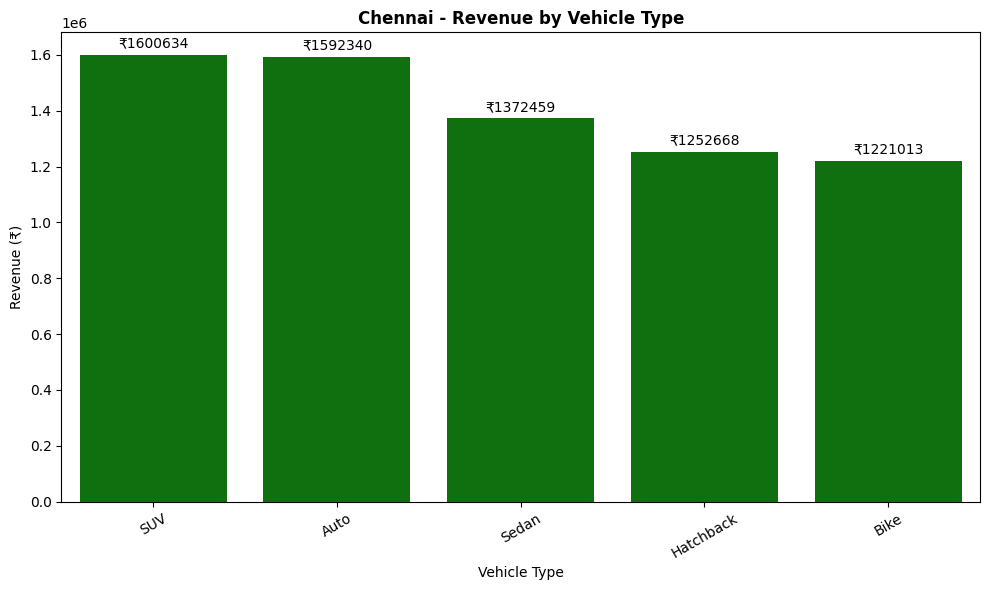

In [131]:
vehicle_revenue = (
    chennai.groupby('Type_of_vehicle')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_revenue,
    x='Type_of_vehicle',
    y='Revenue',
    color='Green'
)

plt.title('Chennai - Revenue by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

# Add revenue values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()


C:\Users\papus\AppData\Local\Temp\ipykernel_448\3222300654.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:pink'` for the same effect.

  ax = sns.barplot(


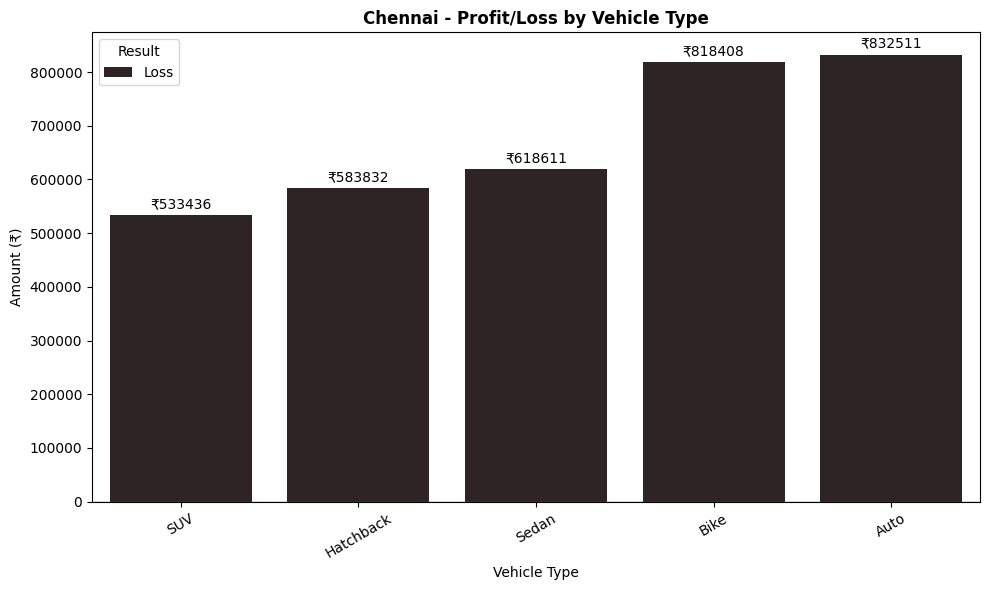

In [132]:
vehicle_profit = (
    chennai.groupby('Type_of_vehicle')['Profit_Loss']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Create a readable Profit/Loss label
vehicle_profit['Result'] = vehicle_profit['Profit_Loss'].apply(
    lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Break-even')
)

# Display absolute value for Loss
vehicle_profit['Amount'] = vehicle_profit['Profit_Loss'].abs()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_profit,
    x='Type_of_vehicle',
    y='Amount',
    hue='Result',
    dodge=False,
    color='pink'
)

plt.axhline(0, linewidth=1)

plt.title('Chennai - Profit/Loss by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=30)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

## Hyderabad Statistics

In [133]:
hyderabad = df[df['City'] == 'Hyderabad'].copy()

print("Hyderabad records:", len(hyderabad))
hyderabad.head()

Hyderabad records: 155


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare,latitude,longitude
6,USER-71012-OkYR,Zachary Taylor,Hyderabad,2026-01-18,9,Monday,29.20,Jam,Hatchback,84,102,1.21,86,390.40,1.1,429.44,17.385,78.4867
7,USER-01845-hsBk,Tricia Valencia,Hyderabad,2026-01-30,9,Friday,34.50,High,Hatchback,34,35,1.03,97,454.00,1.0,454.00,17.385,78.4867
13,USER-10651-pmmI,Scott Brown,Hyderabad,2026-01-28,4,Sunday,18.32,High,SUV,16,22,1.38,64,299.84,1.3,389.79,17.385,78.4867
30,USER-67632-PSaW,Laura Higgins,Hyderabad,2026-06-27,2,Friday,32.50,Jam,Bike,35,52,1.49,93,405.00,1.2,486.00,17.385,78.4867
33,USER-58122-oySj,Dustin Nelson,Hyderabad,2026-05-02,1,Tuesday,20.69,Jam,Sedan,74,25,0.34,66,298.28,1.0,298.28,17.385,78.4867


In [134]:
hyderabad_summary = {
    'Total Records': len(hyderabad),
    'Total Ride Requests': hyderabad['Ride_Requests'].sum(),
    'Average Distance (km)': hyderabad['Distance_km'].mean(),
    'Average Trip Duration (min)': hyderabad['Trip_Duration'].mean(),
    'Average Active Drivers': hyderabad['No_of_active_drivers'].mean(),
    'Average Demand/Supply Ratio': hyderabad['Demand_Supply_Ratio'].mean(),
    'Average Surge Multiplier': hyderabad['Surge_Multiplier'].mean(),
    'Average Base Fare': hyderabad['Base_Fare'].mean(),
    'Average Final Fare': hyderabad['Final_Fare'].mean()
}

for key, value in hyderabad_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Records: 155
Total Ride Requests: 15355
Average Distance (km): 17.63
Average Trip Duration (min): 54.61
Average Active Drivers: 53.70
Average Demand/Supply Ratio: 2.64
Average Surge Multiplier: 1.39
Average Base Fare: 255.05
Average Final Fare: 348.84


In [135]:
# Calculate Hyderabad revenue

hyderabad['Revenue'] = hyderabad['Final_Fare']

total_revenue = hyderabad['Revenue'].sum()

print("Hyderabad Total Revenue: ₹", round(total_revenue, 2))

Hyderabad Total Revenue: ₹ 54069.51


In [136]:
# See Hyderabad by vehicle type

hyderabad_vehicle = (
    hyderabad.groupby('Type_of_vehicle')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Distance=('Distance_km', 'mean'),
        Avg_Trip_Duration=('Trip_Duration', 'mean'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Final_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

hyderabad_vehicle

,Ride_Requests,Avg_Distance,Avg_Trip_Duration,Avg_Surge,Avg_Final_Fare
Type_of_vehicle,,,,,
Hatchback,3852,20.358333,61.583333,1.422222,391.026944
SUV,3095,16.300606,52.272727,1.318182,360.336667
Auto,3039,15.983548,52.161290,1.361290,302.860645
Bike,2701,17.114138,52.241379,1.410345,299.314483
Sedan,2668,18.064615,53.461538,1.423077,385.870385


In [137]:
# Hyderabad by hour

hyderabad_hourly = (
    hyderabad.groupby('Hour_of_Day')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Active_Drivers=('No_of_active_drivers', 'mean'),
        Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Surge=('Surge_Multiplier', 'mean'),
        Final_Fare=('Final_Fare', 'mean')
    )
    .reset_index()
)

hyderabad_hourly

,Hour_of_Day,Ride_Requests,Active_Drivers,Demand_Supply,Surge,Final_Fare
0,0,528,60.625000,1.592500,1.225000,310.038750
1,1,561,58.166667,1.661667,1.350000,263.883333
2,2,1065,60.166667,2.219167,1.300000,288.223333
3,3,669,53.166667,2.846667,1.516667,435.006667
4,4,583,55.666667,1.986667,1.416667,243.971667
5,5,573,50.600000,3.074000,1.540000,464.252000
6,6,678,59.400000,3.726000,1.460000,391.294000
7,7,357,51.000000,2.023333,1.400000,299.683333
8,8,892,60.888889,2.583333,1.388889,321.016667
9,9,820,47.428571,2.942857,1.371429,397.541429


In [138]:
# Peak demand hour

hyderabad_hourly.loc[
    hyderabad_hourly['Ride_Requests'].idxmax()
]

Hour_of_Day         17.000000
Ride_Requests     1095.000000
Active_Drivers      58.636364
Demand_Supply        2.485455
Surge                1.345455
Final_Fare         338.090909
Name: 17, dtype: float64

In [139]:
# Highest surge hour

hyderabad_hourly.loc[
    hyderabad_hourly['Surge'].idxmax()
]

Hour_of_Day        15.0000
Ride_Requests     409.0000
Active_Drivers     15.5000
Demand_Supply       5.5325
Surge               1.8750
Final_Fare        452.6450
Name: 15, dtype: float64

In [140]:
# Highest demand/supply hour

hyderabad_hourly.loc[
    hyderabad_hourly['Demand_Supply'].idxmax()
]

Hour_of_Day        22.000000
Ride_Requests     797.000000
Active_Drivers     26.333333
Demand_Supply       5.753333
Surge               1.600000
Final_Fare        406.771667
Name: 22, dtype: float64

In [141]:
# Hyderabad traffic analysis

hyderabad_traffic = (
    hyderabad.groupby('Traffic_Level')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Avg_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

hyderabad_traffic

,Ride_Requests,Avg_Surge,Avg_Demand_Supply,Avg_Fare
Traffic_Level,,,,
Low,4962,1.404082,2.735714,343.610408
Jam,4079,1.357778,2.310889,360.736889
High,3517,1.429412,3.141471,376.847353
Medium,2797,1.344444,2.373704,303.208519


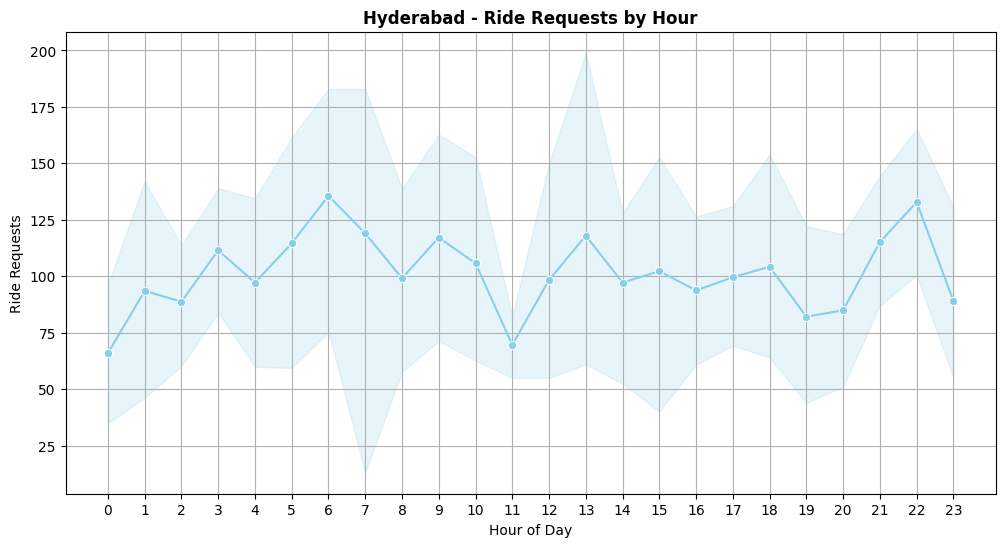

In [142]:
# Ride Requests by Hour

hyderabad = df[df['City'] == 'Hyderabad']

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=hyderabad,
    x='Hour_of_Day',
    y='Ride_Requests',
    marker='o',
    color='skyblue'
)

plt.title('Hyderabad - Ride Requests by Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Ride Requests')
plt.xticks(range(24))
plt.grid(True)
plt.show()


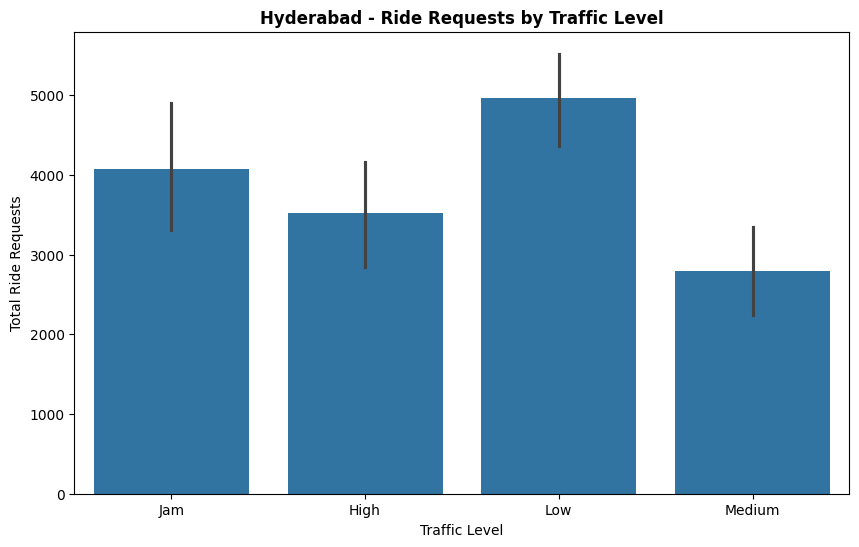

In [143]:
# Traffic Level vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=hyderabad,
    x='Traffic_Level',
    y='Ride_Requests',
    estimator='sum'
)

plt.title('Hyderabad - Ride Requests by Traffic Level', fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Total Ride Requests')
plt.show()

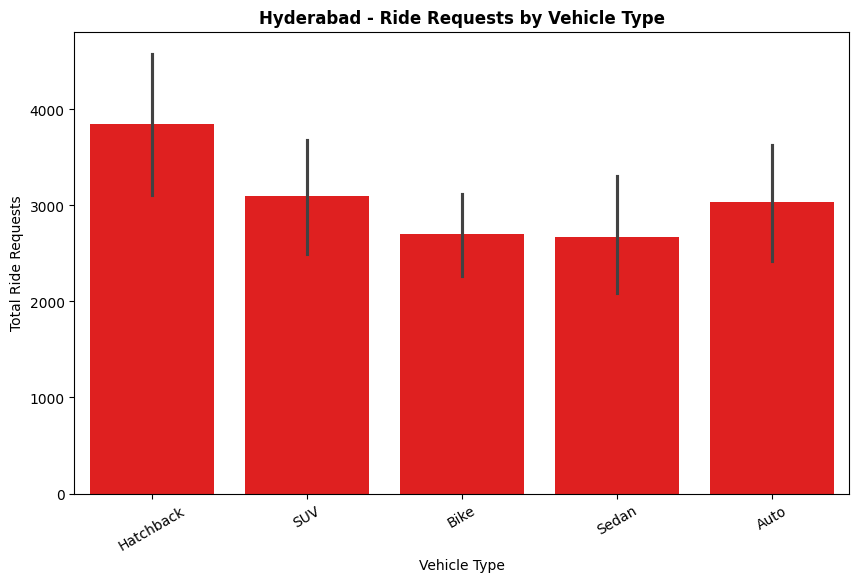

In [144]:
# Vehicle Type vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=hyderabad,
    x='Type_of_vehicle',
    y='Ride_Requests',
    estimator='sum',
    color='Red'
)

plt.title('Hyderabad - Ride Requests by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Ride Requests')
plt.xticks(rotation=30)
plt.show()

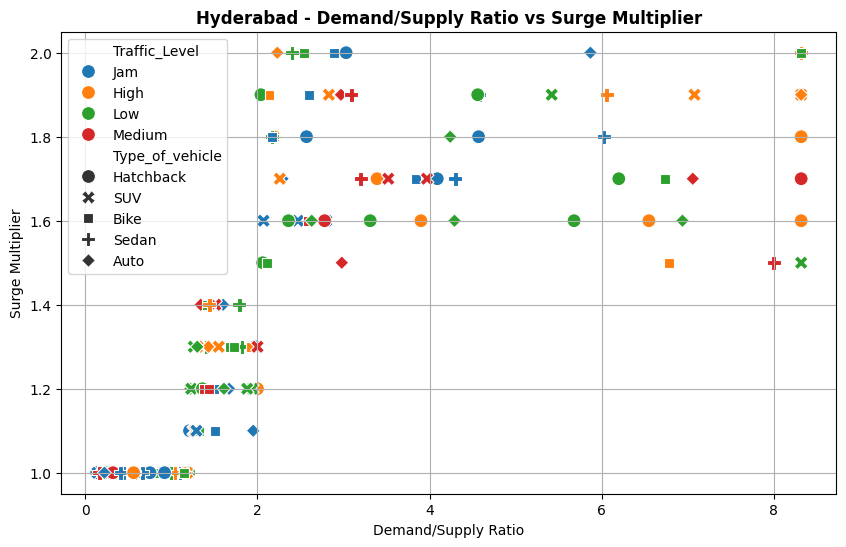

In [145]:
# Demand/Supply vs Surge Multiplier 

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=hyderabad,
    x='Demand_Supply_Ratio',
    y='Surge_Multiplier',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=100
)

plt.title('Hyderabad - Demand/Supply Ratio vs Surge Multiplier', fontweight='bold')
plt.xlabel('Demand/Supply Ratio')
plt.ylabel('Surge Multiplier')
plt.grid(True)
plt.show()


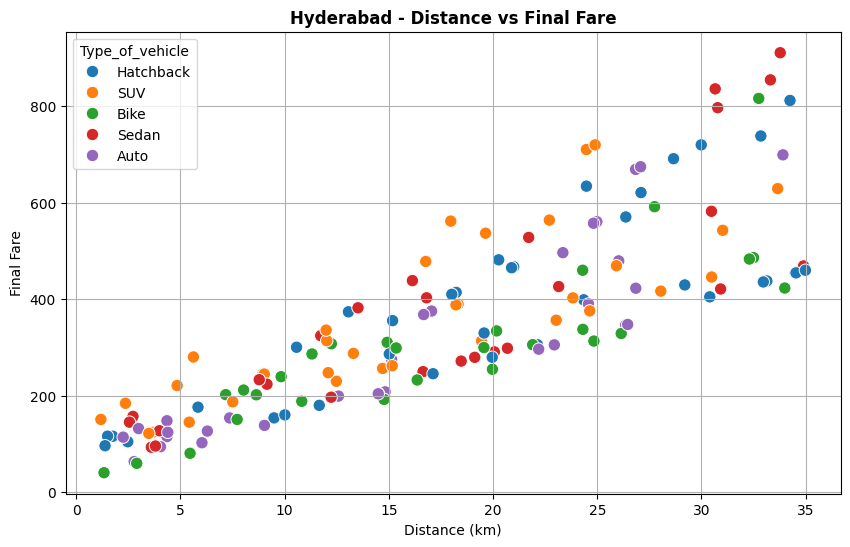

In [146]:
# Distance vs Final Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=hyderabad,
    x='Distance_km',
    y='Final_Fare',
    hue='Type_of_vehicle',
    s=80
)

plt.title('Hyderabad - Distance vs Final Fare', fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Final Fare')
plt.grid(True)
plt.show()

In [147]:
# Hyderabad data
hyderabad = df[df['City'] == 'Hyderabad'].copy()

# COST ASSUMPTIONS
fuel_cost_per_km = 8          # ₹ per km
driver_cost_percentage = 0.60 # 60% of revenue
fixed_cost_per_ride = 200      # ₹ per ride

# REVENUE
hyderabad['Revenue'] = (
    hyderabad['Final_Fare'] *
    hyderabad['Ride_Requests']
)

# COSTS
hyderabad['Fuel_Cost'] = (
    hyderabad['Distance_km'] *
    hyderabad['Ride_Requests'] *
    fuel_cost_per_km
)

hyderabad['Driver_Cost'] = (
    hyderabad['Revenue'] *
    driver_cost_percentage
)

hyderabad['Fixed_Cost'] = (
    hyderabad['Ride_Requests'] *
    fixed_cost_per_ride
)

hyderabad['Total_Cost'] = (
    hyderabad['Fuel_Cost'] +
    hyderabad['Driver_Cost'] +
    hyderabad['Fixed_Cost']
)

# PROFIT / LOSS
hyderabad['Profit_Loss'] = (
    hyderabad['Revenue'] -
    hyderabad['Total_Cost']
)

# TOTALS
total_revenue = hyderabad['Revenue'].sum()
total_cost = hyderabad['Total_Cost'].sum()
profit_loss = total_revenue - total_cost

print(f"Hyderabad Revenue    : ₹{total_revenue:,.2f}")
print(f"Hyderabad Total Cost : ₹{total_cost:,.2f}")

# PROFIT / LOSS RESULT
if profit_loss > 0:
    print(f"Hyderabad Profit     : ₹{profit_loss:,.2f}")
    print("Result           : PROFIT")

elif profit_loss < 0:
    loss = abs(profit_loss)
    print(f"Hyderabad Loss       : ₹{loss:,.2f}")
    print("Result           : LOSS")

else:
    print("Hyderabad Profit/Loss : ₹0.00")
    print("Result            : BREAK-EVEN")

Hyderabad Revenue    : ₹5,767,779.97
Hyderabad Total Cost : ₹8,642,881.02
Hyderabad Loss       : ₹2,875,101.05
Result           : LOSS


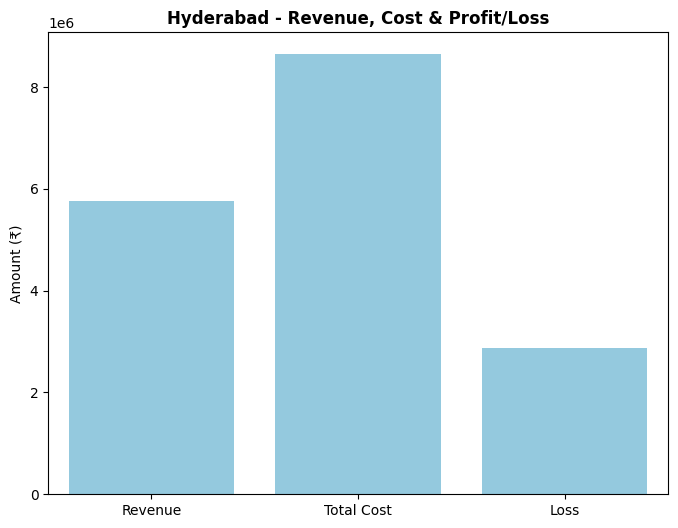

In [148]:
plt.figure(figsize=(8, 6))

# Determine profit/loss label
if profit_loss > 0:
    result_label = 'Profit'
    result_value = profit_loss

elif profit_loss < 0:
    result_label = 'Loss'
    result_value = abs(profit_loss)

else:
    result_label = 'Break-even'
    result_value = 0

values = pd.DataFrame({
    'Metric': ['Revenue', 'Total Cost', result_label],
    'Amount': [total_revenue, total_cost, result_value]
})

sns.barplot(
    data=values,
    x='Metric',
    y='Amount',
    color='skyblue'
)

plt.title('Hyderabad - Revenue, Cost & Profit/Loss', fontweight='bold')
plt.xlabel('')
plt.ylabel('Amount (₹)')

plt.show()

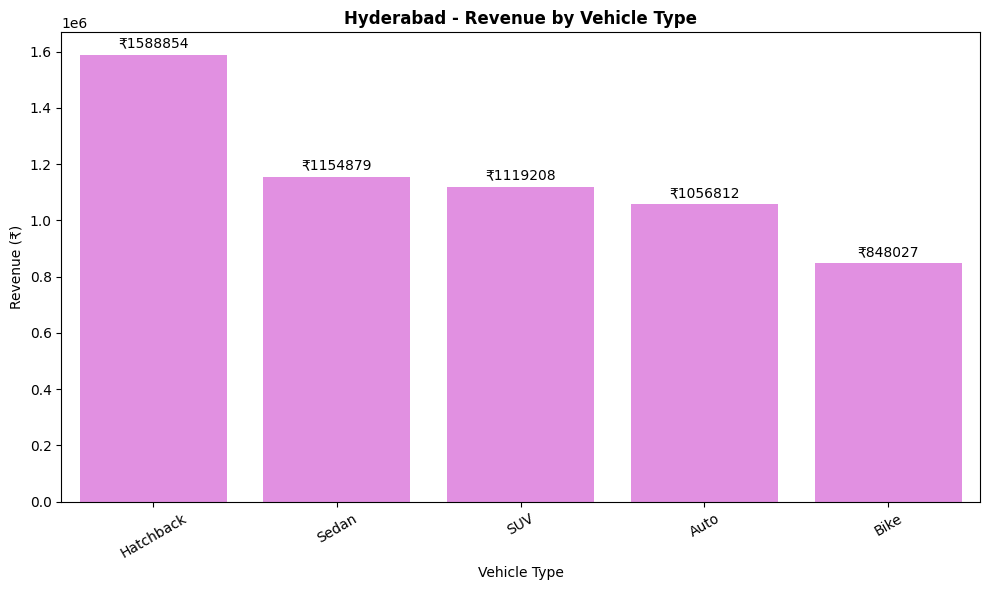

In [149]:
vehicle_revenue = (
    hyderabad.groupby('Type_of_vehicle')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_revenue,
    x='Type_of_vehicle',
    y='Revenue',
    color='Violet'
)

plt.title('Hyderabad - Revenue by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

# Add revenue values on top of bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()


C:\Users\papus\AppData\Local\Temp\ipykernel_448\2322419671.py:18: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:Brown'` for the same effect.

  ax = sns.barplot(


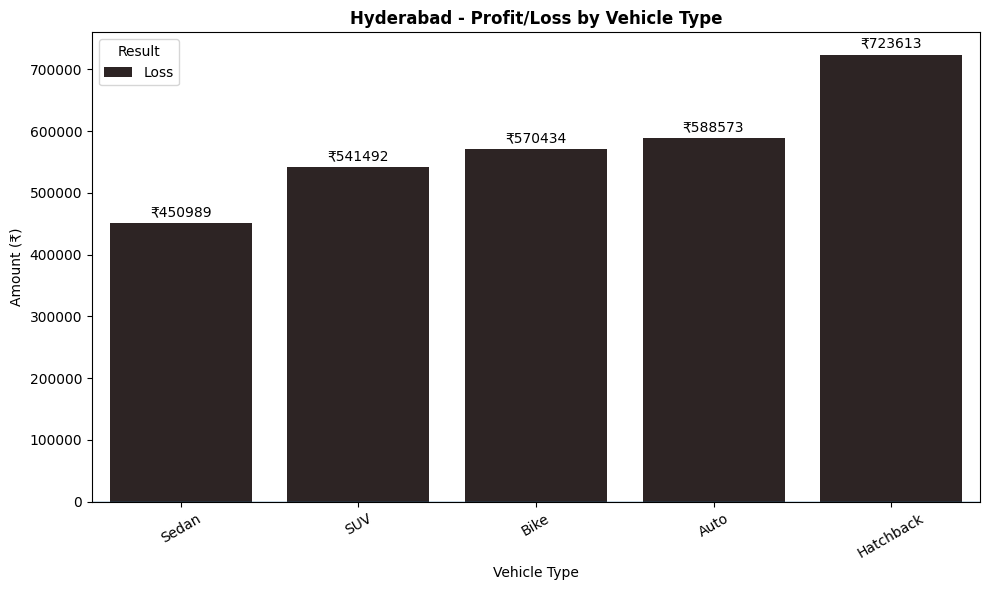

In [150]:
vehicle_profit = (
    hyderabad.groupby('Type_of_vehicle')['Profit_Loss']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

# Create a readable Profit/Loss label
vehicle_profit['Result'] = vehicle_profit['Profit_Loss'].apply(
    lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Break-even')
)

# Display absolute value for Loss
vehicle_profit['Amount'] = vehicle_profit['Profit_Loss'].abs()

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=vehicle_profit,
    x='Type_of_vehicle',
    y='Amount',
    hue='Result',
    dodge=False,
    color='Brown'
)

plt.axhline(0, linewidth=1)

plt.title('Hyderabad - Profit/Loss by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Amount (₹)')
plt.xticks(rotation=30)

# Add values above bars
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='₹%.0f',
        padding=3
    )

plt.tight_layout()
plt.show()

## India Statistics

In [151]:
india = df.copy()

print("India records:", len(india))
india.head()

India records: 1000


,User_ID,Driver_Name,City,Ride_Date,Hour_of_Day,Day_of_Week,Distance_km,Traffic_Level,Type_of_vehicle,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Final_Fare,latitude,longitude
0,USER-21819-Bcbf,Patrick Sanchez,Pune,2025-11-05,0,Friday,26.21,Low,Hatchback,36,67,1.86,60,354.52,1.3,460.88,18.5204,73.8567
1,USER-79402-SBvr,Meredith Barnes,Mumbai,2025-10-13,2,Friday,21.08,High,Auto,9,17,1.89,50,282.96,1.3,367.85,19.0760,72.8777
2,USER-40781-yfJs,Ian Cooper,Bengaluru,2026-06-16,6,Sunday,25.34,High,Hatchback,94,149,1.59,75,344.08,1.3,447.30,12.9716,77.5946
3,USER-41316-rDOx,Amber Perez,Mumbai,2025-10-15,0,Monday,26.80,High,Auto,25,188,7.52,76,351.60,1.6,562.56,19.0760,72.8777
4,USER-76483-RuXX,Kimberly Sanchez,Chennai,2025-09-06,10,Friday,4.48,High,SUV,53,34,0.64,18,133.76,1.0,133.76,13.0827,80.2707


In [152]:
india_summary = {
    'Total Records': len(india),
    'Total Ride Requests': india['Ride_Requests'].sum(),
    'Average Distance (km)': india['Distance_km'].mean(),
    'Average Trip Duration (min)': india['Trip_Duration'].mean(),
    'Average Active Drivers': india['No_of_active_drivers'].mean(),
    'Average Demand/Supply Ratio': india['Demand_Supply_Ratio'].mean(),
    'Average Surge Multiplier': india['Surge_Multiplier'].mean(),
    'Average Base Fare': india['Base_Fare'].mean(),
    'Average Final Fare': india['Final_Fare'].mean()
}

for key, value in india_summary.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

Total Records: 1000
Total Ride Requests: 108047
Average Distance (km): 17.91
Average Trip Duration (min): 55.16
Average Active Drivers: 52.52
Average Demand/Supply Ratio: 2.90
Average Surge Multiplier: 1.44
Average Base Fare: 257.48
Average Final Fare: 370.21


In [153]:
# Calculate India revenue

india['Revenue'] = india['Final_Fare']

total_revenue = india['Revenue'].sum()

print("India Total Revenue: ₹", round(total_revenue, 2))

India Total Revenue: ₹ 370212.83


In [154]:
# See India by vehicle type

india_vehicle = (
    india.groupby('Type_of_vehicle')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Distance=('Distance_km', 'mean'),
        Avg_Trip_Duration=('Trip_Duration', 'mean'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Final_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

india_vehicle

,Ride_Requests,Avg_Distance,Avg_Trip_Duration,Avg_Surge,Avg_Final_Fare
Type_of_vehicle,,,,,
Bike,22742,17.615915,53.859155,1.440845,328.164413
SUV,22682,17.879458,55.738916,1.449754,431.205530
Auto,22428,17.630291,54.393204,1.450000,348.552864
Hatchback,21295,18.139036,55.482234,1.415736,362.620914
Sedan,18900,18.365304,56.591160,1.422099,384.203757


In [155]:
# India by hour
india_hourly = (
    india.groupby('Hour_of_Day')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Active_Drivers=('No_of_active_drivers', 'mean'),
        Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Surge=('Surge_Multiplier', 'mean'),
        Final_Fare=('Final_Fare', 'mean')
    )
    .reset_index()
)

india_hourly

,Hour_of_Day,Ride_Requests,Active_Drivers,Demand_Supply,Surge,Final_Fare
0,0,4153,51.153846,2.822821,1.438462,372.082308
1,1,5145,52.531915,3.158511,1.453191,346.823404
2,2,4514,51.760870,2.701087,1.382609,332.468913
3,3,4499,51.761905,2.855476,1.423810,342.221190
4,4,4445,58.850000,2.549750,1.407500,323.903750
5,5,4021,50.027778,3.057222,1.500000,422.685833
6,6,4265,53.270270,2.979459,1.427027,390.152973
7,7,3429,45.500000,3.263437,1.490625,367.489688
8,8,4524,57.521739,2.439565,1.380435,293.933478
9,9,5317,52.955556,2.969111,1.486667,379.690000


In [156]:
# Peak demand hour

india_hourly.loc[
    india_hourly['Ride_Requests'].idxmax()
]

Hour_of_Day         22.000000
Ride_Requests     6077.000000
Active_Drivers      49.038462
Demand_Supply        3.506731
Surge                1.473077
Final_Fare         379.981154
Name: 22, dtype: float64

In [157]:
# Highest surge hour

india_hourly.loc[
    india_hourly['Surge'].idxmax()
]

Hour_of_Day         21.000000
Ride_Requests     4969.000000
Active_Drivers      49.461538
Demand_Supply        3.175128
Surge                1.602564
Final_Fare         492.113846
Name: 21, dtype: float64

In [158]:
# Highest demand/supply hour

india_hourly.loc[
    india_hourly['Demand_Supply'].idxmax()
]

Hour_of_Day         22.000000
Ride_Requests     6077.000000
Active_Drivers      49.038462
Demand_Supply        3.506731
Surge                1.473077
Final_Fare         379.981154
Name: 22, dtype: float64

In [159]:
# Traffic analysis

india_traffic = (
    india.groupby('Traffic_Level')
    .agg(
        Ride_Requests=('Ride_Requests', 'sum'),
        Avg_Surge=('Surge_Multiplier', 'mean'),
        Avg_Demand_Supply=('Demand_Supply_Ratio', 'mean'),
        Avg_Fare=('Final_Fare', 'mean')
    )
    .sort_values('Ride_Requests', ascending=False)
)

india_traffic

,Ride_Requests,Avg_Surge,Avg_Demand_Supply,Avg_Fare
Traffic_Level,,,,
Jam,29259,1.451481,2.984593,368.602333
High,27883,1.451200,2.993320,381.053485
Low,26201,1.425100,2.822231,374.781793
Medium,24704,1.413974,2.799782,355.269001


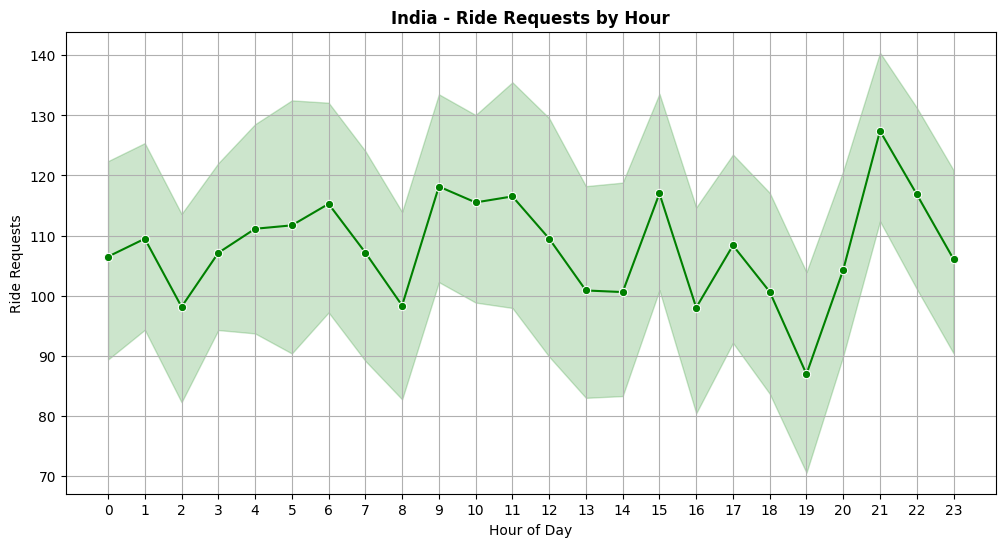

In [160]:
# Ride Requests by Hour

plt.figure(figsize=(12, 6))

sns.lineplot(
    data=india,
    x='Hour_of_Day',
    y='Ride_Requests',
    marker='o',
    color='Green'
)

plt.title('India - Ride Requests by Hour', fontweight='bold')
plt.xlabel('Hour of Day')
plt.ylabel('Ride Requests')
plt.xticks(range(24))
plt.grid(True)
plt.show()


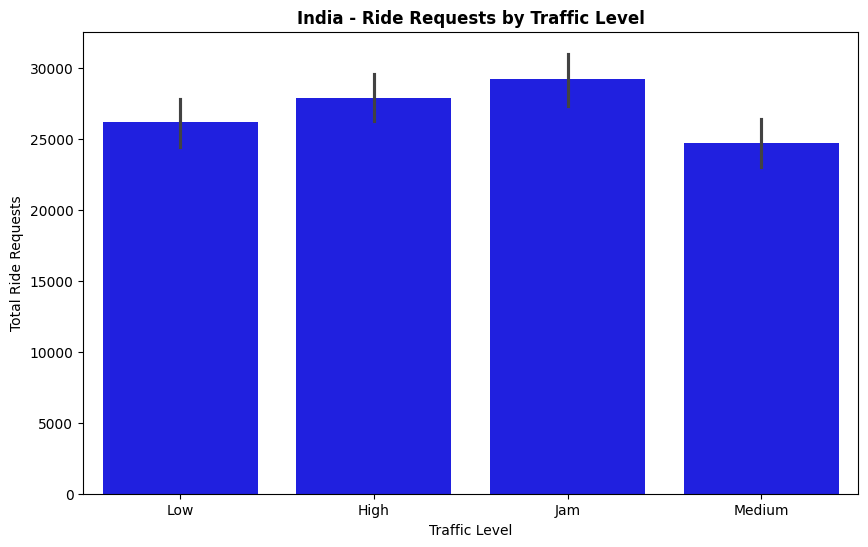

In [161]:
# Traffic Level vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=india,
    x='Traffic_Level',
    y='Ride_Requests',
    estimator='sum',
    color='blue'
)

plt.title('India - Ride Requests by Traffic Level', fontweight='bold')
plt.xlabel('Traffic Level')
plt.ylabel('Total Ride Requests')
plt.show()

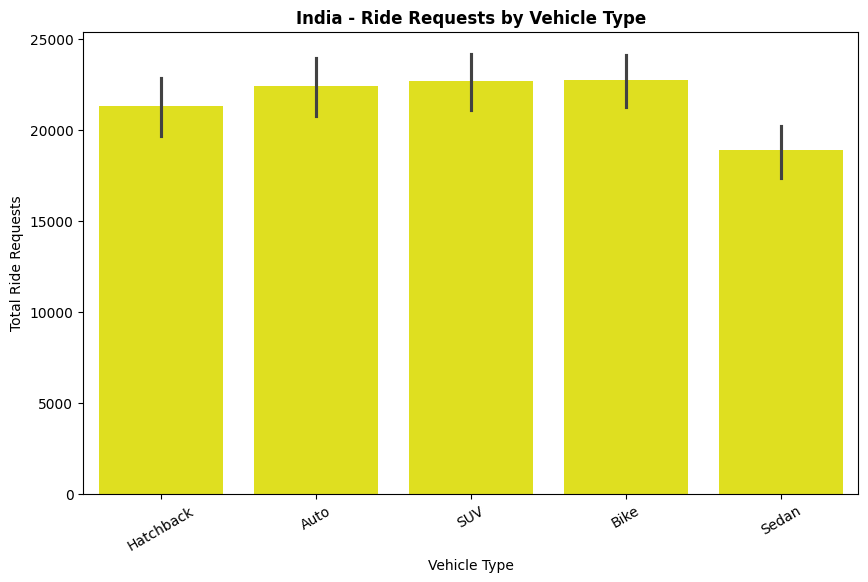

In [162]:
# Vehicle Type vs Ride Requests

plt.figure(figsize=(10, 6))

sns.barplot(
    data=india,
    x='Type_of_vehicle',
    y='Ride_Requests',
    estimator='sum',
    color='yellow'
)

plt.title('India - Ride Requests by Vehicle Type', fontweight='bold')
plt.xlabel('Vehicle Type')
plt.ylabel('Total Ride Requests')
plt.xticks(rotation=30)
plt.show()


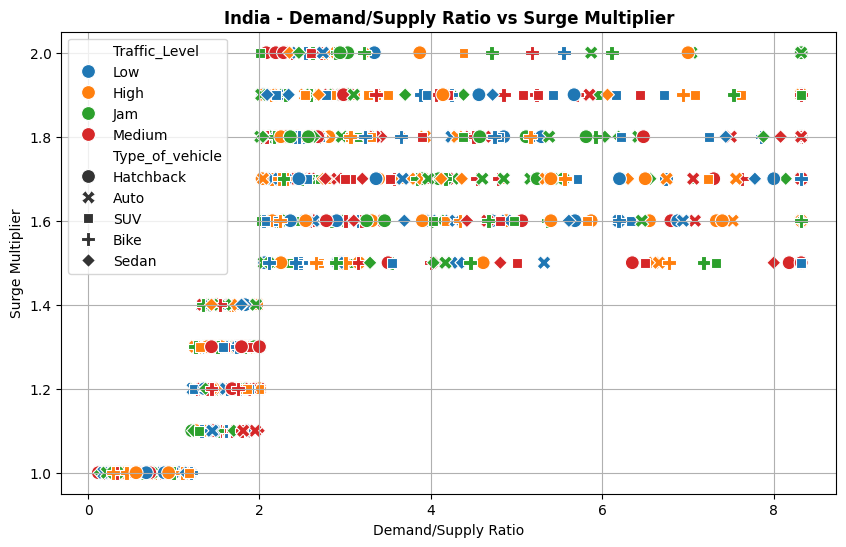

In [163]:
# Demand/Supply vs Surge Multiplier

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=india,
    x='Demand_Supply_Ratio',
    y='Surge_Multiplier',
    hue='Traffic_Level',
    style='Type_of_vehicle',
    s=100
)

plt.title('India - Demand/Supply Ratio vs Surge Multiplier', fontweight='bold')
plt.xlabel('Demand/Supply Ratio')
plt.ylabel('Surge Multiplier')
plt.grid(True)
plt.show()


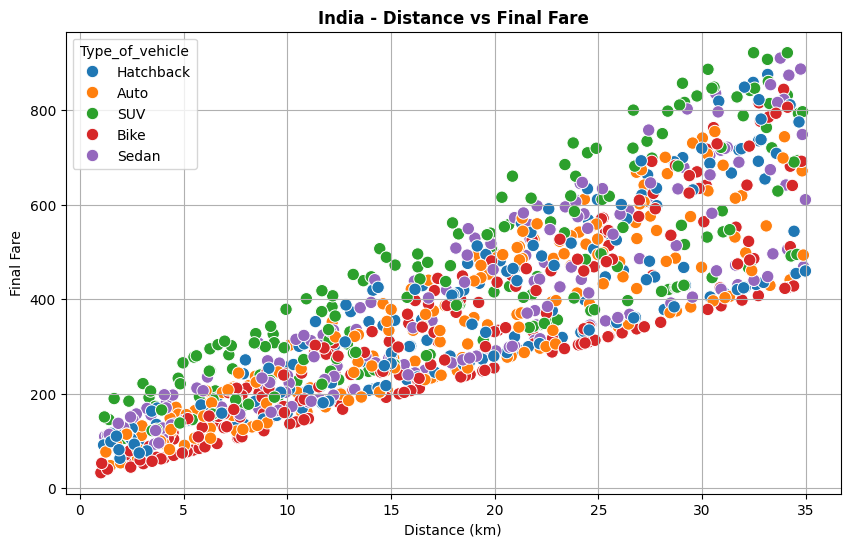

In [164]:
# Distance vs Final Fare

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=india,
    x='Distance_km',
    y='Final_Fare',
    hue='Type_of_vehicle',
    s=80
)

plt.title('India - Distance vs Final Fare', fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('Final Fare')
plt.grid(True)
plt.show()


In [165]:
# India data
india = df.copy()

# COST ASSUMPTIONS
fuel_cost_per_km = 8          # ₹ per km
driver_cost_percentage = 0.60 # 60% of revenue
fixed_cost_per_ride = 150     # ₹ per ride

# REVENUE
india['Revenue'] = (
    india['Final_Fare'] *
    india['Ride_Requests']
)

# COSTS
india['Fuel_Cost'] = (
    india['Distance_km'] *
    india['Ride_Requests'] *
    fuel_cost_per_km
)

india['Driver_Cost'] = (
    india['Revenue'] *
    driver_cost_percentage
)

india['Fixed_Cost'] = (
    india['Ride_Requests'] *
    fixed_cost_per_ride
)

india['Total_Cost'] = (
    india['Fuel_Cost'] +
    india['Driver_Cost'] +
    india['Fixed_Cost']
)

# PROFIT / LOSS
india['Profit_Loss'] = (
    india['Revenue'] -
    india['Total_Cost']
)


# TOTALS
total_revenue = delhi['Revenue'].sum()
total_cost = delhi['Total_Cost'].sum()
profit_loss = total_revenue - total_cost

print(f"India Revenue    : ₹{total_revenue:,.2f}")
print(f"India Total Cost : ₹{total_cost:,.2f}")

# PROFIT / LOSS RESULT
if profit_loss > 0:
    print(f"India Profit     : ₹{profit_loss:,.2f}")
    print("Result           : PROFIT")

elif profit_loss < 0:
    loss = abs(profit_loss)
    print(f"India Loss       : ₹{loss:,.2f}")
    print("Result           : LOSS")

else:
    print("India Profit/Loss : ₹0.00")
    print("Result            : BREAK-EVEN")

India Revenue    : ₹8,332,314.16
India Total Cost : ₹8,175,244.41
India Profit     : ₹157,069.74
Result           : PROFIT


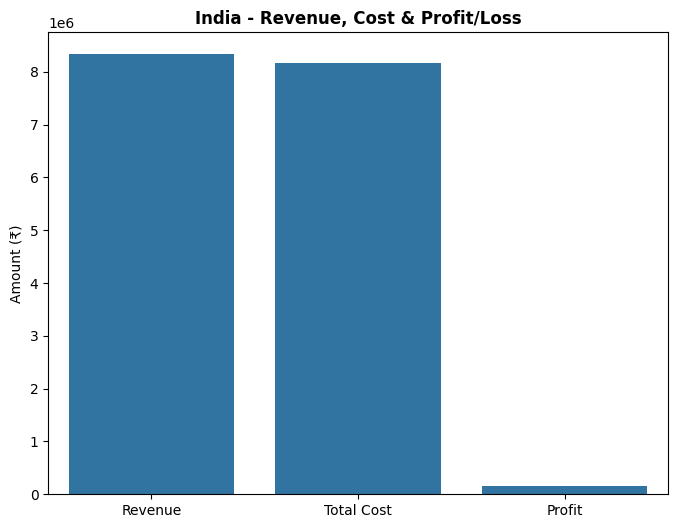

In [166]:
plt.figure(figsize=(8, 6))

# Determine profit/loss label
if profit_loss > 0:
    result_label = 'Profit'
    result_value = profit_loss

elif profit_loss < 0:
    result_label = 'Loss'
    result_value = abs(profit_loss)

else:
    result_label = 'Break-even'
    result_value = 0

values = pd.DataFrame({
    'Metric': ['Revenue', 'Total Cost', result_label],
    'Amount': [total_revenue, total_cost, result_value]
})

sns.barplot(
    data=values,
    x='Metric',
    y='Amount'
)

plt.title('India - Revenue, Cost & Profit/Loss', fontweight='bold')
plt.xlabel('')
plt.ylabel('Amount (₹)')

plt.show()


## Predictive Modeling

In [167]:
# Predictive Modeling

features = ['Hour_of_Day', 'Distance_km', 'No_of_active_drivers', 'Ride_Requests',
            'Demand_Supply_Ratio', 'Trip_Duration', 'Base_Fare', 'Surge_Multiplier']

features = [col for col in features if col in df.columns]

if 'Final_Fare' not in df.columns:
    raise ValueError('Target Column Final_Fare not found in the dataset.')

model = df[features + ['Final_Fare']].dropna()

# split the dataset

X = model[features]
y = model['Final_Fare']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

# Evaluate the model performance using R2 Score as a measure of prediction accuracy
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print('Linear Regression Model Performance:')
print(f'R2 Score: {r2: 4f}')
print(f'Mean Squared Error: {mse:4f}')

Linear Regression Model Performance:
R2 Score:  0.957436
Mean Squared Error: 1597.156036


In [168]:
results = {
    "Linear Regression": {"MAE": mse, "R2": r2}
}

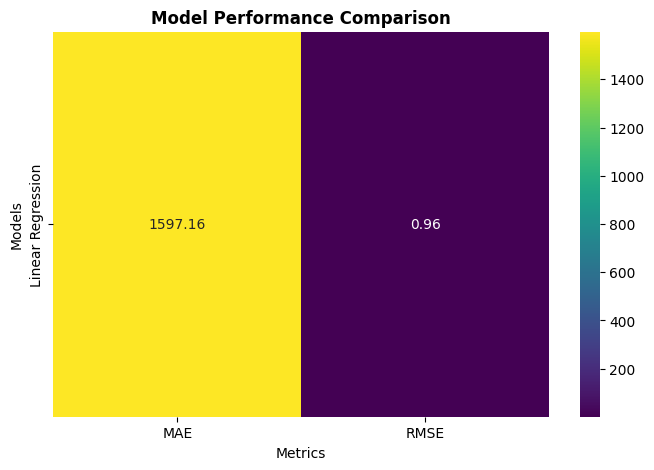

In [169]:
results_df = pd.DataFrame({
    "MAE": mse,
    "RMSE": r2
}, index=["Linear Regression"])

plt.figure(figsize=(8,5))

sns.heatmap(
    results_df,
    annot=True,
    fmt=".2f",
    cmap="viridis"
)

plt.title("Model Performance Comparison", fontweight='bold')
plt.ylabel("Models")
plt.xlabel("Metrics")
plt.show()


In [170]:
# Predict Final Fare for a New Ride

new_ride = pd.DataFrame({
    'Hour_of_Day': [18],
    'Distance_km': [12],
    'No_of_active_drivers': [80],
    'Ride_Requests': [150],
    'Demand_Supply_Ratio': [1.875],
    'Trip_Duration': [35],
    'Base_Fare': [250],
    'Surge_Multiplier': [1.5]
})

In [172]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [173]:
predicted_fare = model.predict(new_ride)

print(f"Predicted Final Fare: ₹{predicted_fare[0]:.2f}")

Predicted Final Fare: ₹381.13


The trained Linear Regression model predicted a final ride fare of ₹381.13 for a sample ride using distance, trip duration, base fare, surge multiplier, ride requests, active drivers, demand/supply ratio, and hour of day as input features.

In [174]:
# Predict Final Fare for Multiple Rides

multiple_rides = pd.DataFrame({
    'Hour_of_Day': [8, 13, 18, 22],
    'Distance_km': [5, 10, 12, 20],
    'No_of_active_drivers': [100, 120, 80, 60],
    'Ride_Requests': [180, 100, 150, 200],
    'Demand_Supply_Ratio': [1.80, 0.83, 1.875, 3.33],
    'Trip_Duration': [20, 30, 35, 50],
    'Base_Fare': [120, 220, 250, 400],
    'Surge_Multiplier': [1.2, 1.0, 1.5, 2.0]
})

multiple_rides['Predicted_Final_Fare'] = model.predict(multiple_rides)

multiple_rides

,Hour_of_Day,Distance_km,No_of_active_drivers,Ride_Requests,Demand_Supply_Ratio,Trip_Duration,Base_Fare,Surge_Multiplier,Predicted_Final_Fare
0,8,5,100,180,1.800,20,120,1.2,114.219839
1,13,10,120,100,0.830,30,220,1.0,203.220581
2,18,12,80,150,1.875,35,250,1.5,381.132125
3,22,20,60,200,3.330,50,400,2.0,730.561516


### Whole-Country Fare Prediction Summary

The Linear Regression model was used to predict the final fare for multiple hypothetical rides across India. The predicted fares ranged from ₹114.22 to ₹730.56.

The highest predicted fare was ₹730.56 for a 20 km ride with a base fare of ₹400 and a surge multiplier of 2.0. This indicates that distance, base fare, and surge pricing are important factors influencing final ride fares.

## Predict high-demand zones.

In [175]:
# Create demand level based on Ride Requests

high_demand_threshold = df['Ride_Requests'].quantile(0.75)

df['Demand_Level'] = np.where(
    df['Ride_Requests'] >= high_demand_threshold,
    'High Demand',
    'Normal Demand'
)

print(f"High-demand threshold: {high_demand_threshold:.2f}")

df[['City', 'Hour_of_Day', 'Ride_Requests', 'Demand_Level']].head()

High-demand threshold: 156.00


,City,Hour_of_Day,Ride_Requests,Demand_Level
0,Pune,0,67,Normal Demand
1,Mumbai,2,17,Normal Demand
2,Bengaluru,6,149,Normal Demand
3,Mumbai,0,188,High Demand
4,Chennai,10,34,Normal Demand


In [176]:
# City-hour demand analysis

demand_zones = (
    df.groupby(['City', 'Hour_of_Day'])
    .agg(
        Total_Ride_Requests=('Ride_Requests', 'sum'),
        Average_Ride_Requests=('Ride_Requests', 'mean'),
        Average_Active_Drivers=('No_of_active_drivers', 'mean'),
        Average_Demand_Supply_Ratio=('Demand_Supply_Ratio', 'mean'),
        Ride_Count=('User_ID', 'count')
    )
    .reset_index()
)

demand_zones = demand_zones.sort_values(
    'Total_Ride_Requests',
    ascending=False
)

demand_zones.head(10)

,City,Hour_of_Day,Total_Ride_Requests,Average_Ride_Requests,Average_Active_Drivers,Average_Demand_Supply_Ratio,Ride_Count
18,Bengaluru,18,1579,112.785714,44.928571,3.742143,14
139,Pune,20,1579,105.266667,41.266667,4.040000,15
45,Chennai,21,1415,141.500000,52.200000,3.145000,10
1,Bengaluru,1,1340,134.000000,40.600000,4.480000,10
123,Pune,4,1308,118.909091,58.272727,2.448182,11
65,Delhi,17,1301,144.555556,57.777778,2.640000,9
103,Mumbai,7,1299,118.090909,39.636364,4.591818,11
39,Chennai,15,1299,129.900000,60.100000,2.971000,10
28,Chennai,4,1286,142.888889,59.111111,3.313333,9
96,Mumbai,0,1277,141.888889,42.888889,4.316667,9


In [177]:
# Select the top 10 high-demand city-hour zones

top_demand_zones = demand_zones.head(10)

top_demand_zones

,City,Hour_of_Day,Total_Ride_Requests,Average_Ride_Requests,Average_Active_Drivers,Average_Demand_Supply_Ratio,Ride_Count
18,Bengaluru,18,1579,112.785714,44.928571,3.742143,14
139,Pune,20,1579,105.266667,41.266667,4.040000,15
45,Chennai,21,1415,141.500000,52.200000,3.145000,10
1,Bengaluru,1,1340,134.000000,40.600000,4.480000,10
123,Pune,4,1308,118.909091,58.272727,2.448182,11
65,Delhi,17,1301,144.555556,57.777778,2.640000,9
103,Mumbai,7,1299,118.090909,39.636364,4.591818,11
39,Chennai,15,1299,129.900000,60.100000,2.971000,10
28,Chennai,4,1286,142.888889,59.111111,3.313333,9
96,Mumbai,0,1277,141.888889,42.888889,4.316667,9


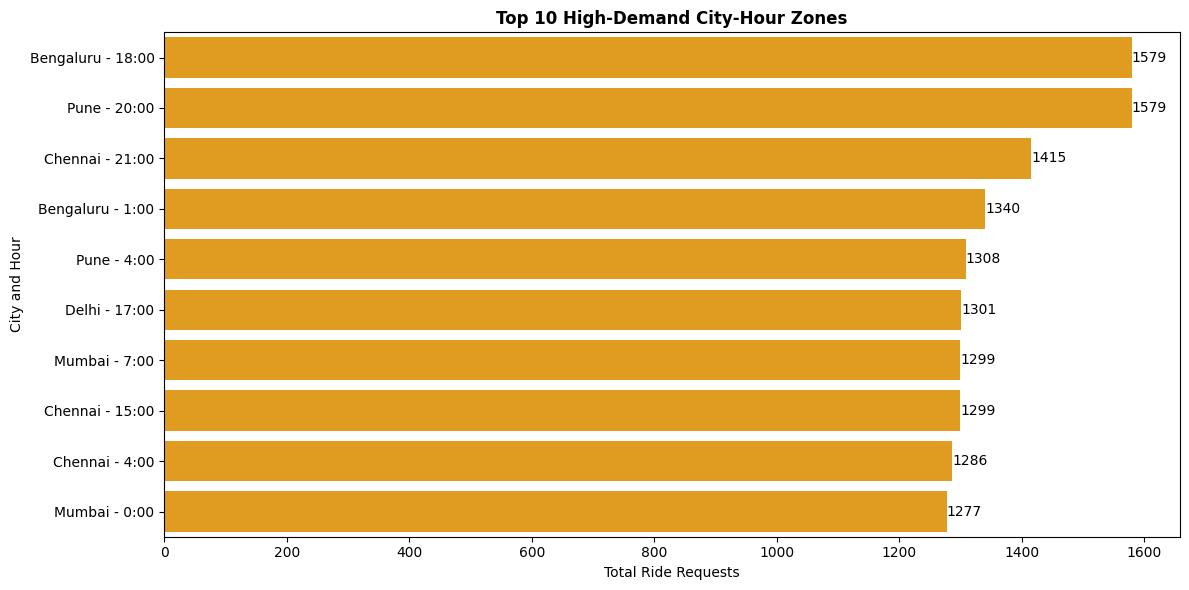

In [178]:
plt.figure(figsize=(12, 6))

zone_labels = (
    top_demand_zones['City']
    + ' - '
    + top_demand_zones['Hour_of_Day'].astype(str)
    + ':00'
)

ax = sns.barplot(
    x=top_demand_zones['Total_Ride_Requests'],
    y=zone_labels,
    color='orange'
)

plt.title('Top 10 High-Demand City-Hour Zones', fontweight='bold')
plt.xlabel('Total Ride Requests')
plt.ylabel('City and Hour')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()

In [179]:
# Features for demand prediction

demand_features = [
    'Hour_of_Day',
    'Distance_km',
    'No_of_active_drivers',
    'Ride_Requests',
    'Demand_Supply_Ratio',
    'Trip_Duration',
    'Base_Fare',
    'Surge_Multiplier'
]

demand_features = [
    col for col in demand_features
    if col in df.columns
]

demand_model_data = df[
    demand_features + ['Demand_Level']
].dropna()

X_demand = demand_model_data[demand_features]
y_demand = demand_model_data['Demand_Level']

In [180]:
# Train demand prediction model

X_train_demand, X_test_demand, y_train_demand, y_test_demand = train_test_split(
    X_demand,
    y_demand,
    test_size=0.2,
    random_state=42,
    stratify=y_demand
)

demand_model = LogisticRegression(max_iter=1000)

demand_model.fit(
    X_train_demand,
    y_train_demand
)

y_pred_demand = demand_model.predict(X_test_demand)

demand_accuracy = accuracy_score(
    y_test_demand,
    y_pred_demand
)

print(f"Demand Prediction Accuracy: {demand_accuracy:.4f}")

Demand Prediction Accuracy: 1.0000


In [181]:
top_demand_zones

,City,Hour_of_Day,Total_Ride_Requests,Average_Ride_Requests,Average_Active_Drivers,Average_Demand_Supply_Ratio,Ride_Count
18,Bengaluru,18,1579,112.785714,44.928571,3.742143,14
139,Pune,20,1579,105.266667,41.266667,4.040000,15
45,Chennai,21,1415,141.500000,52.200000,3.145000,10
1,Bengaluru,1,1340,134.000000,40.600000,4.480000,10
123,Pune,4,1308,118.909091,58.272727,2.448182,11
65,Delhi,17,1301,144.555556,57.777778,2.640000,9
103,Mumbai,7,1299,118.090909,39.636364,4.591818,11
39,Chennai,15,1299,129.900000,60.100000,2.971000,10
28,Chennai,4,1286,142.888889,59.111111,3.313333,9
96,Mumbai,0,1277,141.888889,42.888889,4.316667,9


### High-Demand Zone Analysis

The analysis identified high-demand zones by grouping rides according to City and Hour_of_Day. The combination of city and hour was used as a zone because the dataset does not contain individual geographic zone information.

Bengaluru at 18:00 and Pune at 20:00 recorded the highest total ride requests, with 1,579 requests each. Mumbai at 07:00 had the highest average demand/supply ratio among the top-ranked zones, at approximately 4.59.

The results suggest that driver allocation should be increased in Bengaluru, Pune, Chennai, Delhi, and Mumbai during their high-demand time periods.

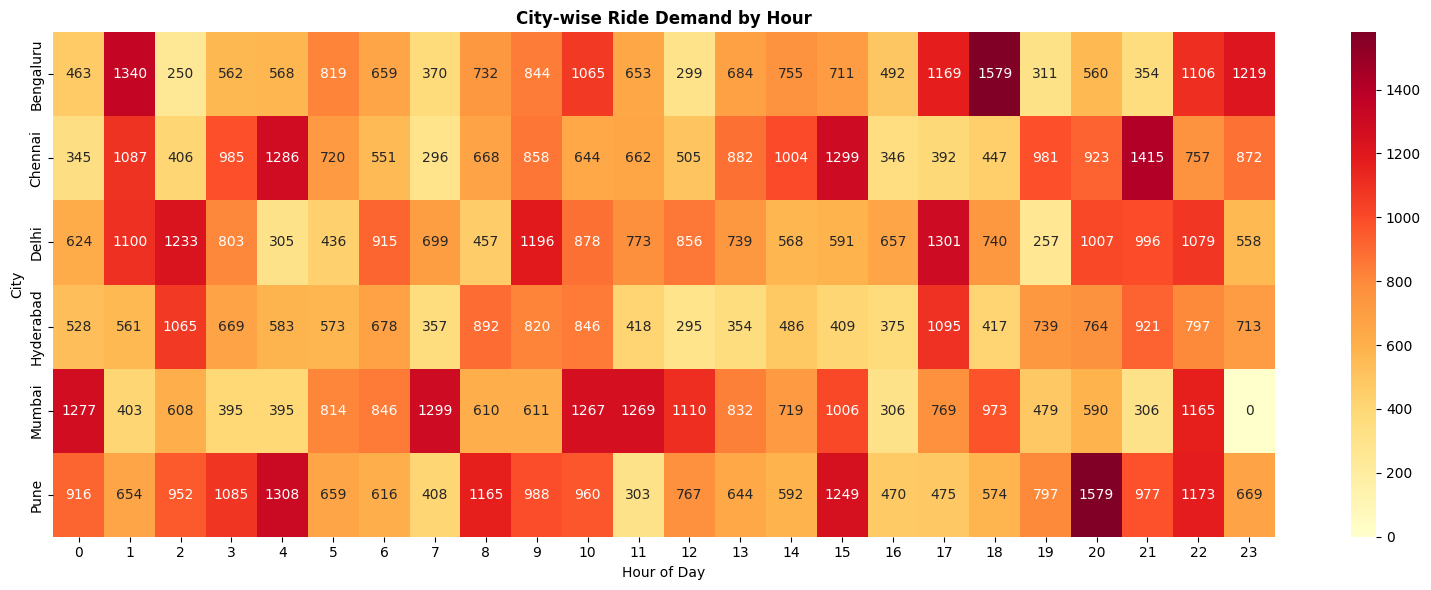

In [182]:
# City-wise demand by hour

city_hour_demand = df.pivot_table(
    index='City',
    columns='Hour_of_Day',
    values='Ride_Requests',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(16, 6))

sns.heatmap(
    city_hour_demand,
    annot=True,
    fmt='.0f',
    cmap='YlOrRd'
)

plt.title(
    'City-wise Ride Demand by Hour',
    fontweight='bold'
)

plt.xlabel('Hour of Day')
plt.ylabel('City')

plt.tight_layout()
plt.show()

## High-Demand Zone Analysis — Summary

The city-hour demand analysis identified the combinations of cities and hours with the highest ride requests.

Key findings:

- Bengaluru at 18:00 and Pune at 20:00 recorded the highest total ride requests.
- Chennai appeared multiple times among the top-demand city-hour combinations.
- Mumbai showed a high average Demand/Supply Ratio during selected hours.
- Several high-demand periods occurred during evening and late-night hours.
- These city-hour combinations can be considered priority areas for driver allocation and demand planning.

Since the dataset does not contain a specific geographical zone column, city and hour were used as a proxy for identifying high-demand zones.